
# INTELLIGENT ENERGY CONSUMPTION FORECASTING FOR SMART CITIES

## Introduction

India is one of the fastest-growing energy markets in the world. Understanding its electricity generation capacity across states and fuel types is critical to analyze the country's transition from fossil fuels to renewables.

Our code explores monthly electricity capacity data for India, broken down by:
1. Fuel type (Coal, Gas, Hydro, Solar, Wind, Renewables, etc.)
2. State/Union territory
3. Monthly timeline (2019–2024)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

plt.style.use('default')
sns.set_theme(style="whitegrid", palette="husl", font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.family'] = 'sans-serif'

COLORS = {
    'fossil': '#8B4513',
    'renewable': '#228B22', 
    'solar': '#FFD700',
    'wind': '#87CEEB',
    'hydro': '#4682B4',
    'coal': '#696969'
}

# Section 1: Data Loading & Preprocessing

**Data Loading:**

**Date Processing:**
1. Convert date strings to proper datetime format
2. Extract time-based features (Year, Month, Quarter)
3. Validate temporal coverage and consistency

**Numeric Validation:**
1. Clean the 'Value' column for capacity measurements
2. Handle missing values and invalid entries
3. Ensure YoY change columns are properly formatted

**Energy Type Classification:**
1. Categorize fuel types into Fossil, Renewable, and Other
2. Create standardized groupings for analysis
3. Validate classification completeness

In [2]:
df = pd.read_csv('india_monthly_electricity_(2019-2024).csv')

print(f"Dataset Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\n Column Names:")
for i, col in enumerate(df.columns, 1):
    print(f"{i:2d}. {col}")

df.head()

Dataset Shape: 207,114 rows × 13 columns

 Column Names:
 1. Country
 2. Country code
 3. State
 4. State code
 5. State type
 6. Date
 7. Category
 8. Subcategory
 9. Variable
10. Unit
11. Value
12. YoY absolute change
13. YoY % change


,Country,Country code,State,State code,State type,Date,Category,Subcategory,Variable,Unit,Value,YoY absolute change,YoY % change
0,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,Clean,MW,NaN,NaN,NaN
1,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,Fossil,MW,NaN,NaN,NaN
2,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,Gas and Other Fossil,MW,NaN,NaN,NaN
3,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,"Hydro, Bioenergy and Other Renewables",MW,NaN,NaN,NaN
4,India,IND,Andaman and Nicobar,AN,Union territory,2019-01-01,Capacity,Aggregate fuel,Renewables,MW,NaN,NaN,NaN


In [3]:
print("Dataset Information:")
print("-" * 40)
print(f"Date column type: {df['Date'].dtype}")
print(f"Sample dates: {df['Date'].head().tolist()}")
print(f"\n Basic Stats:")
print(f" Unique States: {df['State'].nunique()}")
print(f" Unique Fuel Types: {df['Variable'].nunique()}")
print(f" Missing Values: {df.isnull().sum().sum()}")

Dataset Information:
----------------------------------------
Date column type: object
Sample dates: ['2019-01-01', '2019-01-01', '2019-01-01', '2019-01-01', '2019-01-01']

 Basic Stats:
 Unique States: 38
 Unique Fuel Types: 18
 Missing Values: 251050


In [4]:
print("Missing Values by Column:")
missing_summary = df.isnull().sum()
for col, missing in missing_summary.items():
    if missing > 0:
        pct = (missing / len(df)) * 100
        print(f"   {col}: {missing:,} ({pct:.1f}%)")
    else:
        print(f"   {col}: No missing values")

Missing Values by Column:
   Country: No missing values
   Country code: No missing values
   State: No missing values
   State code: No missing values
   State type: No missing values
   Date: No missing values
   Category: No missing values
   Subcategory: No missing values
   Variable: No missing values
   Unit: No missing values
   Value: 3,010 (1.5%)
   YoY absolute change: 103,708 (50.1%)
   YoY % change: 144,332 (69.7%)


In [5]:
print(" Converting Date column...")
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

invalid_dates = df['Date'].isnull().sum()
if invalid_dates > 0:
    print(f" Found {invalid_dates} invalid dates")
    print("Sample invalid entries:")
    print(df[df['Date'].isnull()]['Date'].head())
    
print(f"Date conversion complete!")
print(f"Date Range: {df['Date'].min()} to {df['Date'].max()}")

 Converting Date column...
Date conversion complete!
Date Range: 2019-01-01 00:00:00 to 2024-12-01 00:00:00


In [6]:
print("Extracting time features...")
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Quarter'] = df['Date'].dt.quarter
df['MonthName'] = df['Date'].dt.strftime('%B')

print(f"Years Covered: {df['Year'].min()} to {df['Year'].max()}")
print(f"Total Years: {df['Year'].nunique()}")

Extracting time features...
Years Covered: 2019 to 2024
Total Years: 6


In [7]:
print("Cleaning numeric columns...")

original_values = df['Value'].copy()
df['Value'] = pd.to_numeric(df['Value'], errors='coerce')
invalid_values = df['Value'].isnull().sum()
df['Value'] = df['Value'].fillna(0)

numeric_cols = ['YoY absolute change', 'YoY % change']
for col in numeric_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        print(f"{col}: Converted to numeric")

print("Numeric conversion complete!")

Cleaning numeric columns...
YoY absolute change: Converted to numeric
YoY % change: Converted to numeric
Numeric conversion complete!


In [8]:
fossil_fuels = ['Coal', 'Gas', 'Oil', 'Other Fossil', 'Fossil', 'Gas and Other Fossil']
renewable_fuels = ['Hydro', 'Solar', 'Wind', 'Bioenergy', 'Other Renewables', 
                  'Renewables', 'Hydro, Bioenergy and Other Renewables']

def classify_energy_type(fuel_name):
    if fuel_name in fossil_fuels:
        return 'Fossil'
    elif fuel_name in renewable_fuels:
        return 'Renewable'
    else:
        return 'Other'

df['EnergyType'] = df['Variable'].apply(classify_energy_type)
energy_dist = df['EnergyType'].value_counts()
print(" Energy Type Classification:")
for energy_type, count in energy_dist.items():
    pct = (count / len(df)) * 100
    print(f"   {energy_type}: {count:,} records ({pct:.1f}%)")

 Energy Type Classification:
   Renewable: 93,730 records (45.3%)
   Fossil: 65,475 records (31.6%)
   Other: 47,909 records (23.1%)


In [9]:
print("Capacity Statistics by Energy Type:")
print("-" * 50)
capacity_stats = df.groupby('EnergyType')['Value'].agg([
    'count', 'sum', 'mean', 'std', 'min', 'max'
]).round(0)

for energy_type in capacity_stats.index:
    stats = capacity_stats.loc[energy_type]
    print(f"\n{energy_type.upper()}:")
    print(f"  Records: {stats['count']:>10,.0f}")
    print(f"  Total:   {stats['sum']:>10,.0f} MW")
    print(f"  Average: {stats['mean']:>10,.0f} MW")
    print(f"  Max:     {stats['max']:>10,.0f} MW")

Capacity Statistics by Energy Type:
--------------------------------------------------

FOSSIL:
  Records:     65,475
  Total:   144,032,682 MW
  Average:      2,200 MW
  Max:        244,430 MW

OTHER:
  Records:     47,909
  Total:   76,116,572 MW
  Average:      1,589 MW
  Max:        217,589 MW

RENEWABLE:
  Records:     93,730
  Total:   63,902,000 MW
  Average:        682 MW
  Max:        209,409 MW


In [10]:
print("\nTop 10 States by Total Capacity:")
print("-" * 40)
top_states = df.groupby('State')['Value'].sum().sort_values(ascending=False).head(10)

for i, (state, capacity) in enumerate(top_states.items(), 1):
    print(f"{i:2d}. {state:<25} {capacity:>12,.0f} MW")


Top 10 States by Total Capacity:
----------------------------------------
 1. India Total                141,162,237 MW
 2. Maharashtra                 14,575,359 MW
 3. Gujarat                     13,820,406 MW
 4. Tamil Nadu                  11,813,607 MW
 5. Madhya Pradesh              11,404,164 MW
 6. Uttar Pradesh               11,332,523 MW
 7. Rajasthan                   10,146,987 MW
 8. Karnataka                    9,925,686 MW
 9. Chhattisgarh                 9,784,708 MW
10. Andhra Pradesh               8,909,287 MW


In [11]:
print("\nTop Fuel Types by Total Capacity:")
print("-" * 40)
fuel_dist = df.groupby('Variable')['Value'].sum().sort_values(ascending=False).head(8)
total_capacity = fuel_dist.sum()

for i, (fuel, capacity) in enumerate(fuel_dist.items(), 1):
    pct = (capacity / df['Value'].sum()) * 100
    print(f"{i:2d}. {fuel:<30} {capacity:>10,.0f} MW ({pct:4.1f}%)")


Top Fuel Types by Total Capacity:
----------------------------------------
 1. Fossil                         69,765,989 MW (24.6%)
 2. Coal                           65,265,284 MW (23.0%)
 3. Clean                          28,006,915 MW ( 9.9%)
 4. Renewables                     26,434,552 MW ( 9.3%)
 5. Total Generation               18,590,996 MW ( 6.5%)
 6. Wind and Solar                 15,401,657 MW ( 5.4%)
 7. Total emissions                11,493,479 MW ( 4.0%)
 8. Hydro, Bioenergy and Other Renewables 11,032,895 MW ( 3.9%)


# Section 2: National Trends Analysis

### Key Questions
1. How has India's total electricity capacity evolved over time?
2. What is the pace of the fossil-to-renewable transition?
3. When did major capacity expansions occur?
4. What are the growth rate trends and inflection points?

### Analysis Focus
1. Total capacity growth trends and trajectories
2. Energy mix evolution between fossil and renewable sources
3. Renewable penetration rates and milestone achievements
4. Growth rate patterns and policy-driven inflection points

In [12]:
national_capacity = df.groupby('Date')['Value'].sum().reset_index()
national_capacity = national_capacity.sort_values('Date')

annual_capacity = df.groupby('Year')['Value'].sum().reset_index()

print(f" National Capacity Overview:")
print(f"Peak Capacity: {national_capacity['Value'].max():,.0f} MW")
print(f"Growth Period: {annual_capacity['Year'].min()} to {annual_capacity['Year'].max()}")
print(f"Total Growth: {((annual_capacity['Value'].iloc[-1] / annual_capacity['Value'].iloc[0]) - 1) * 100:.1f}%")

 National Capacity Overview:
Peak Capacity: 4,848,805 MW
Growth Period: 2019 to 2024
Total Growth: 44.1%


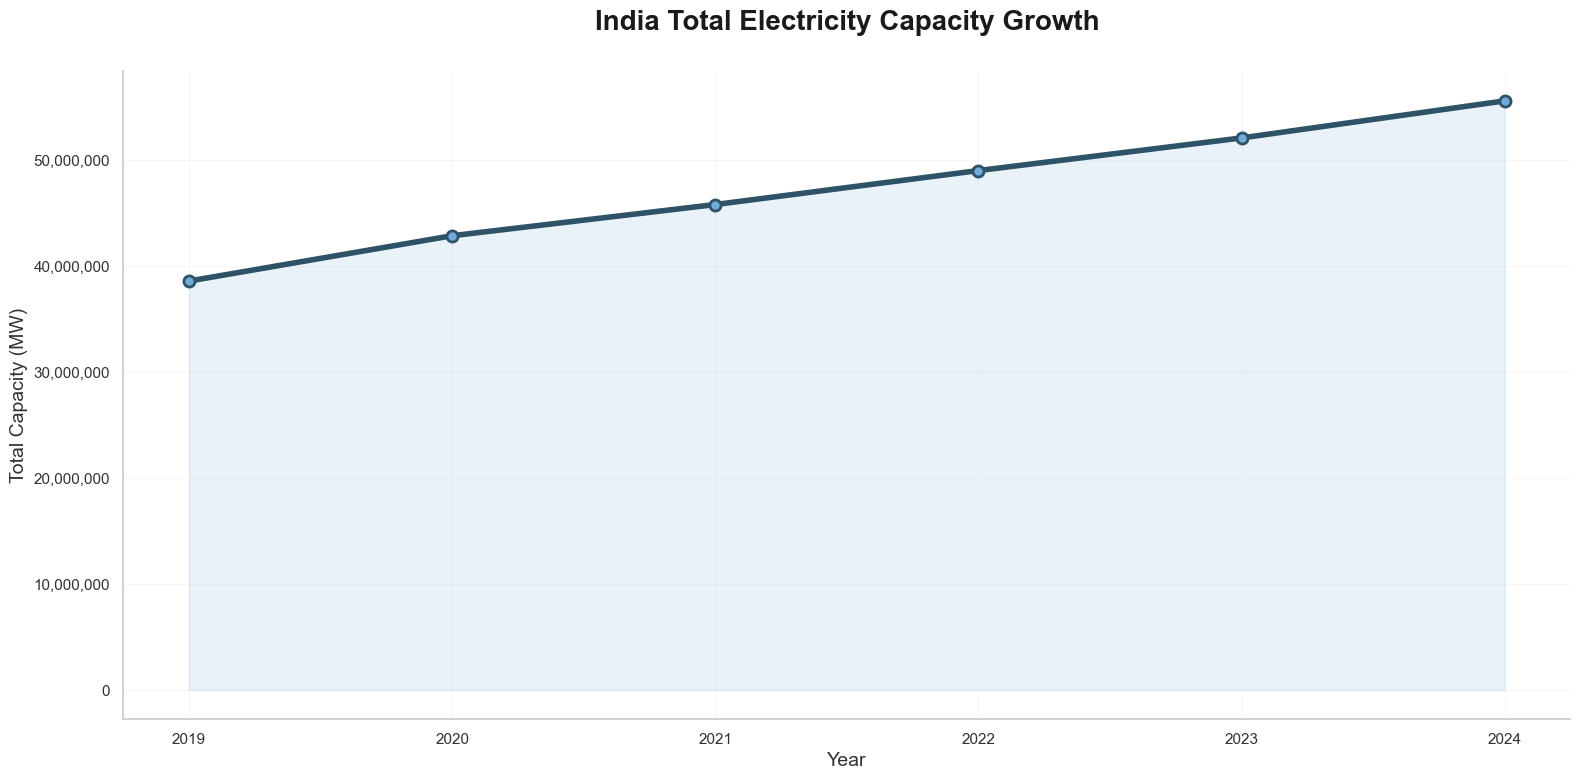

In [13]:
plt.figure(figsize=(16, 8))

plt.plot(annual_capacity['Year'], annual_capacity['Value'], 
         marker='o', linewidth=4, markersize=8, color='#2E5266', 
         markerfacecolor='#6FAADB', markeredgecolor='#2E5266', markeredgewidth=2)

plt.fill_between(annual_capacity['Year'], annual_capacity['Value'], 
                 alpha=0.15, color='#6FAADB')

plt.title('India Total Electricity Capacity Growth', 
          fontsize=20, fontweight='bold', pad=30, color='#1a1a1a')
plt.xlabel('Year', fontsize=14, color='#333333')
plt.ylabel('Total Capacity (MW)', fontsize=14, color='#333333')

plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [14]:
energy_transition = df.groupby(['Year', 'EnergyType'])['Value'].sum().reset_index()
energy_pivot = energy_transition.pivot(index='Year', columns='EnergyType', values='Value').fillna(0)

energy_pivot['Total'] = energy_pivot.sum(axis=1)
energy_pivot['Renewable_Share'] = (energy_pivot['Renewable'] / energy_pivot['Total']) * 100

print("Renewable Share Evolution:")
print(f"Starting share ({energy_pivot.index[0]}): {energy_pivot['Renewable_Share'].iloc[0]:.1f}%")
print(f"Ending share ({energy_pivot.index[-1]}): {energy_pivot['Renewable_Share'].iloc[-1]:.1f}%")
print(f"Share increase: +{energy_pivot['Renewable_Share'].iloc[-1] - energy_pivot['Renewable_Share'].iloc[0]:.1f} percentage points")

Renewable Share Evolution:
Starting share (2019): 20.6%
Ending share (2024): 23.4%
Share increase: +2.8 percentage points


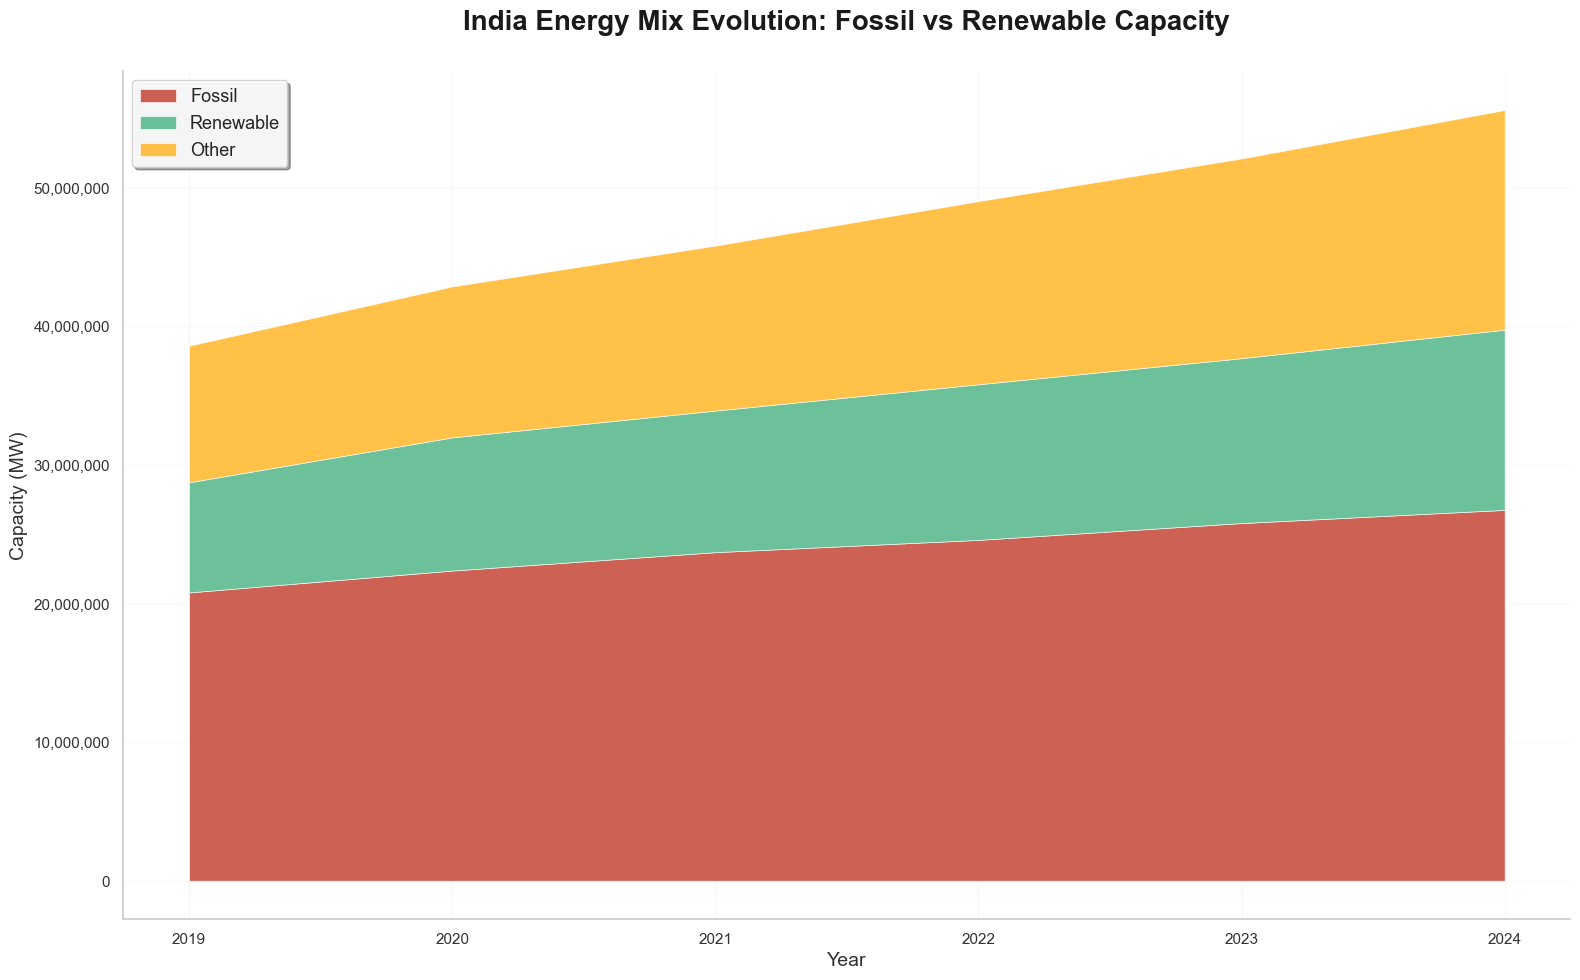

In [15]:
plt.figure(figsize=(16, 10))

years = energy_pivot.index
fossil_values = energy_pivot['Fossil']
renewable_values = energy_pivot['Renewable'] 
other_values = energy_pivot['Other']

plt.fill_between(years, 0, fossil_values, 
                 alpha=0.85, color='#C44536', label='Fossil', edgecolor='white', linewidth=0.5)
plt.fill_between(years, fossil_values, fossil_values + renewable_values,
                 alpha=0.85, color='#52B788', label='Renewable', edgecolor='white', linewidth=0.5) 
plt.fill_between(years, fossil_values + renewable_values, 
                 fossil_values + renewable_values + other_values,
                 alpha=0.85, color='#FFB627', label='Other', edgecolor='white', linewidth=0.5)

plt.title('India Energy Mix Evolution: Fossil vs Renewable Capacity', 
          fontsize=20, fontweight='bold', pad=30, color='#1a1a1a')
plt.xlabel('Year', fontsize=14, color='#333333')
plt.ylabel('Capacity (MW)', fontsize=14, color='#333333')

legend = plt.legend(loc='upper left', fontsize=13, frameon=True, 
                   fancybox=True, shadow=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')

plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

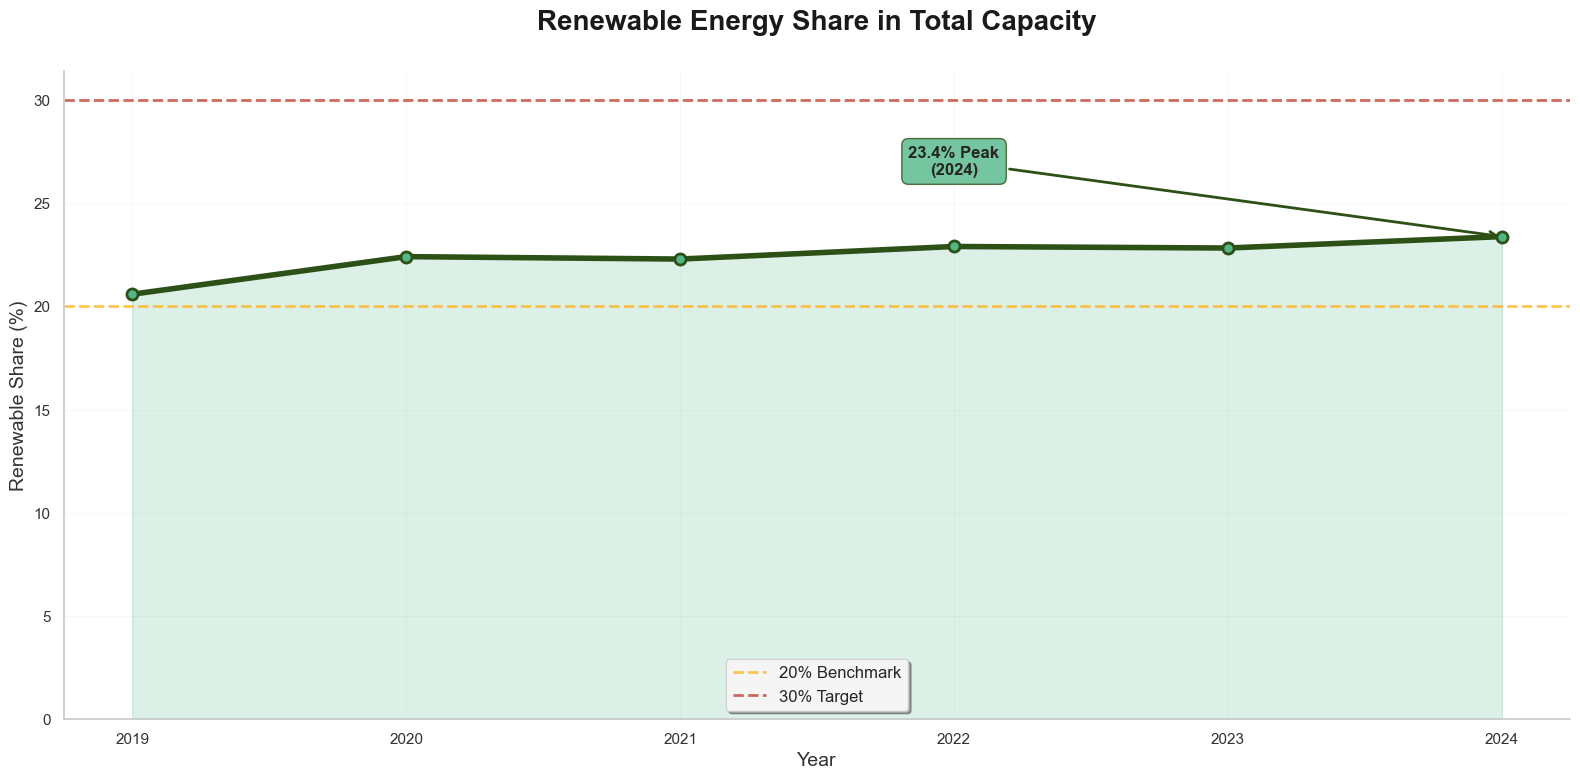

In [16]:
plt.figure(figsize=(16, 8))

plt.plot(energy_pivot.index, energy_pivot['Renewable_Share'], 
         marker='o', linewidth=4, markersize=8, color='#2D5016',
         markerfacecolor='#52B788', markeredgecolor='#2D5016', markeredgewidth=2)

plt.fill_between(energy_pivot.index, energy_pivot['Renewable_Share'], 
                 alpha=0.2, color='#52B788')

plt.title('Renewable Energy Share in Total Capacity', 
          fontsize=20, fontweight='bold', pad=30, color='#1a1a1a')
plt.xlabel('Year', fontsize=14, color='#333333')
plt.ylabel('Renewable Share (%)', fontsize=14, color='#333333')

plt.axhline(y=20, color='#FFB627', linestyle='--', alpha=0.8, linewidth=2, label='20% Benchmark')
plt.axhline(y=30, color='#C44536', linestyle='--', alpha=0.8, linewidth=2, label='30% Target')

legend = plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')

plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')

ax = plt.gca()
ax.tick_params(colors='#333333', labelsize=11)

max_share_year = energy_pivot['Renewable_Share'].idxmax()
max_share_value = energy_pivot['Renewable_Share'].max()
plt.annotate(f'{max_share_value:.1f}% Peak\n({max_share_year})', 
             xy=(max_share_year, max_share_value), 
             xytext=(max_share_year-2, max_share_value+3),
             arrowprops=dict(arrowstyle='->', color='#2D5016', lw=2),
             fontsize=12, ha='center', fontweight='bold',
             bbox=dict(boxstyle="round,pad=0.4", facecolor='#52B788', alpha=0.8, edgecolor='#2D5016'))

plt.ylim(0, max(energy_pivot['Renewable_Share']) + 8)
plt.tight_layout()
plt.show()

In [17]:
annual_capacity['YoY_Growth'] = annual_capacity['Value'].pct_change() * 100
annual_capacity['YoY_Absolute'] = annual_capacity['Value'].diff()

growth_data = annual_capacity.dropna()

print("📈 Growth Rate Statistics:")
print(f"Average annual growth: {growth_data['YoY_Growth'].mean():.1f}%")
print(f"Highest growth year: {growth_data.loc[growth_data['YoY_Growth'].idxmax(), 'Year']} ({growth_data['YoY_Growth'].max():.1f}%)")
print(f"Lowest growth year: {growth_data.loc[growth_data['YoY_Growth'].idxmin(), 'Year']} ({growth_data['YoY_Growth'].min():.1f}%)")

📈 Growth Rate Statistics:
Average annual growth: 7.6%
Highest growth year: 2020 (11.1%)
Lowest growth year: 2023 (6.3%)


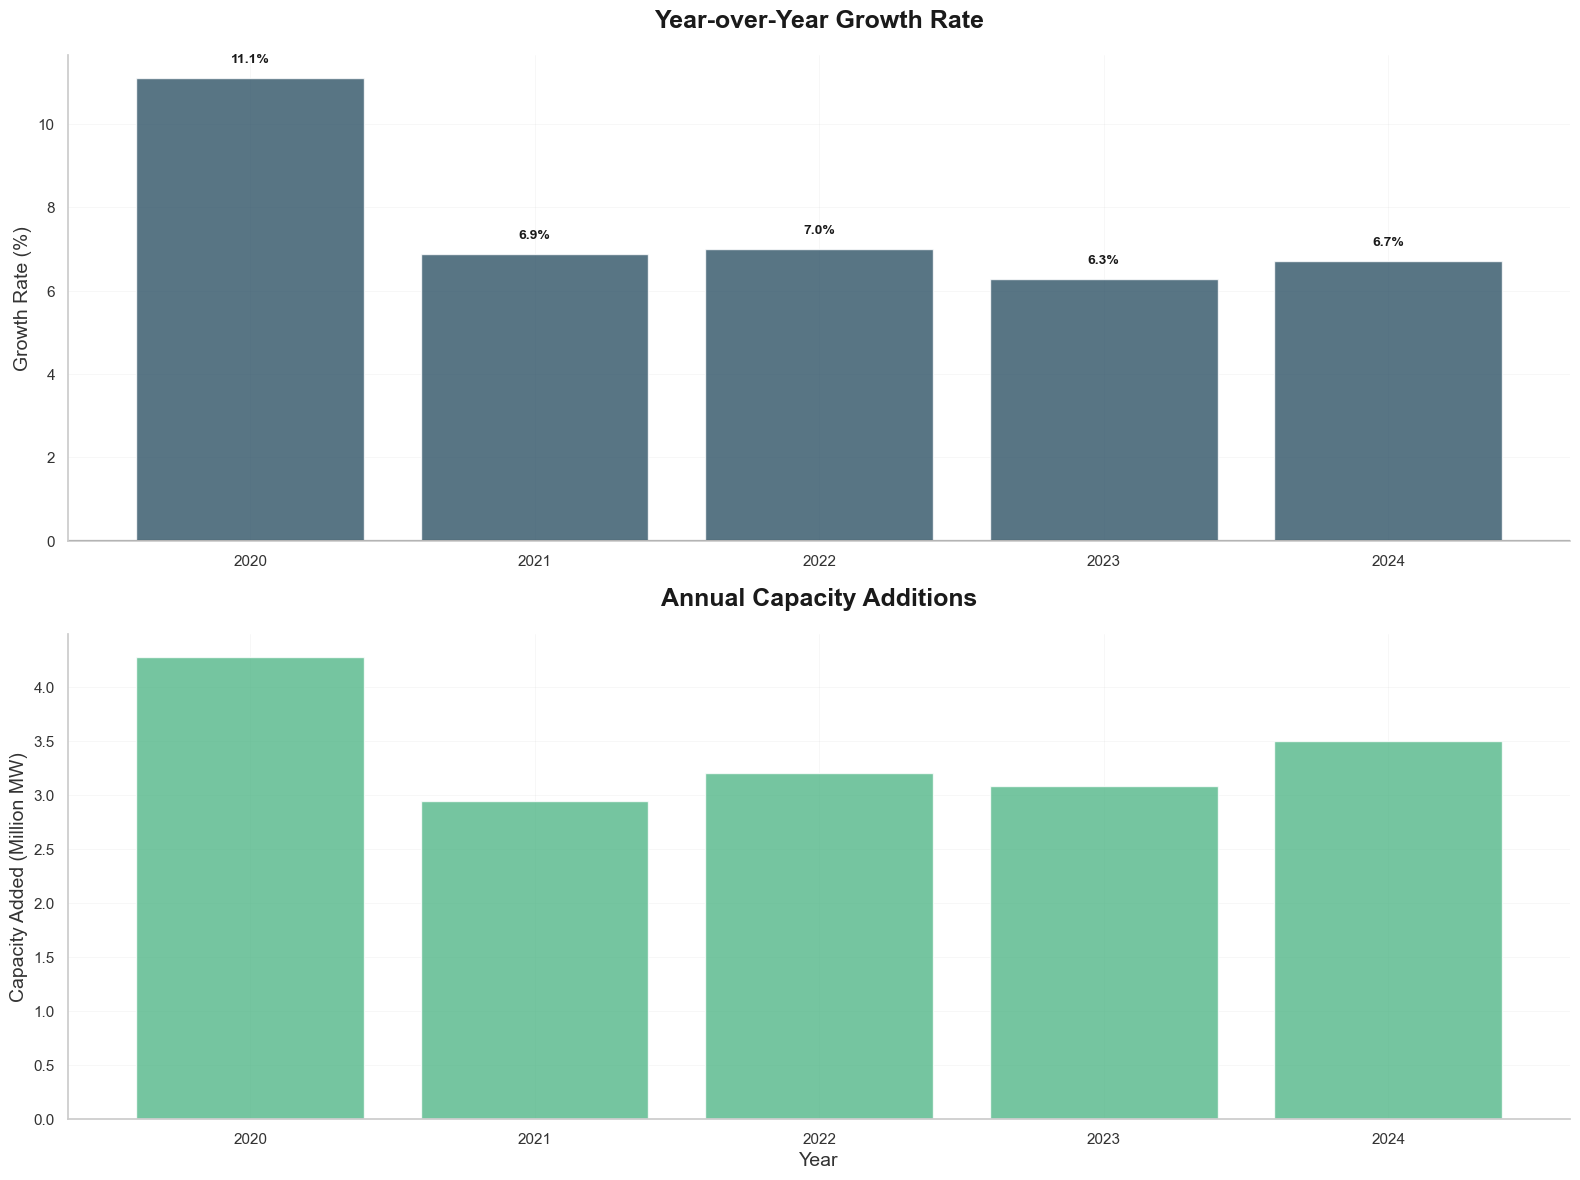

In [18]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

colors1 = ['#C44536' if x < 0 else '#2E5266' for x in growth_data['YoY_Growth']]
bars1 = ax1.bar(growth_data['Year'], growth_data['YoY_Growth'], 
                color=colors1, alpha=0.8, edgecolor='white', linewidth=1)

ax1.set_title('Year-over-Year Growth Rate', fontsize=18, fontweight='bold', pad=20, color='#1a1a1a')
ax1.set_ylabel('Growth Rate (%)', fontsize=14, color='#333333')
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax1.axhline(y=0, color='#1a1a1a', linewidth=1.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')
ax1.tick_params(colors='#333333', labelsize=11)

for bar, value in zip(bars1, growth_data['YoY_Growth']):
    height = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2., height + (0.3 if height > 0 else -0.5),
             f'{value:.1f}%', ha='center', va='bottom' if height > 0 else 'top', 
             fontsize=10, fontweight='bold', color='#1a1a1a')

bars2 = ax2.bar(growth_data['Year'], growth_data['YoY_Absolute']/1000000,
                color='#52B788', alpha=0.8, edgecolor='white', linewidth=1)

ax2.set_title('Annual Capacity Additions', fontsize=18, fontweight='bold', pad=20, color='#1a1a1a')
ax2.set_xlabel('Year', fontsize=14, color='#333333')
ax2.set_ylabel('Capacity Added (Million MW)', fontsize=14, color='#333333')
ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_color('#cccccc')
ax2.spines['bottom'].set_color('#cccccc')
ax2.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

# Section 3: State-Level Analysis

### Key Questions
- Which states dominate India's electricity capacity landscape?
- How does renewable adoption vary across different regions?
- What is the relationship between total capacity and renewable share?
- Which states are experiencing the fastest capacity growth?

### Analysis Focus
- Capacity concentration patterns across states
- Regional renewable leadership and laggards
- Capacity vs renewable share correlation analysis
- State-wise growth trajectories and emerging leaders

In [19]:
state_totals = df.groupby('State')['Value'].sum().sort_values(ascending=False)
state_totals_clean = state_totals[~state_totals.index.str.contains('India Total', na=False)]

print(f"State-Level Overview:")
print(f"Total States/UTs: {len(state_totals_clean)}")
print(f"Capacity Range: {state_totals_clean.min():,.0f} - {state_totals_clean.max():,.0f} MW")
print(f"Top 5 concentration: {(state_totals_clean.head(5).sum() / state_totals_clean.sum() * 100):.1f}%")

State-Level Overview:
Total States/UTs: 37
Capacity Range: 8,284 - 14,575,359 MW
Top 5 concentration: 44.1%


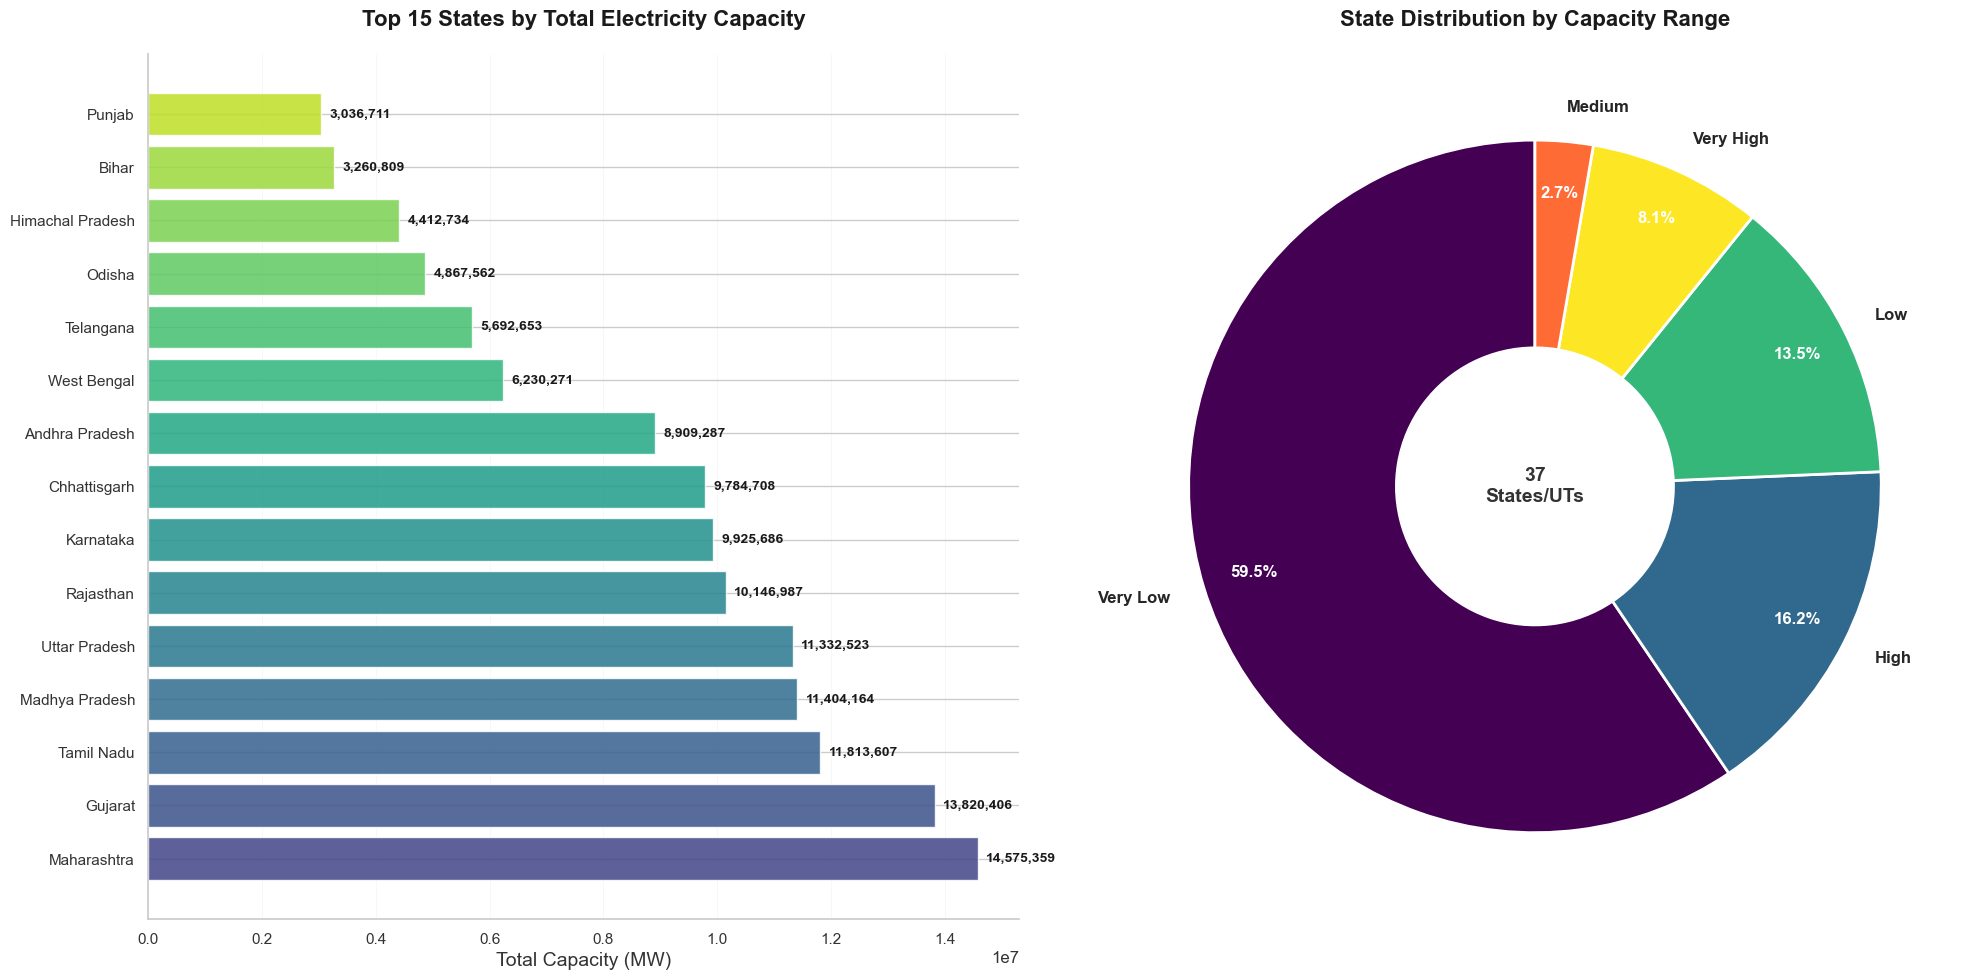

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

top_15_states = state_totals_clean.head(15)
colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(top_15_states)))

bars = ax1.barh(range(len(top_15_states)), top_15_states.values, 
                color=colors, alpha=0.85, edgecolor='white', linewidth=1)

ax1.set_yticks(range(len(top_15_states)))
ax1.set_yticklabels(top_15_states.index, fontsize=11)
ax1.set_xlabel('Total Capacity (MW)', fontsize=14, color='#333333')
ax1.set_title('Top 15 States by Total Electricity Capacity', 
              fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')

for i, (state, value) in enumerate(top_15_states.items()):
    ax1.text(value + max(top_15_states.values) * 0.01, i, f'{value:,.0f}', 
             va='center', fontsize=10, fontweight='bold', color='#1a1a1a')

ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='x')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.spines['left'].set_color('#cccccc')
ax1.spines['bottom'].set_color('#cccccc')
ax1.tick_params(colors='#333333', labelsize=11)

capacity_ranges = pd.cut(state_totals_clean, bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
range_counts = capacity_ranges.value_counts()

colors_pie = ['#440154', '#31688e', '#35b779', '#fde725', '#ff6b35']
wedges, texts, autotexts = ax2.pie(range_counts.values, labels=range_counts.index, 
                                  autopct='%1.1f%%', colors=colors_pie,
                                  startangle=90, pctdistance=0.85,
                                  wedgeprops=dict(width=0.6, edgecolor='white', linewidth=2))

centre_circle = plt.Circle((0,0), 0.40, fc='white')
ax2.add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

ax2.text(0, 0, f'{len(state_totals_clean)}\nStates/UTs', 
        horizontalalignment='center', verticalalignment='center',
        fontsize=14, fontweight='bold', color='#333333')

ax2.set_title('State Distribution by Capacity Range', 
              fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')

plt.tight_layout()
plt.show()

In [21]:
fossil_renewable = df.groupby(['State', 'EnergyType'])['Value'].sum().reset_index()
state_mix = fossil_renewable.pivot(index='State', columns='EnergyType', values='Value').fillna(0)
state_mix['Total'] = state_mix.sum(axis=1)
state_mix['Renewable_Pct'] = (state_mix['Renewable'] / state_mix['Total']) * 100

state_mix_clean = state_mix[~state_mix.index.str.contains('India Total', na=False)]
top_renewable_states = state_mix_clean.sort_values('Renewable_Pct', ascending=False).head(15)

print(f"Renewable Leadership:")
print(f"Highest renewable share: {top_renewable_states['Renewable_Pct'].iloc[0]:.1f}% ({top_renewable_states.index[0]})")
print(f"States with >50% renewables: {sum(state_mix_clean['Renewable_Pct'] > 50)}")
print(f"National average: {state_mix_clean['Renewable_Pct'].mean():.1f}%")

Renewable Leadership:
Highest renewable share: 71.3% (Meghalaya)
States with >50% renewables: 11
National average: 33.8%


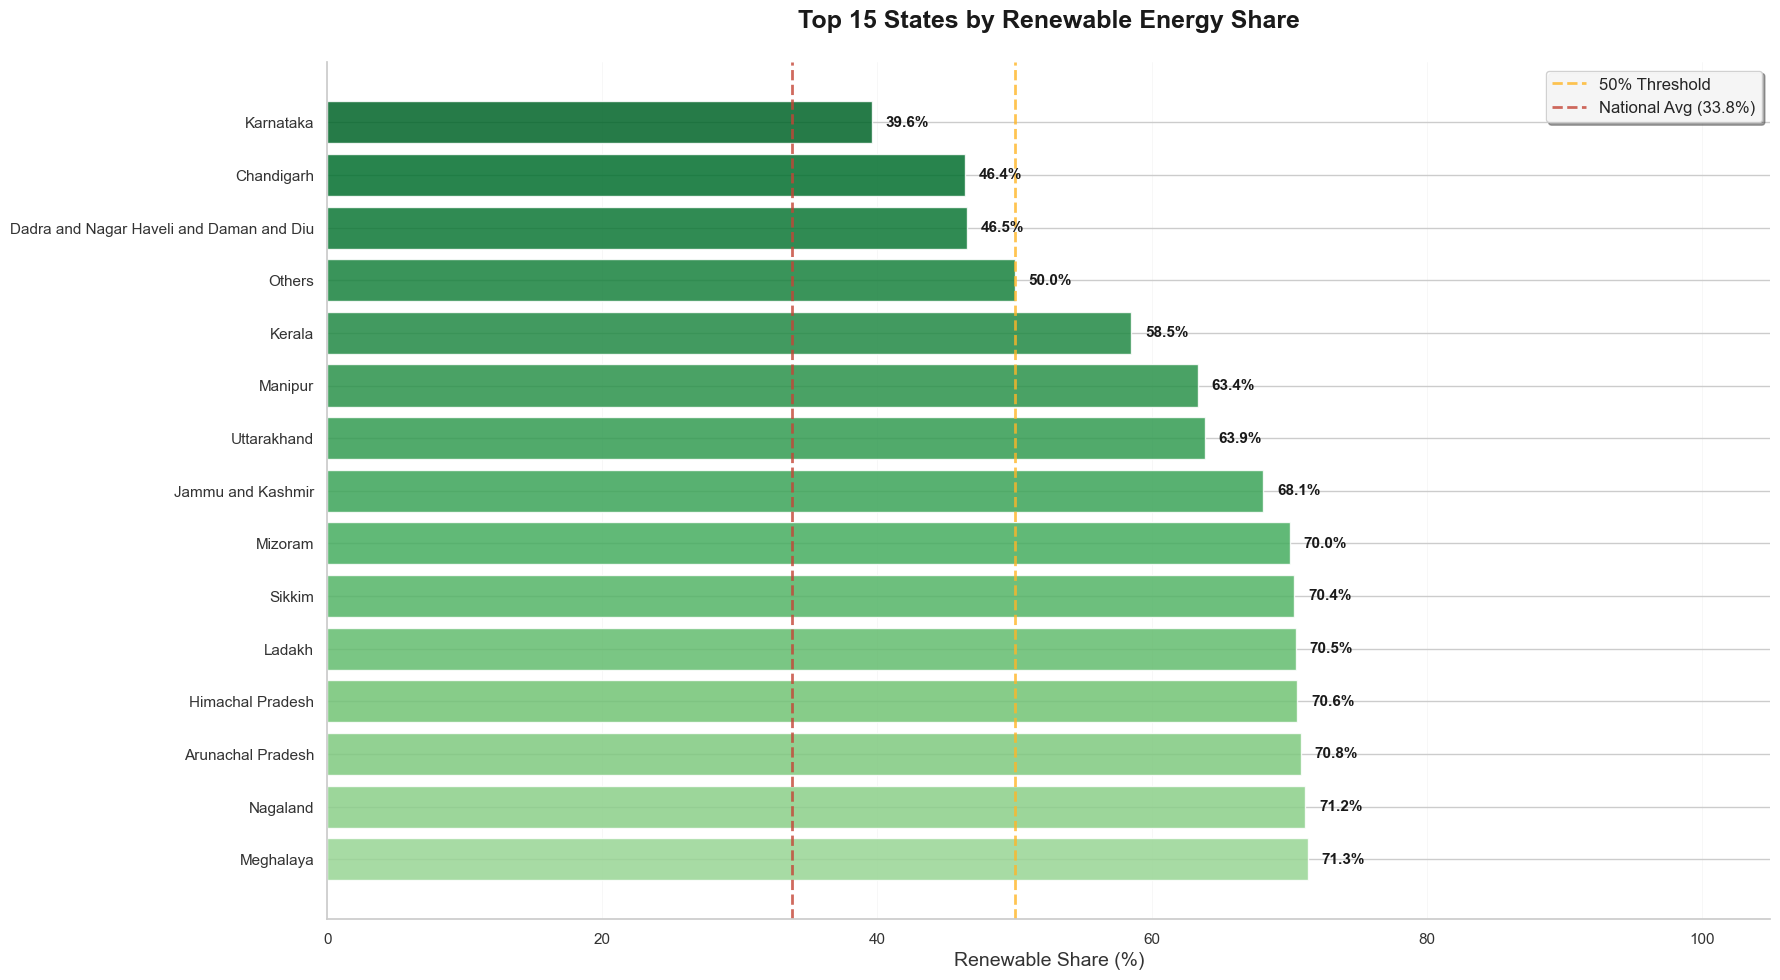

In [22]:
plt.figure(figsize=(18, 10))

bars = plt.barh(range(len(top_renewable_states)), top_renewable_states['Renewable_Pct'], 
                color=plt.cm.Greens(np.linspace(0.4, 0.9, len(top_renewable_states))),
                alpha=0.85, edgecolor='white', linewidth=1)

plt.yticks(range(len(top_renewable_states)), top_renewable_states.index, fontsize=12)
plt.xlabel('Renewable Share (%)', fontsize=14, color='#333333')
plt.title('Top 15 States by Renewable Energy Share', 
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')

for i, (state, pct) in enumerate(top_renewable_states['Renewable_Pct'].items()):
    plt.text(pct + 1, i, f'{pct:.1f}%', 
             va='center', fontsize=11, fontweight='bold', color='#1a1a1a')

plt.axvline(x=50, color='#FFB627', linestyle='--', alpha=0.8, linewidth=2, label='50% Threshold')
plt.axvline(x=state_mix_clean['Renewable_Pct'].mean(), color='#C44536', linestyle='--', 
            alpha=0.8, linewidth=2, label=f'National Avg ({state_mix_clean["Renewable_Pct"].mean():.1f}%)')

legend = plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')

plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='x')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.tick_params(colors='#333333', labelsize=11)
plt.xlim(0, 105)

plt.tight_layout()
plt.show()

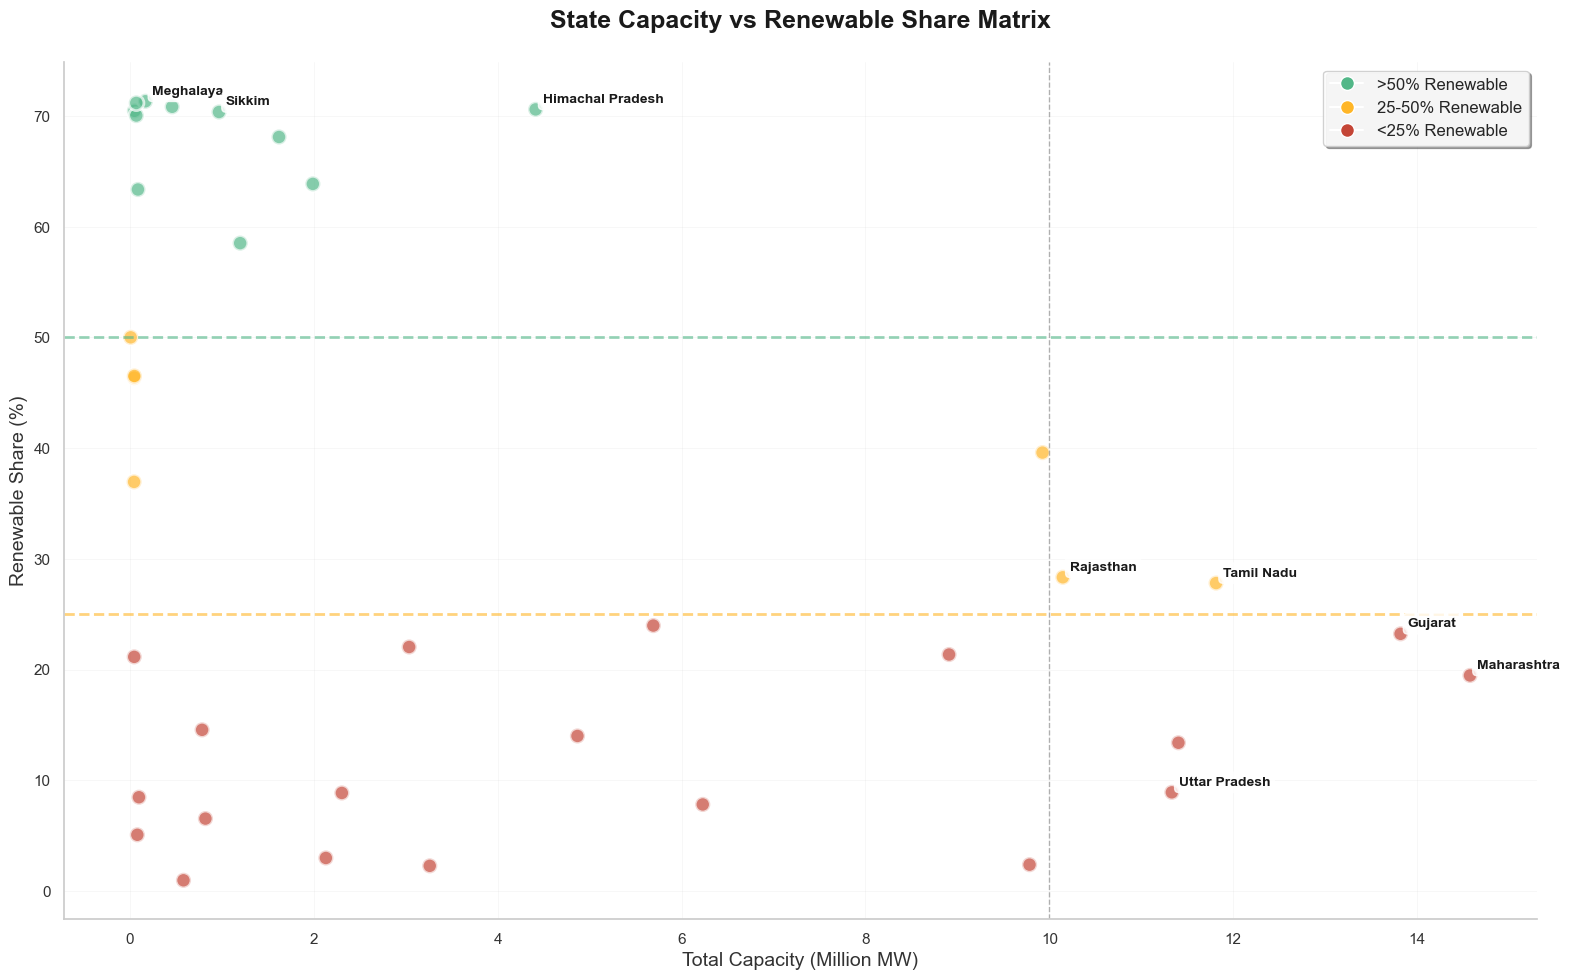

In [23]:
capacity_vs_renewable = state_mix_clean[['Total', 'Renewable_Pct']].copy()
capacity_vs_renewable['State'] = capacity_vs_renewable.index

plt.figure(figsize=(16, 10))

colors = np.where(capacity_vs_renewable['Renewable_Pct'] > 50, '#52B788', 
                 np.where(capacity_vs_renewable['Renewable_Pct'] > 25, '#FFB627', '#C44536'))

scatter = plt.scatter(capacity_vs_renewable['Total']/1000000, capacity_vs_renewable['Renewable_Pct'],
                     s=120, c=colors, alpha=0.7, edgecolors='white', linewidth=2)

plt.xlabel('Total Capacity (Million MW)', fontsize=14, color='#333333')
plt.ylabel('Renewable Share (%)', fontsize=14, color='#333333')
plt.title('State Capacity vs Renewable Share Matrix', 
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')

plt.axhline(y=25, color='#FFB627', linestyle='--', alpha=0.6, linewidth=2)
plt.axhline(y=50, color='#52B788', linestyle='--', alpha=0.6, linewidth=2)
plt.axvline(x=10, color='gray', linestyle='--', alpha=0.6, linewidth=1)

top_states_to_label = ['Maharashtra', 'Gujarat', 'Tamil Nadu', 'Uttar Pradesh', 'Rajasthan', 
                      'Himachal Pradesh', 'Sikkim', 'Meghalaya']

for idx, row in capacity_vs_renewable.iterrows():
    if idx in top_states_to_label:
        plt.annotate(idx, (row['Total']/1000000, row['Renewable_Pct']),
                    xytext=(5, 5), textcoords='offset points', fontsize=10, 
                    fontweight='bold', color='#1a1a1a',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

legend_elements = [plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#52B788', markersize=10, label='>50% Renewable'),
                  plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#FFB627', markersize=10, label='25-50% Renewable'),
                  plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='#C44536', markersize=10, label='<25% Renewable')]

legend = plt.legend(handles=legend_elements, fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')

plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [24]:
state_yearly = df.groupby(['State', 'Year'])['Value'].sum().reset_index()
state_yearly_clean = state_yearly[~state_yearly['State'].str.contains('India Total', na=False)]

growth_states = []
for state in state_yearly_clean['State'].unique()[:10]:
    state_data = state_yearly_clean[state_yearly_clean['State'] == state].sort_values('Year')
    if len(state_data) > 5:
        state_data['YoY_Growth'] = state_data['Value'].pct_change() * 100
        avg_growth = state_data['YoY_Growth'].mean()
        growth_states.append({'State': state, 'Avg_Growth': avg_growth})

growth_df = pd.DataFrame(growth_states).sort_values('Avg_Growth', ascending=False).head(10)

print(f"Fastest Growing States (Average Annual Growth):")
for _, row in growth_df.head(5).iterrows():
    print(f"{row['State']}: {row['Avg_Growth']:.1f}% per year")

Fastest Growing States (Average Annual Growth):
Goa: 33.8% per year
Arunachal Pradesh: 19.8% per year
Bihar: 11.7% per year
Andaman and Nicobar: 8.2% per year
Chhattisgarh: 7.2% per year


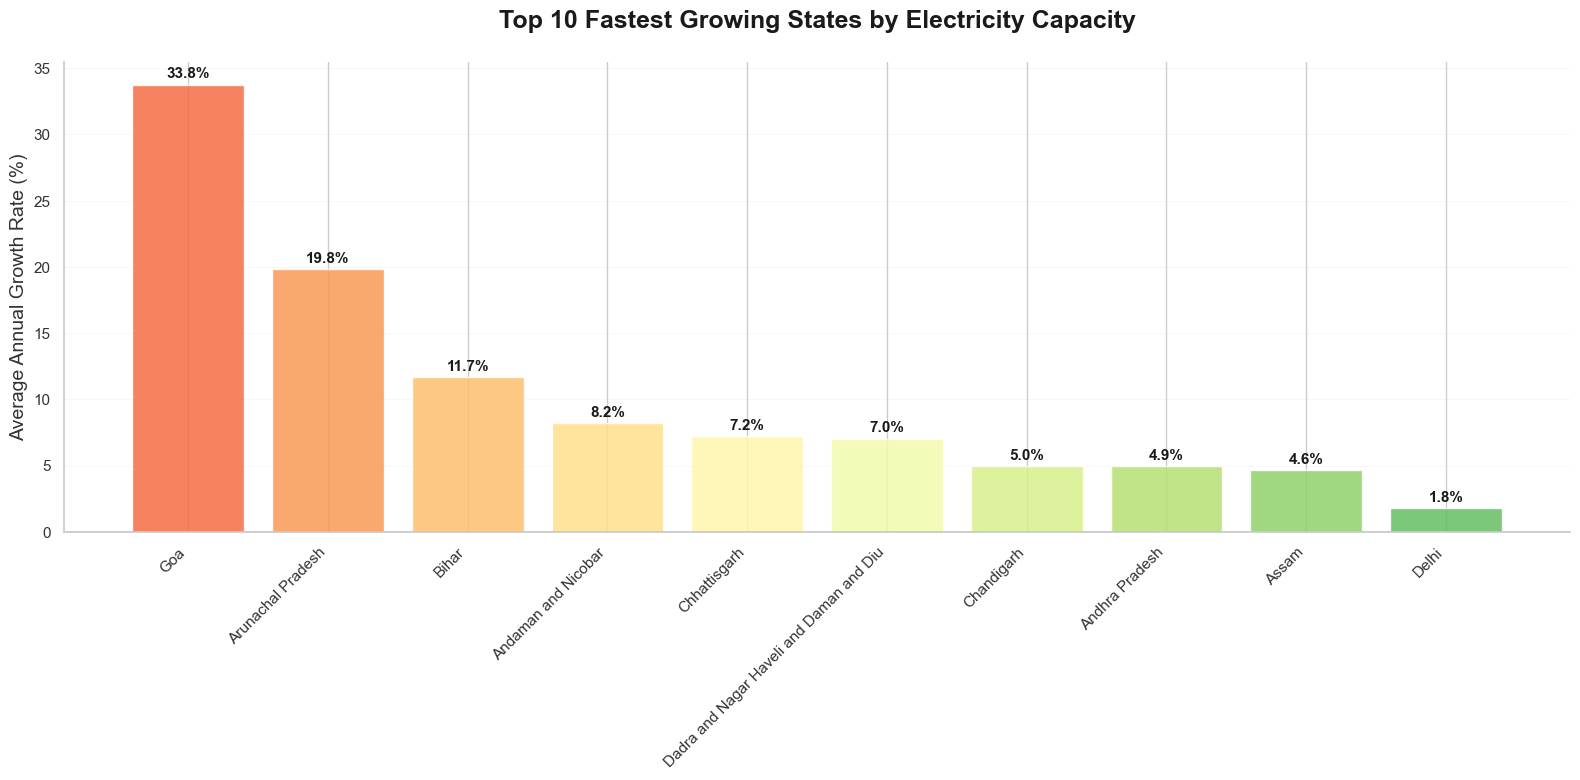

In [25]:
plt.figure(figsize=(16, 8))

colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(growth_df)))
bars = plt.bar(range(len(growth_df)), growth_df['Avg_Growth'], 
               color=colors, alpha=0.85, edgecolor='white', linewidth=1)

plt.xticks(range(len(growth_df)), growth_df['State'], rotation=45, ha='right', fontsize=11)
plt.ylabel('Average Annual Growth Rate (%)', fontsize=14, color='#333333')
plt.title('Top 10 Fastest Growing States by Electricity Capacity', 
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')

for i, (_, row) in enumerate(growth_df.iterrows()):
    plt.text(i, row['Avg_Growth'] + 0.5, f'{row["Avg_Growth"]:.1f}%', 
             ha='center', fontsize=11, fontweight='bold', color='#1a1a1a')

plt.axhline(y=0, color='#1a1a1a', linewidth=1)
plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

# Section 4: Fuel-Type Analysis

### Key Questions
- Which fuel types dominate India's installed electricity capacity?
- How have renewable technologies (solar, wind, hydro) grown over time?
- What is the current fuel mix composition?
- How do fossil and renewable capacity additions compare?

### Analysis Focus
- Fuel type rankings by total installed capacity
- Renewable technology growth trajectories and acceleration patterns
- Current energy portfolio composition and major contributors
- Fossil vs renewable capacity evolution and transition dynamics

In [26]:
fuel_totals = df.groupby('Variable')['Value'].sum().sort_values(ascending=False)

print(f"Fuel Type Overview:")
print(f"Total fuel categories: {len(fuel_totals)}")
print(f"Dominant fuel: {fuel_totals.index[0]} ({fuel_totals.iloc[0]:,.0f} MW)")
print(f"Top 3 concentration: {(fuel_totals.head(3).sum() / fuel_totals.sum() * 100):.1f}%")

Fuel Type Overview:
Total fuel categories: 18
Dominant fuel: Fossil (69,765,989 MW)
Top 3 concentration: 57.4%


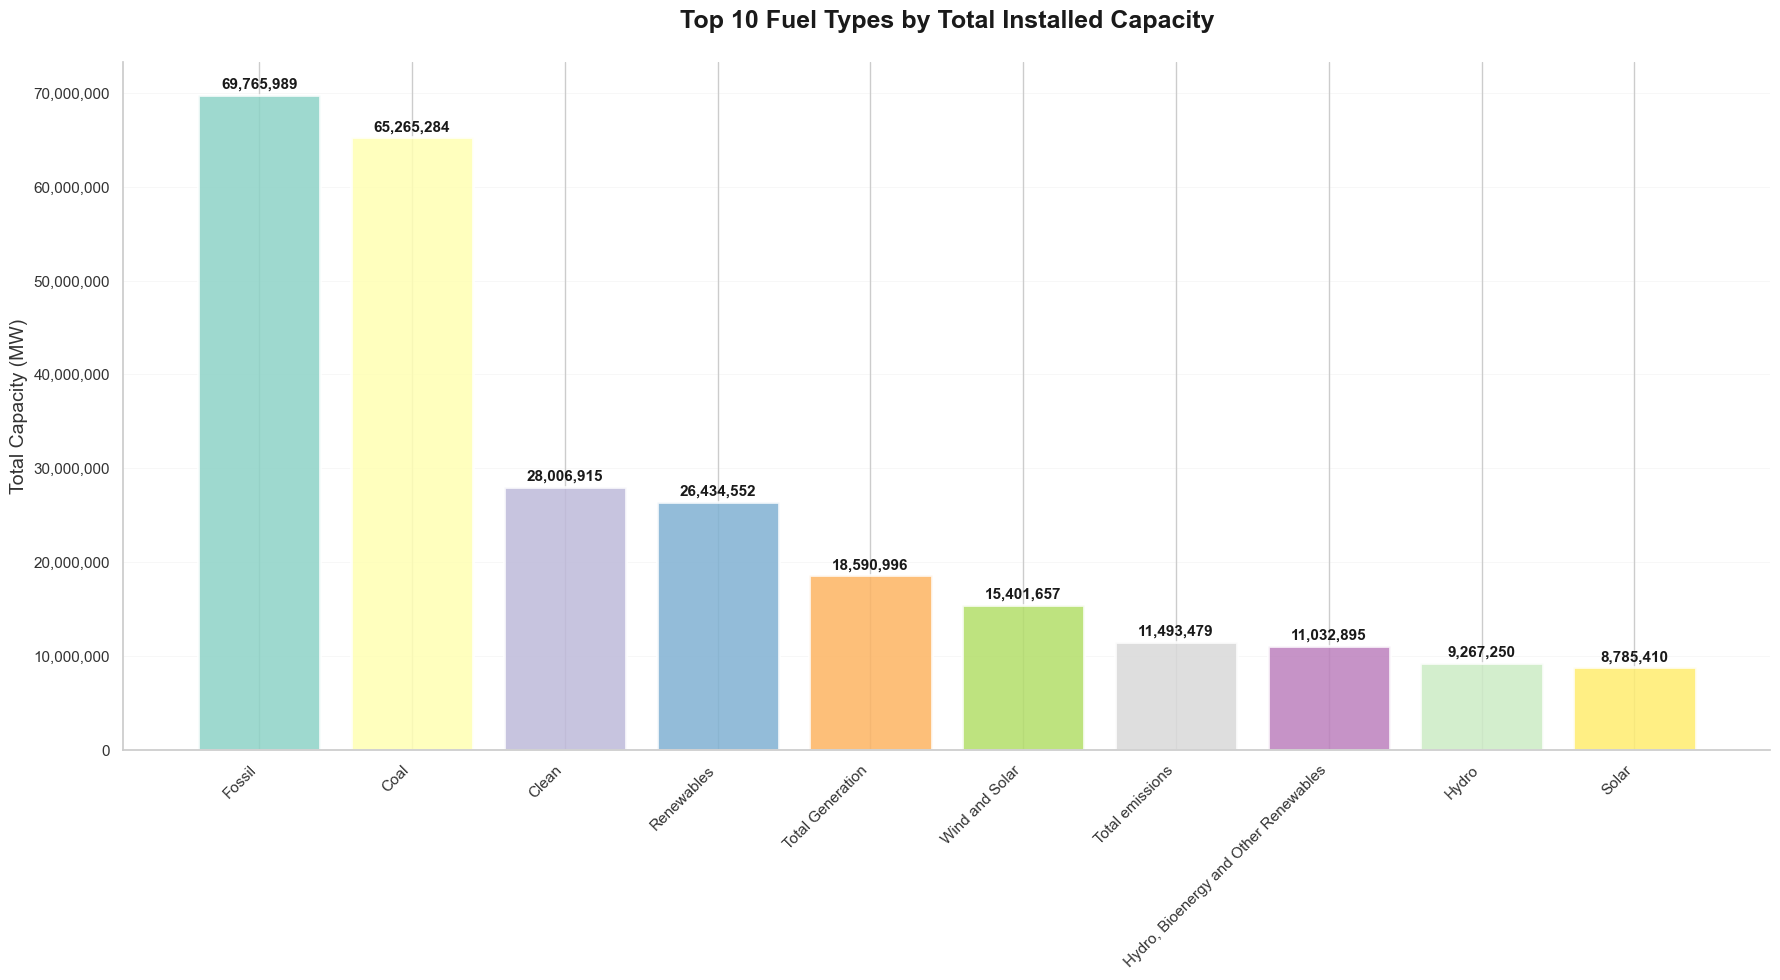

In [27]:
plt.figure(figsize=(18, 10))

top_10_fuels = fuel_totals.head(10)
colors = plt.cm.Set3(np.linspace(0, 1, len(top_10_fuels)))

bars = plt.bar(range(len(top_10_fuels)), top_10_fuels.values, 
               color=colors, alpha=0.85, edgecolor='white', linewidth=2)

plt.xticks(range(len(top_10_fuels)), top_10_fuels.index, rotation=45, ha='right', fontsize=12)
plt.ylabel('Total Capacity (MW)', fontsize=14, color='#333333')
plt.title('Top 10 Fuel Types by Total Installed Capacity', 
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')

for i, (fuel, value) in enumerate(top_10_fuels.items()):
    plt.text(i, value + max(top_10_fuels.values) * 0.01, f'{value:,.0f}', 
             ha='center', fontsize=11, fontweight='bold', color='#1a1a1a', rotation=0)

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [28]:
renewable_fuels_list = ['Solar', 'Wind', 'Hydro']
renewable_evolution = df[df['Variable'].isin(renewable_fuels_list)]
renewable_yearly = renewable_evolution.groupby(['Year', 'Variable'])['Value'].sum().reset_index()

print(f"Renewable Fuel Growth:")
for fuel in renewable_fuels_list:
    fuel_data = renewable_yearly[renewable_yearly['Variable'] == fuel]
    if len(fuel_data) > 1:
        start_value = fuel_data['Value'].iloc[0]
        end_value = fuel_data['Value'].iloc[-1]
        growth = ((end_value / start_value) - 1) * 100 if start_value > 0 else 0
        print(f"{fuel}: {growth:,.0f}% total growth")

Renewable Fuel Growth:
Solar: 229% total growth
Wind: 49% total growth
Hydro: 17% total growth


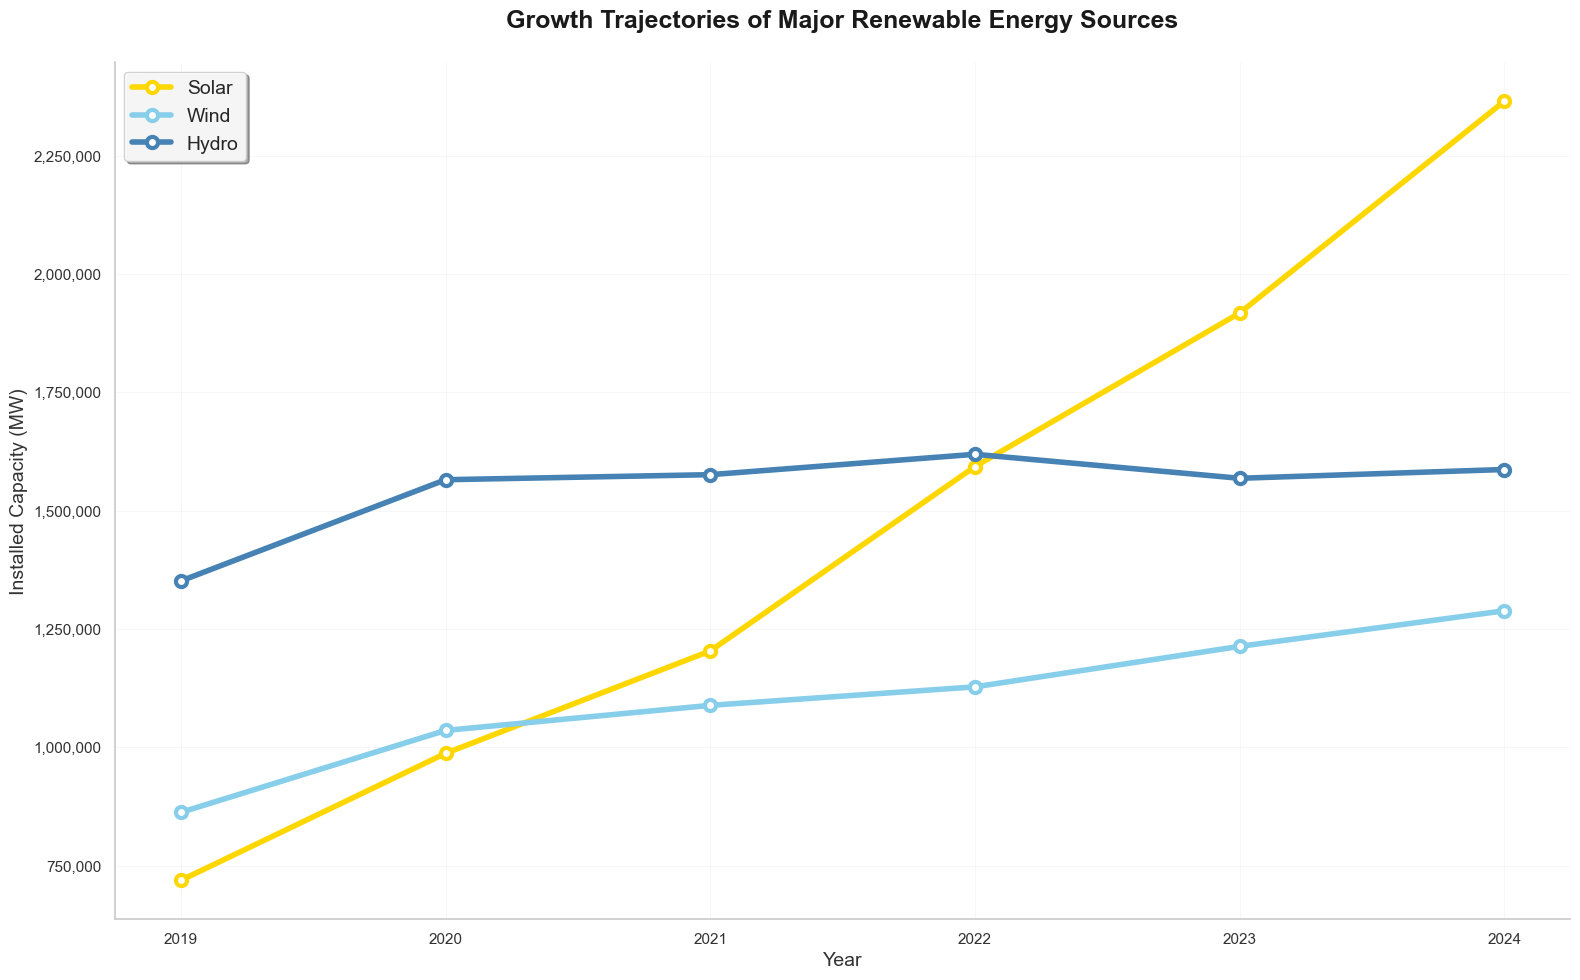

In [29]:
plt.figure(figsize=(16, 10))

fuel_colors = {'Solar': '#FFD700', 'Wind': '#87CEEB', 'Hydro': '#4682B4'}

for fuel in renewable_fuels_list:
    fuel_data = renewable_yearly[renewable_yearly['Variable'] == fuel].sort_values('Year')
    plt.plot(fuel_data['Year'], fuel_data['Value'], 
             marker='o', linewidth=4, markersize=8, 
             color=fuel_colors[fuel], label=fuel,
             markerfacecolor='white', markeredgecolor=fuel_colors[fuel], markeredgewidth=3)

plt.title('Growth Trajectories of Major Renewable Energy Sources', 
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')
plt.xlabel('Year', fontsize=14, color='#333333')
plt.ylabel('Installed Capacity (MW)', fontsize=14, color='#333333')

legend = plt.legend(fontsize=14, frameon=True, fancybox=True, shadow=True, framealpha=0.9, loc='upper left')
legend.get_frame().set_facecolor('white')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [30]:
latest_year = df['Year'].max()
latest_composition = df[df['Year'] == latest_year].groupby('Variable')['Value'].sum()
latest_composition = latest_composition[latest_composition > latest_composition.sum() * 0.02]

other_capacity = df[df['Year'] == latest_year]['Value'].sum() - latest_composition.sum()
if other_capacity > 0:
    latest_composition['Other'] = other_capacity

latest_composition = latest_composition.sort_values(ascending=False)

print(f"Current Fuel Mix ({latest_year}):")
for fuel, capacity in latest_composition.head(5).items():
    pct = (capacity / latest_composition.sum()) * 100
    print(f"{fuel}: {pct:.1f}% ({capacity:,.0f} MW)")

Current Fuel Mix (2024):
Fossil: 23.4% (13,002,003 MW)
Coal: 22.0% (12,250,212 MW)
Clean: 10.5% (5,858,362 MW)
Renewables: 10.0% (5,552,279 MW)
Wind and Solar: 6.6% (3,653,283 MW)


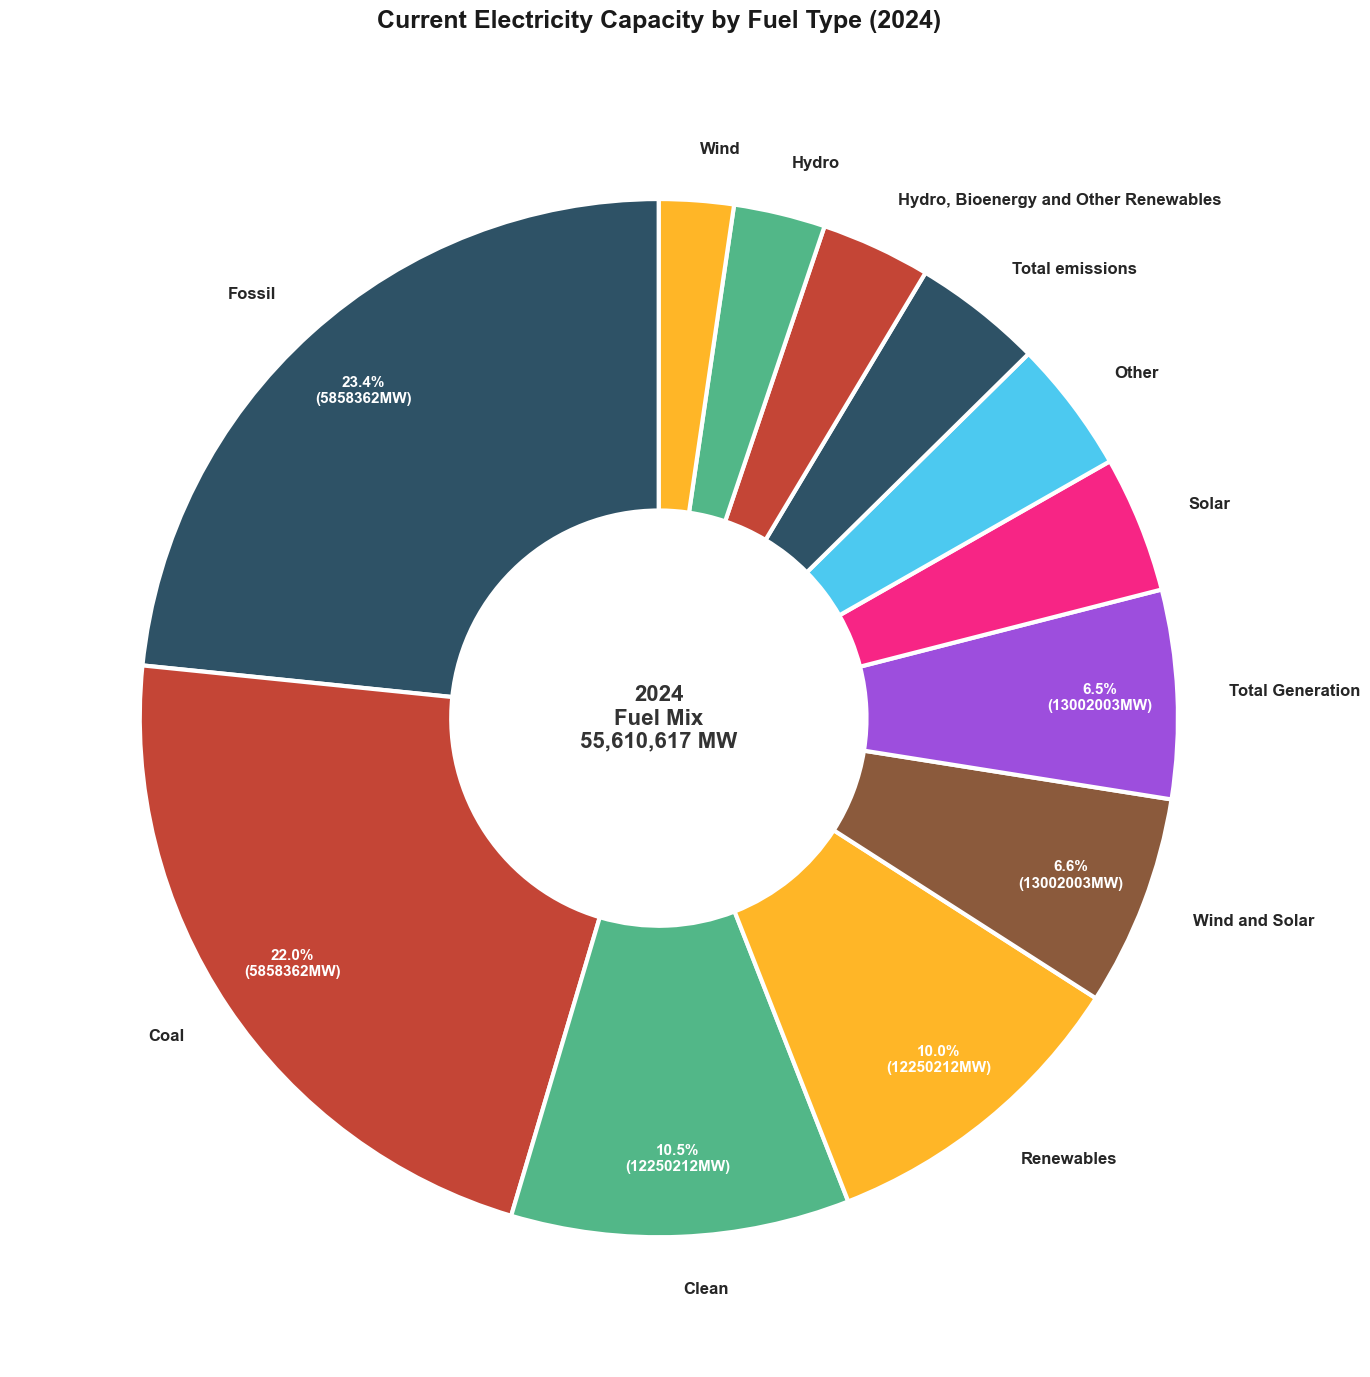

In [31]:
plt.figure(figsize=(14, 14))

colors = ['#2E5266', '#C44536', '#52B788', '#FFB627', '#8B5A3C', '#9D4EDD', '#F72585', '#4CC9F0']
colors = colors[:len(latest_composition)]

wedges, texts, autotexts = plt.pie(latest_composition.values, labels=latest_composition.index, 
                                  autopct=lambda pct: f'{pct:.1f}%\n({latest_composition.iloc[int(pct/100*len(latest_composition))]:.0f}MW)' if pct > 5 else '',
                                  colors=colors, startangle=90, pctdistance=0.85,
                                  wedgeprops=dict(width=0.6, edgecolor='white', linewidth=3))

centre_circle = plt.Circle((0,0), 0.40, fc='white')
plt.gca().add_artist(centre_circle)

for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(11)

for text in texts:
    text.set_fontsize(12)
    text.set_fontweight('bold')

plt.text(0, 0, f'{latest_year}\nFuel Mix\n{latest_composition.sum():,.0f} MW', 
        horizontalalignment='center', verticalalignment='center',
        fontsize=16, fontweight='bold', color='#333333')

plt.title(f'Current Electricity Capacity by Fuel Type ({latest_year})', 
          fontsize=18, fontweight='bold', pad=30, color='#1a1a1a')

plt.tight_layout()
plt.show()

In [32]:
fossil_fuels = ['Coal', 'Gas', 'Oil']
fossil_evolution = df[df['Variable'].isin(fossil_fuels)]
fossil_yearly = fossil_evolution.groupby(['Year', 'Variable'])['Value'].sum().reset_index()

combined_data = pd.concat([
    renewable_yearly.assign(Category='Renewable'),
    fossil_yearly.assign(Category='Fossil')
])

print(f"Fossil vs Renewable Comparison:")
for category in ['Fossil', 'Renewable']:
    cat_data = combined_data[combined_data['Category'] == category]
    total_current = cat_data[cat_data['Year'] == cat_data['Year'].max()]['Value'].sum()
    print(f"{category} total capacity: {total_current:,.0f} MW")

Fossil vs Renewable Comparison:
Fossil total capacity: 12,985,693 MW
Renewable total capacity: 5,240,202 MW


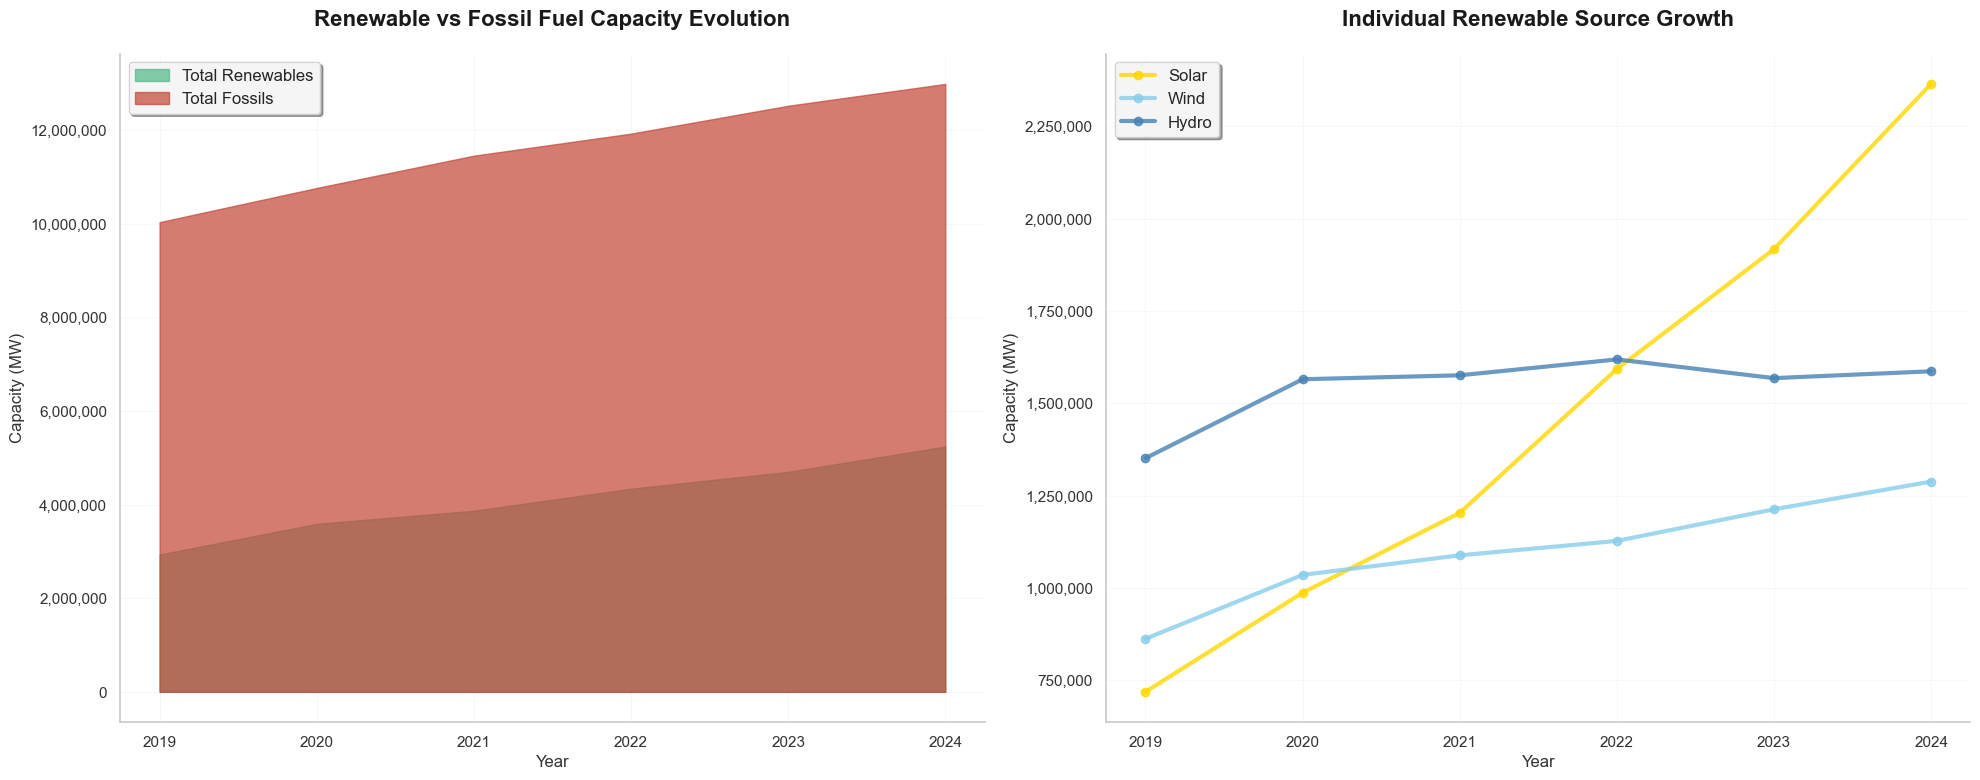

In [33]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

renewable_summary = renewable_yearly.groupby('Year')['Value'].sum()
fossil_summary = fossil_yearly.groupby('Year')['Value'].sum()

ax1.fill_between(renewable_summary.index, renewable_summary.values, 
                alpha=0.7, color='#52B788', label='Total Renewables')
ax1.fill_between(fossil_summary.index, fossil_summary.values, 
                alpha=0.7, color='#C44536', label='Total Fossils')

ax1.set_title('Renewable vs Fossil Fuel Capacity Evolution', 
              fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')
ax1.set_xlabel('Year', fontsize=12, color='#333333')
ax1.set_ylabel('Capacity (MW)', fontsize=12, color='#333333')
ax1.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(colors='#333333', labelsize=11)

for fuel in renewable_fuels_list:
    fuel_data = renewable_yearly[renewable_yearly['Variable'] == fuel].sort_values('Year')
    ax2.plot(fuel_data['Year'], fuel_data['Value'], 
             marker='o', linewidth=3, markersize=6, 
             color=fuel_colors[fuel], label=fuel, alpha=0.8)

ax2.set_title('Individual Renewable Source Growth', 
              fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')
ax2.set_xlabel('Year', fontsize=12, color='#333333')
ax2.set_ylabel('Capacity (MW)', fontsize=12, color='#333333')
ax2.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(colors='#333333', labelsize=11)

for ax in [ax1, ax2]:
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

plt.tight_layout()
plt.show()

# Section 5: Growth Dynamics & Year-over-Year Analysis

### Key Questions
- Which states and fuel types are experiencing the fastest capacity growth?
- How do growth rates vary seasonally throughout the year?
- What are the most stable vs volatile growth patterns?
- Which segments show consistent expansion vs erratic development?

### Analysis Focus
- Recent growth leaders among states and fuel types
- Seasonal growth patterns and monthly variations
- Growth volatility analysis for stability assessment
- Capacity addition trends and momentum indicators

In [34]:
df['YoY_Growth_Rate'] = df.groupby(['State', 'Variable'])['Value'].pct_change(periods=12) * 100
df['YoY_Absolute_Change'] = df.groupby(['State', 'Variable'])['Value'].diff(periods=12)

growth_summary = df.dropna(subset=['YoY_Growth_Rate'])

print(f"Growth Analysis Overview:")
print(f"Records with growth data: {len(growth_summary):,}")
print(f"Average growth rate: {growth_summary['YoY_Growth_Rate'].mean():.1f}%")
print(f"Growth rate range: {growth_summary['YoY_Growth_Rate'].min():.1f}% to {growth_summary['YoY_Growth_Rate'].max():.1f}%")

Growth Analysis Overview:
Records with growth data: 120,580
Average growth rate: inf%
Growth rate range: -100.0% to inf%


In [35]:
latest_two_years = sorted(df['Year'].unique())[-2:]
recent_growth = df[df['Year'].isin(latest_two_years)]

state_growth = recent_growth.groupby(['State', 'Year'])['Value'].sum().reset_index()
state_growth_pivot = state_growth.pivot(index='State', columns='Year', values='Value').fillna(0)
state_growth_pivot.columns = ['Previous_Year', 'Current_Year']
state_growth_pivot['YoY_Change'] = ((state_growth_pivot['Current_Year'] / state_growth_pivot['Previous_Year']) - 1) * 100
state_growth_pivot = state_growth_pivot[~state_growth_pivot.index.str.contains('India Total', na=False)]

top_gainers = state_growth_pivot.sort_values('YoY_Change', ascending=False).head(10)
top_decliners = state_growth_pivot.sort_values('YoY_Change', ascending=True).head(10)

print(f"Top Growth States ({latest_two_years[0]}-{latest_two_years[1]}):")
for state, change in top_gainers['YoY_Change'].head(5).items():
    print(f"{state}: +{change:.1f}%")

Top Growth States (2023-2024):
Gujarat: +18.8%
Rajasthan: +15.7%
Jharkhand: +14.1%
Manipur: +13.3%
Kerala: +12.0%


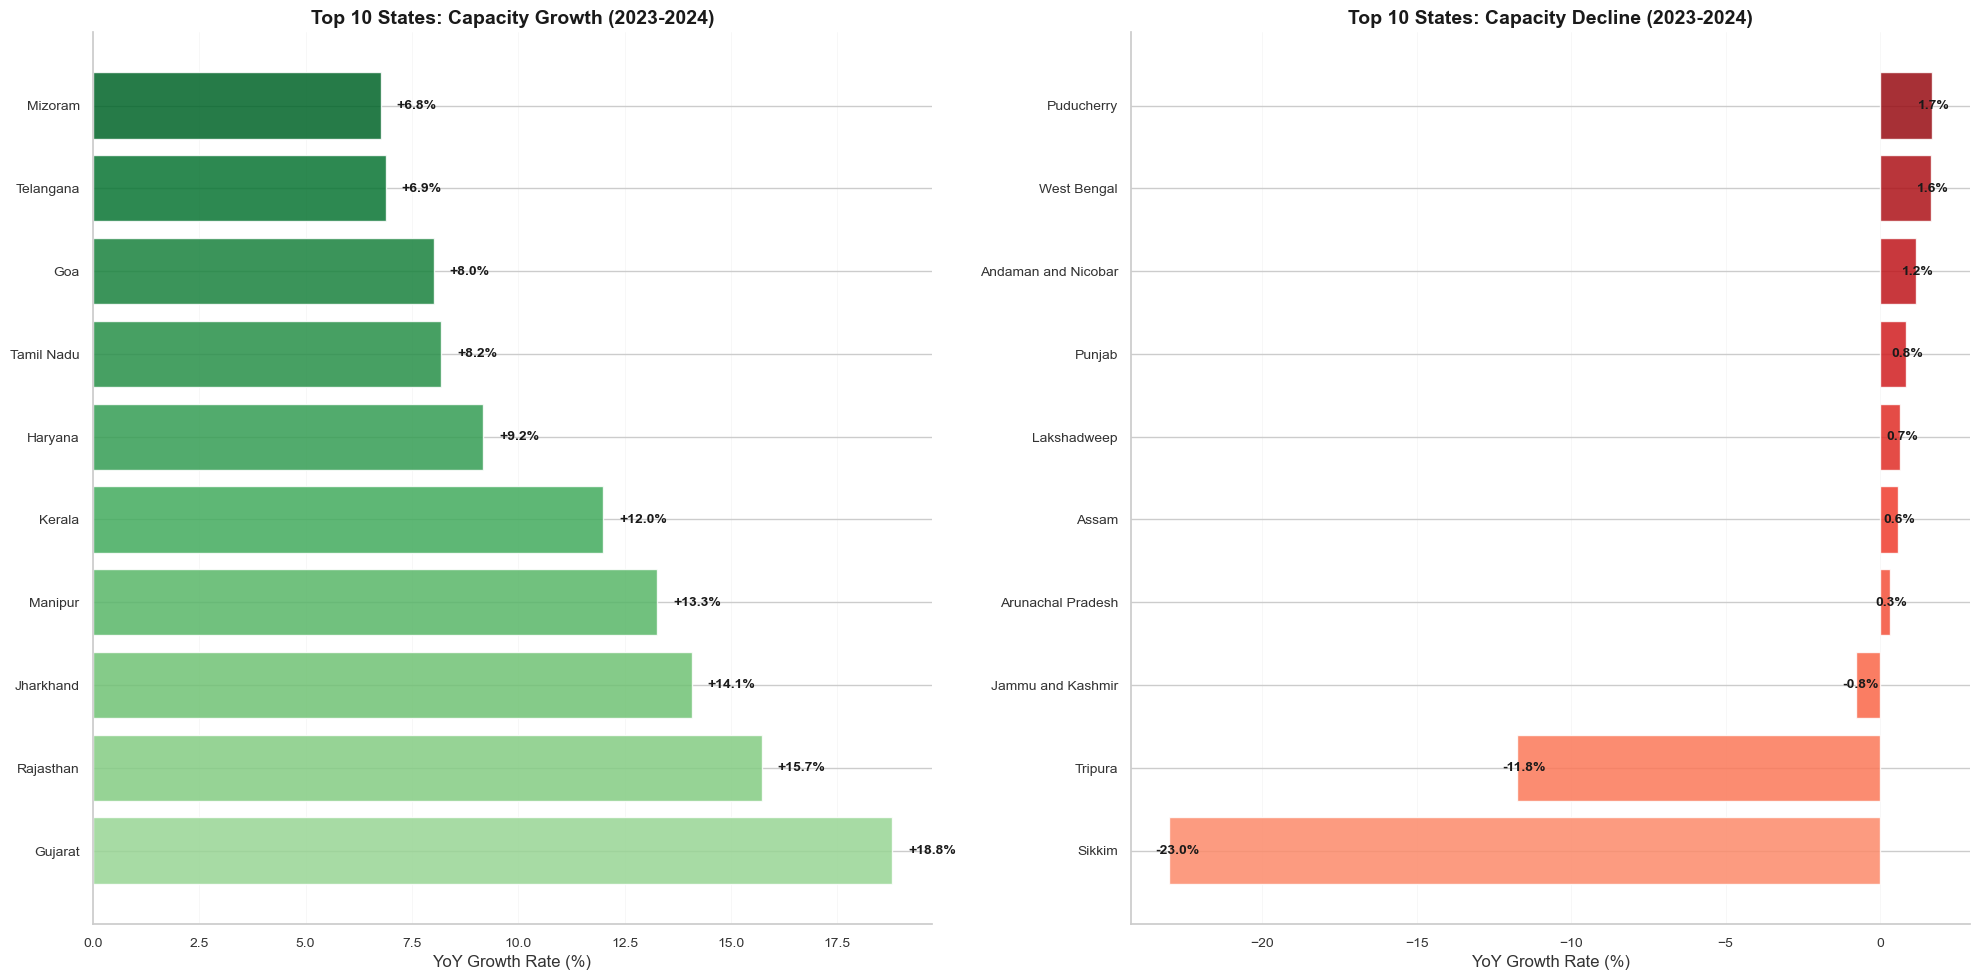

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 10))

colors_gain = plt.cm.Greens(np.linspace(0.4, 0.9, len(top_gainers)))
bars1 = ax1.barh(range(len(top_gainers)), top_gainers['YoY_Change'], 
                 color=colors_gain, alpha=0.85, edgecolor='white', linewidth=1)

ax1.set_yticks(range(len(top_gainers)))
ax1.set_yticklabels(top_gainers.index, fontsize=11)
ax1.set_xlabel('YoY Growth Rate (%)', fontsize=12, color='#333333')
ax1.set_title(f'Top 10 States: Capacity Growth ({latest_two_years[0]}-{latest_two_years[1]})', 
              fontsize=14, fontweight='bold', color='#1a1a1a')

for i, (state, change) in enumerate(top_gainers['YoY_Change'].items()):
    ax1.text(change + max(top_gainers['YoY_Change']) * 0.02, i, f'+{change:.1f}%', 
             va='center', fontsize=10, fontweight='bold', color='#1a1a1a')

colors_decline = plt.cm.Reds(np.linspace(0.4, 0.9, len(top_decliners)))
bars2 = ax2.barh(range(len(top_decliners)), top_decliners['YoY_Change'], 
                 color=colors_decline, alpha=0.85, edgecolor='white', linewidth=1)

ax2.set_yticks(range(len(top_decliners)))
ax2.set_yticklabels(top_decliners.index, fontsize=11)
ax2.set_xlabel('YoY Growth Rate (%)', fontsize=12, color='#333333')
ax2.set_title(f'Top 10 States: Capacity Decline ({latest_two_years[0]}-{latest_two_years[1]})', 
              fontsize=14, fontweight='bold', color='#1a1a1a')

for i, (state, change) in enumerate(top_decliners['YoY_Change'].items()):
    ax2.text(change + min(top_decliners['YoY_Change']) * 0.02, i, f'{change:.1f}%', 
             va='center', fontsize=10, fontweight='bold', color='#1a1a1a')

for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(colors='#333333', labelsize=10)

plt.tight_layout()
plt.show()

In [37]:
fuel_growth = recent_growth.groupby(['Variable', 'Year'])['Value'].sum().reset_index()
fuel_growth_pivot = fuel_growth.pivot(index='Variable', columns='Year', values='Value').fillna(0)
fuel_growth_pivot.columns = ['Previous_Year', 'Current_Year']
fuel_growth_pivot['YoY_Change'] = ((fuel_growth_pivot['Current_Year'] / fuel_growth_pivot['Previous_Year']) - 1) * 100
fuel_growth_pivot['Absolute_Change'] = fuel_growth_pivot['Current_Year'] - fuel_growth_pivot['Previous_Year']

fuel_growth_clean = fuel_growth_pivot[fuel_growth_pivot['Previous_Year'] > 0]
top_fuel_gainers = fuel_growth_clean.sort_values('YoY_Change', ascending=False).head(8)

print(f"Fastest Growing Fuel Types ({latest_two_years[0]}-{latest_two_years[1]}):")
for fuel, change in top_fuel_gainers['YoY_Change'].head(5).items():
    abs_change = top_fuel_gainers.loc[fuel, 'Absolute_Change']
    print(f"{fuel}: +{change:.1f}% ({abs_change:+,.0f} MW)")

Fastest Growing Fuel Types (2023-2024):
Solar: +23.3% (+447,404 MW)
Wind and Solar: +16.7% (+522,544 MW)
Nuclear: +12.6% (+34,330 MW)
Clean: +10.9% (+577,654 MW)
Renewables: +10.8% (+543,323 MW)


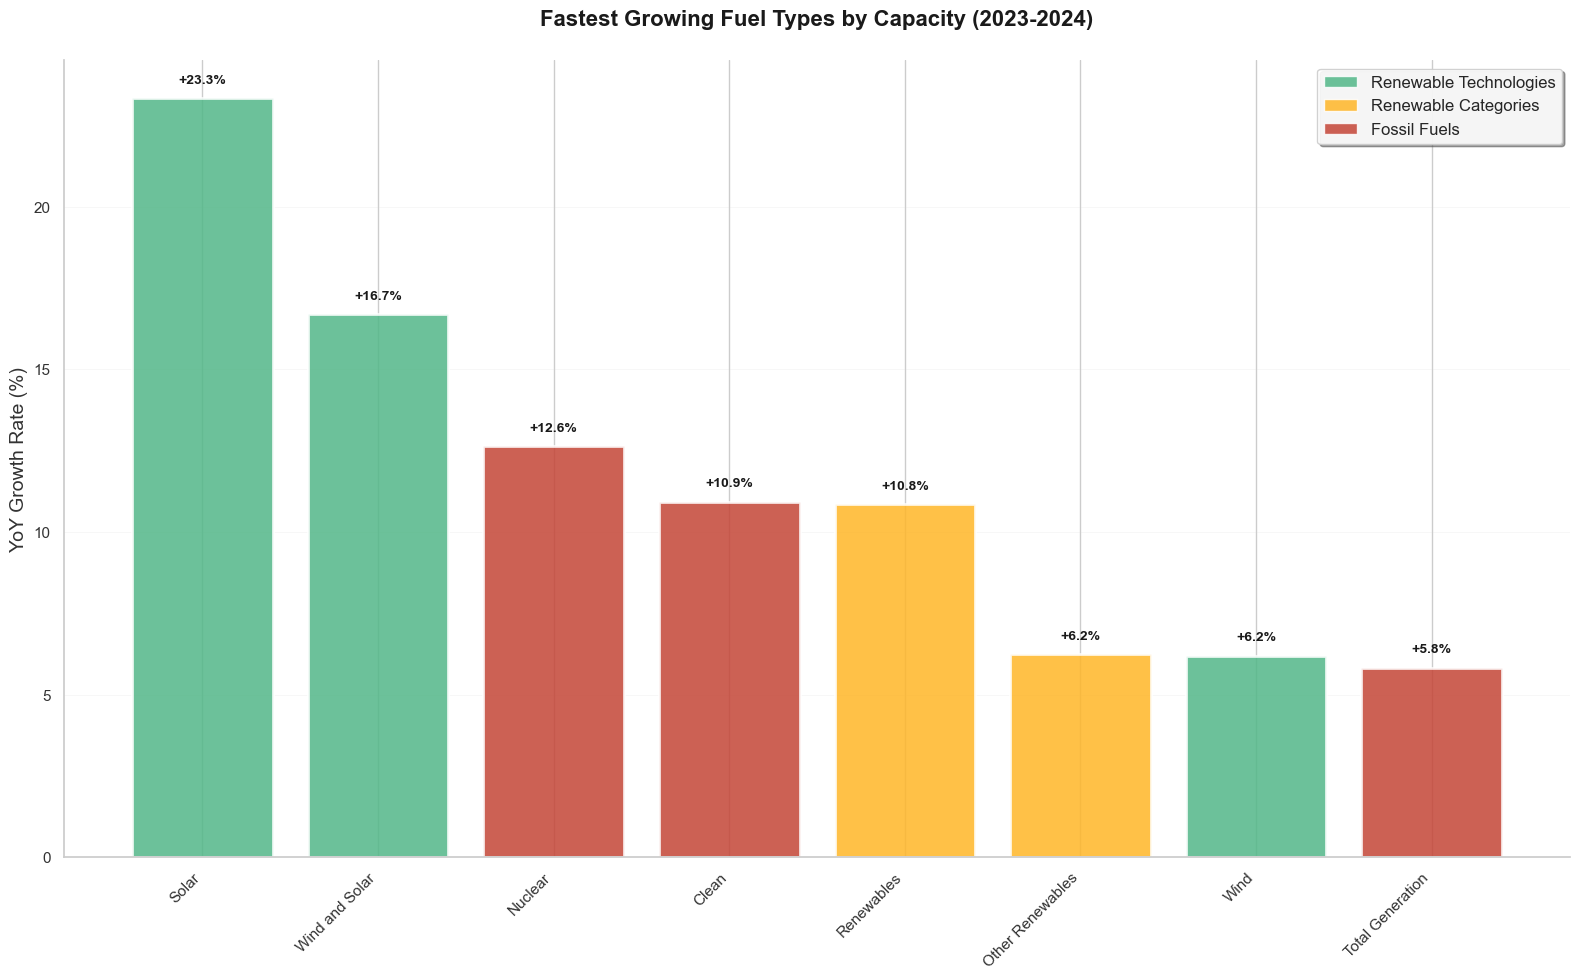

In [38]:
plt.figure(figsize=(16, 10))

colors = ['#52B788' if 'Solar' in fuel or 'Wind' in fuel or 'Hydro' in fuel 
          else '#FFB627' if 'Renewable' in fuel 
          else '#C44536' for fuel in top_fuel_gainers.index]

bars = plt.bar(range(len(top_fuel_gainers)), top_fuel_gainers['YoY_Change'], 
               color=colors, alpha=0.85, edgecolor='white', linewidth=2)

plt.xticks(range(len(top_fuel_gainers)), top_fuel_gainers.index, rotation=45, ha='right', fontsize=11)
plt.ylabel('YoY Growth Rate (%)', fontsize=14, color='#333333')
plt.title(f'Fastest Growing Fuel Types by Capacity ({latest_two_years[0]}-{latest_two_years[1]})', 
          fontsize=16, fontweight='bold', pad=25, color='#1a1a1a')

for i, (fuel, change) in enumerate(top_fuel_gainers['YoY_Change'].items()):
    plt.text(i, change + max(top_fuel_gainers['YoY_Change']) * 0.02, f'+{change:.1f}%', 
             ha='center', fontsize=10, fontweight='bold', color='#1a1a1a')

legend_elements = [
    plt.Rectangle((0,0),1,1, facecolor='#52B788', alpha=0.85, label='Renewable Technologies'),
    plt.Rectangle((0,0),1,1, facecolor='#FFB627', alpha=0.85, label='Renewable Categories'),
    plt.Rectangle((0,0),1,1, facecolor='#C44536', alpha=0.85, label='Fossil Fuels')
]
legend = plt.legend(handles=legend_elements, fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')

plt.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.gca().spines['left'].set_color('#cccccc')
plt.gca().spines['bottom'].set_color('#cccccc')
plt.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [39]:
monthly_growth = df.groupby(['Year', 'Month'])['Value'].sum().reset_index()
monthly_growth['Date'] = pd.to_datetime(monthly_growth[['Year', 'Month']].assign(day=1))
monthly_growth = monthly_growth.sort_values('Date')
monthly_growth['YoY_Growth'] = monthly_growth['Value'].pct_change(periods=12) * 100

recent_months = monthly_growth.tail(24)

seasonal_pattern = recent_months.groupby('Month')['YoY_Growth'].mean().reset_index()
month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

print(f"Seasonal Growth Patterns (Last 24 months):")
print(f"Strongest growth month: {month_names[seasonal_pattern.loc[seasonal_pattern['YoY_Growth'].idxmax(), 'Month']-1]}")
print(f"Weakest growth month: {month_names[seasonal_pattern.loc[seasonal_pattern['YoY_Growth'].idxmin(), 'Month']-1]}")

Seasonal Growth Patterns (Last 24 months):
Strongest growth month: Oct
Weakest growth month: Mar


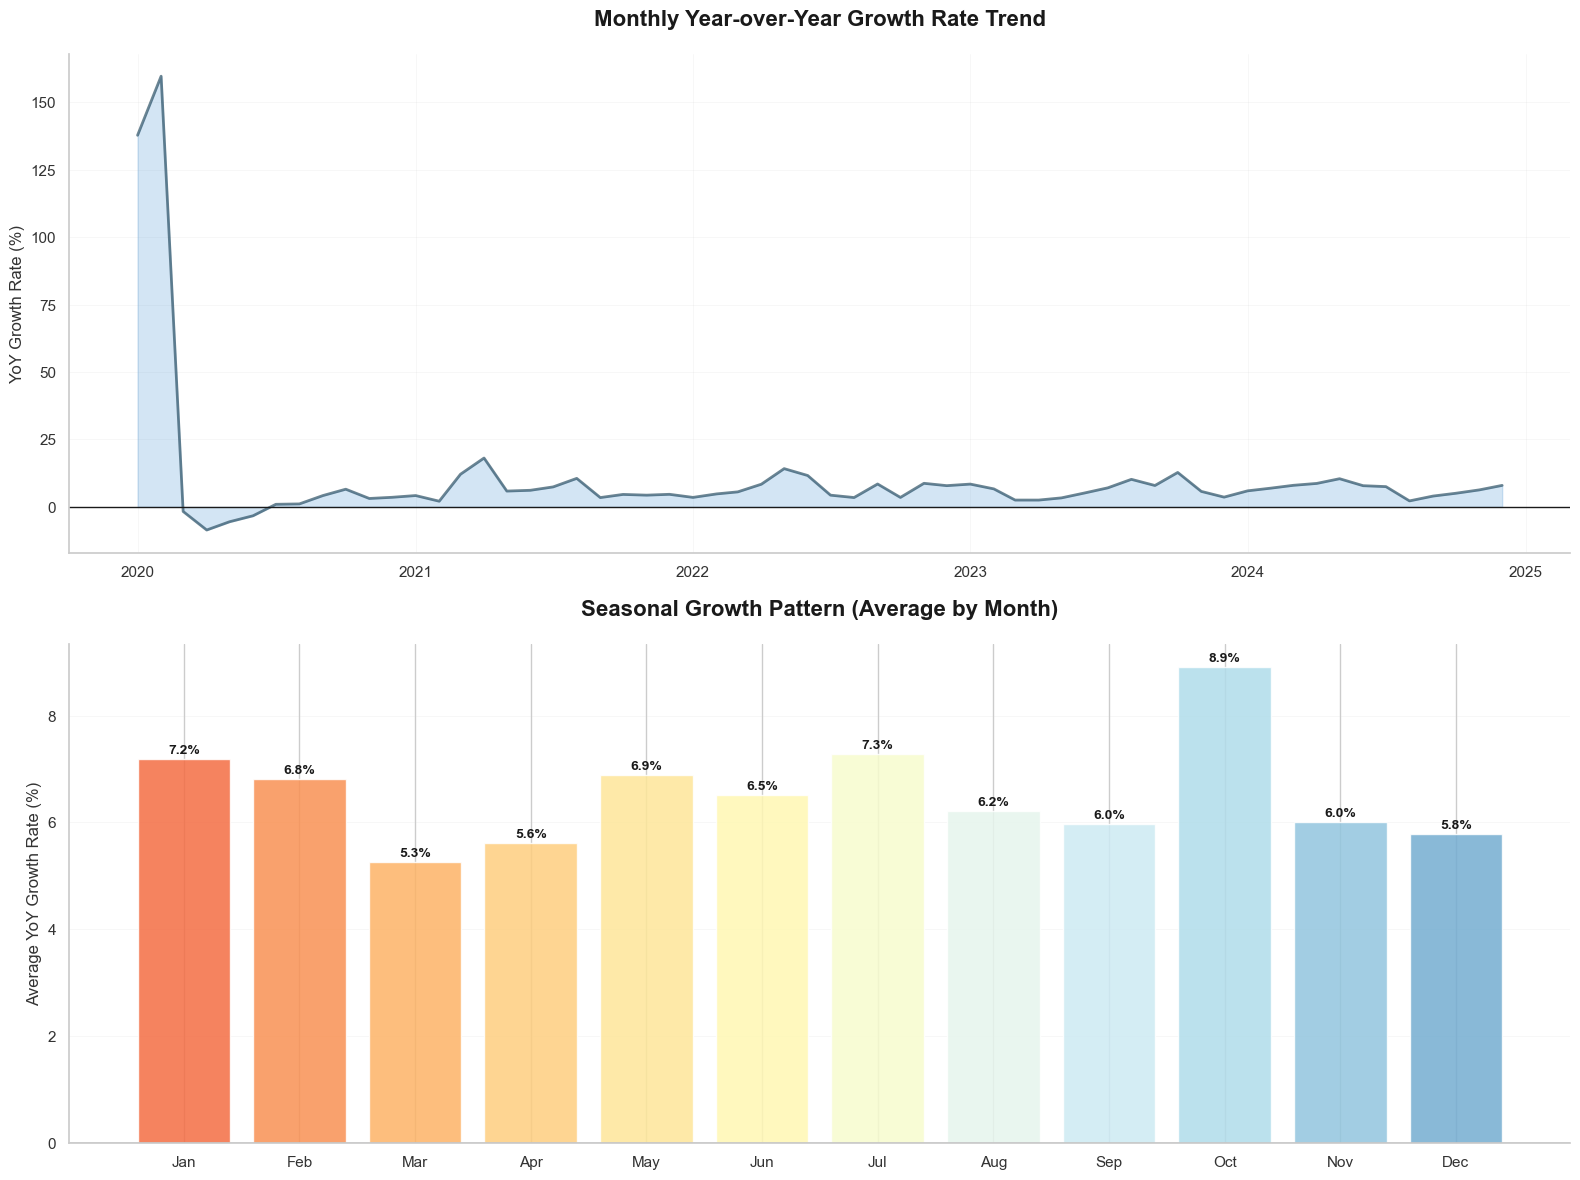

In [40]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 12))

ax1.plot(monthly_growth['Date'], monthly_growth['YoY_Growth'], 
         linewidth=2, color='#2E5266', alpha=0.7)
ax1.fill_between(monthly_growth['Date'], monthly_growth['YoY_Growth'], 
                 alpha=0.3, color='#6FAADB')

ax1.set_title('Monthly Year-over-Year Growth Rate Trend', 
              fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')
ax1.set_ylabel('YoY Growth Rate (%)', fontsize=12, color='#333333')
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax1.axhline(y=0, color='#1a1a1a', linewidth=1)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(colors='#333333', labelsize=11)

colors_seasonal = plt.cm.RdYlBu(np.linspace(0.2, 0.8, len(seasonal_pattern)))
bars = ax2.bar(range(len(seasonal_pattern)), seasonal_pattern['YoY_Growth'], 
               color=colors_seasonal, alpha=0.85, edgecolor='white', linewidth=1)

ax2.set_xticks(range(len(seasonal_pattern)))
ax2.set_xticklabels([month_names[i-1] for i in seasonal_pattern['Month']], fontsize=11)
ax2.set_ylabel('Average YoY Growth Rate (%)', fontsize=12, color='#333333')
ax2.set_title('Seasonal Growth Pattern (Average by Month)', 
              fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')

for i, (_, row) in enumerate(seasonal_pattern.iterrows()):
    ax2.text(i, row['YoY_Growth'] + 0.1, f'{row["YoY_Growth"]:.1f}%', 
             ha='center', fontsize=10, fontweight='bold', color='#1a1a1a')

ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
ax2.axhline(y=0, color='#1a1a1a', linewidth=1)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [41]:
growth_volatility = df.groupby(['State', 'Variable']).apply(
    lambda x: x['Value'].pct_change().std() * 100 if len(x) > 1 else 0
).reset_index()
growth_volatility.columns = ['State', 'Variable', 'Volatility']
growth_volatility = growth_volatility[~growth_volatility['State'].str.contains('India Total', na=False)]

state_volatility = growth_volatility.groupby('State')['Volatility'].mean().sort_values()
fuel_volatility = growth_volatility.groupby('Variable')['Volatility'].mean().sort_values()

most_stable_states = state_volatility.head(10)
most_volatile_fuels = fuel_volatility.tail(8)

print(f"Capacity Growth Stability:")
print(f"Most stable states (lowest volatility):")
for state, vol in most_stable_states.head(3).items():
    print(f"  {state}: {vol:.1f}% volatility")

Capacity Growth Stability:
Most stable states (lowest volatility):
  West Bengal: 5.9% volatility
  Chhattisgarh: 5.9% volatility
  Madhya Pradesh: 6.5% volatility


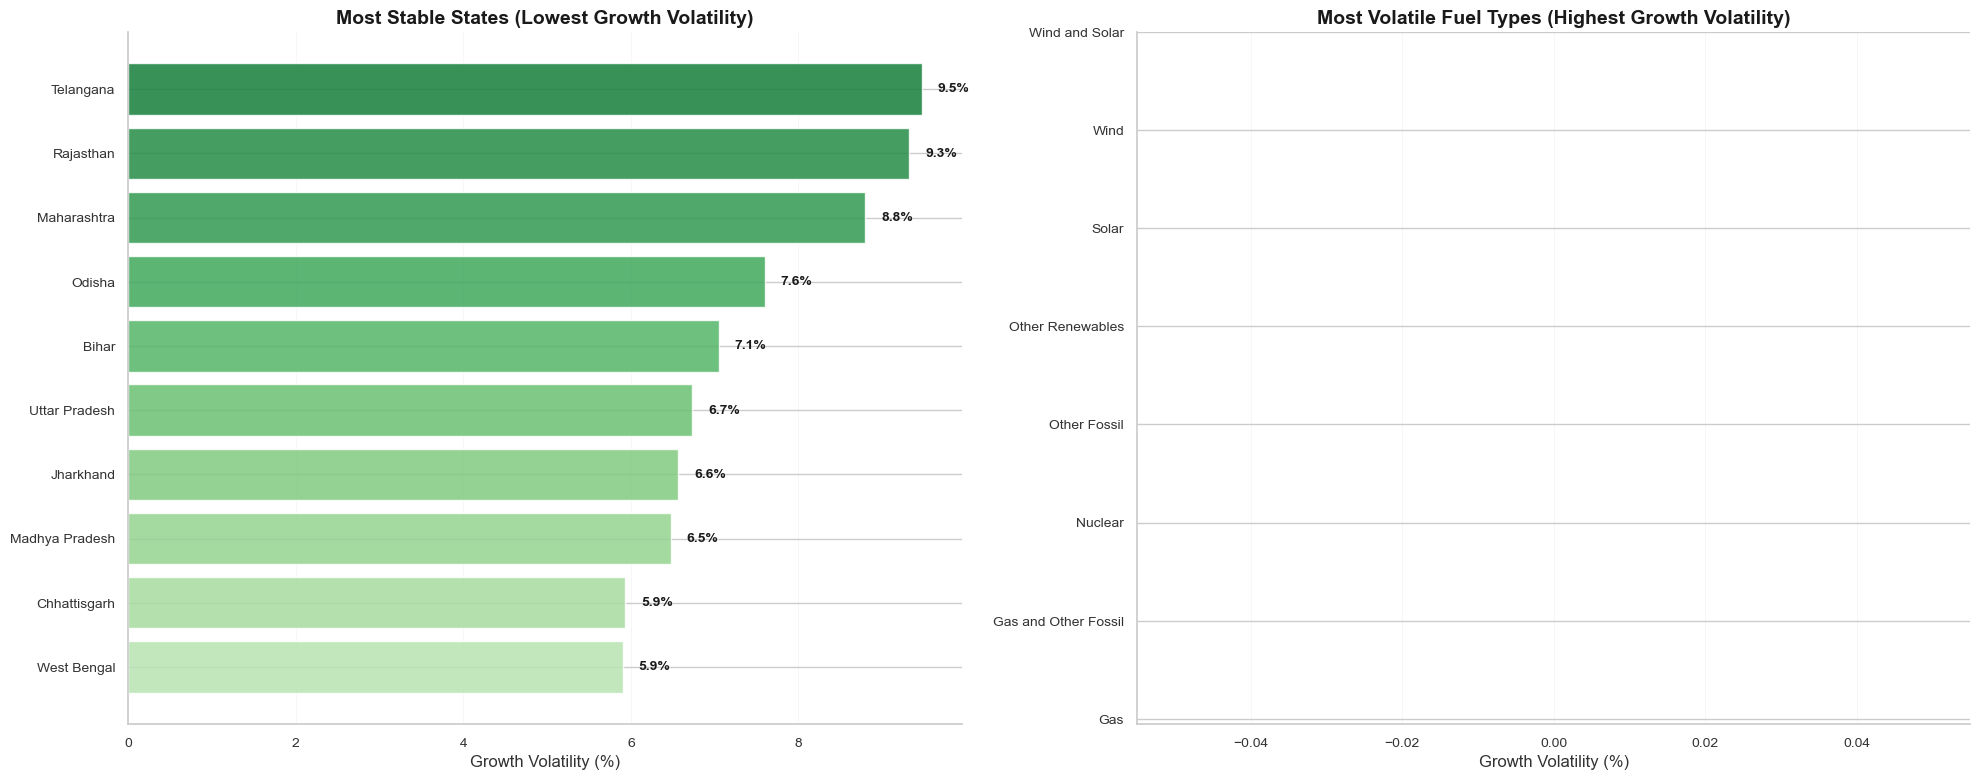

In [42]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

colors_stable = plt.cm.Greens(np.linspace(0.3, 0.8, len(most_stable_states)))
bars1 = ax1.barh(range(len(most_stable_states)), most_stable_states.values, 
                 color=colors_stable, alpha=0.85, edgecolor='white', linewidth=1)

ax1.set_yticks(range(len(most_stable_states)))
ax1.set_yticklabels(most_stable_states.index, fontsize=11)
ax1.set_xlabel('Growth Volatility (%)', fontsize=12, color='#333333')
ax1.set_title('Most Stable States (Lowest Growth Volatility)', 
              fontsize=14, fontweight='bold', color='#1a1a1a')

for i, (state, vol) in enumerate(most_stable_states.items()):
    ax1.text(vol + max(most_stable_states.values) * 0.02, i, f'{vol:.1f}%', 
             va='center', fontsize=10, fontweight='bold', color='#1a1a1a')

colors_volatile = plt.cm.Reds(np.linspace(0.4, 0.9, len(most_volatile_fuels)))
bars2 = ax2.barh(range(len(most_volatile_fuels)), most_volatile_fuels.values, 
                 color=colors_volatile, alpha=0.85, edgecolor='white', linewidth=1)

ax2.set_yticks(range(len(most_volatile_fuels)))
ax2.set_yticklabels(most_volatile_fuels.index, fontsize=11)
ax2.set_xlabel('Growth Volatility (%)', fontsize=12, color='#333333')
ax2.set_title('Most Volatile Fuel Types (Highest Growth Volatility)', 
              fontsize=14, fontweight='bold', color='#1a1a1a')

for i, (fuel, vol) in enumerate(most_volatile_fuels.items()):
    ax2.text(vol + max(most_volatile_fuels.values) * 0.02, i, f'{vol:.1f}%', 
             va='center', fontsize=10, fontweight='bold', color='#1a1a1a')

for ax in [ax1, ax2]:
    ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='x')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#cccccc')
    ax.spines['bottom'].set_color('#cccccc')
    ax.tick_params(colors='#333333', labelsize=10)

plt.tight_layout()
plt.show()

# Section 6: Future Projections & Trend Analysis

### Key Questions
- What will India's total electricity capacity be by 2030 under current trends?
- When will renewable energy reach key milestone targets (30%, 40%)?
- How will individual renewable technologies (solar, wind, hydro) grow?
- Are current growth rates sufficient to meet policy objectives?

### Analysis Focus
- Linear trend projections based on recent historical performance
- Renewable vs fossil capacity evolution forecasts
- Technology-specific growth trajectories for solar, wind, and hydro
- Policy milestone analysis and target achievement timelines

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import numpy as np

forecast_years = [2025, 2026, 2027, 2028, 2029, 2030]
annual_data = df.groupby('Year')['Value'].sum().reset_index()
recent_data = annual_data.tail(10)

X = recent_data['Year'].values.reshape(-1, 1)
y = recent_data['Value'].values

model = LinearRegression()
model.fit(X, y)
r2 = r2_score(y, model.predict(X))

forecast_X = np.array(forecast_years).reshape(-1, 1)
forecasted_capacity = model.predict(forecast_X)

print(f"National Capacity Forecasting:")
print(f"Historical trend R²: {r2:.3f}")
print(f"Annual growth rate: {model.coef_[0]:,.0f} MW/year")
print(f"Projected 2030 capacity: {forecasted_capacity[-1]:,.0f} MW")
print(f"Growth from {annual_data['Year'].iloc[-1]}: {((forecasted_capacity[-1] / annual_data['Value'].iloc[-1]) - 1) * 100:.1f}%")

National Capacity Forecasting:
Historical trend R²: 0.997
Annual growth rate: 3,313,197 MW/year
Projected 2030 capacity: 75,504,049 MW
Growth from 2024: 35.8%


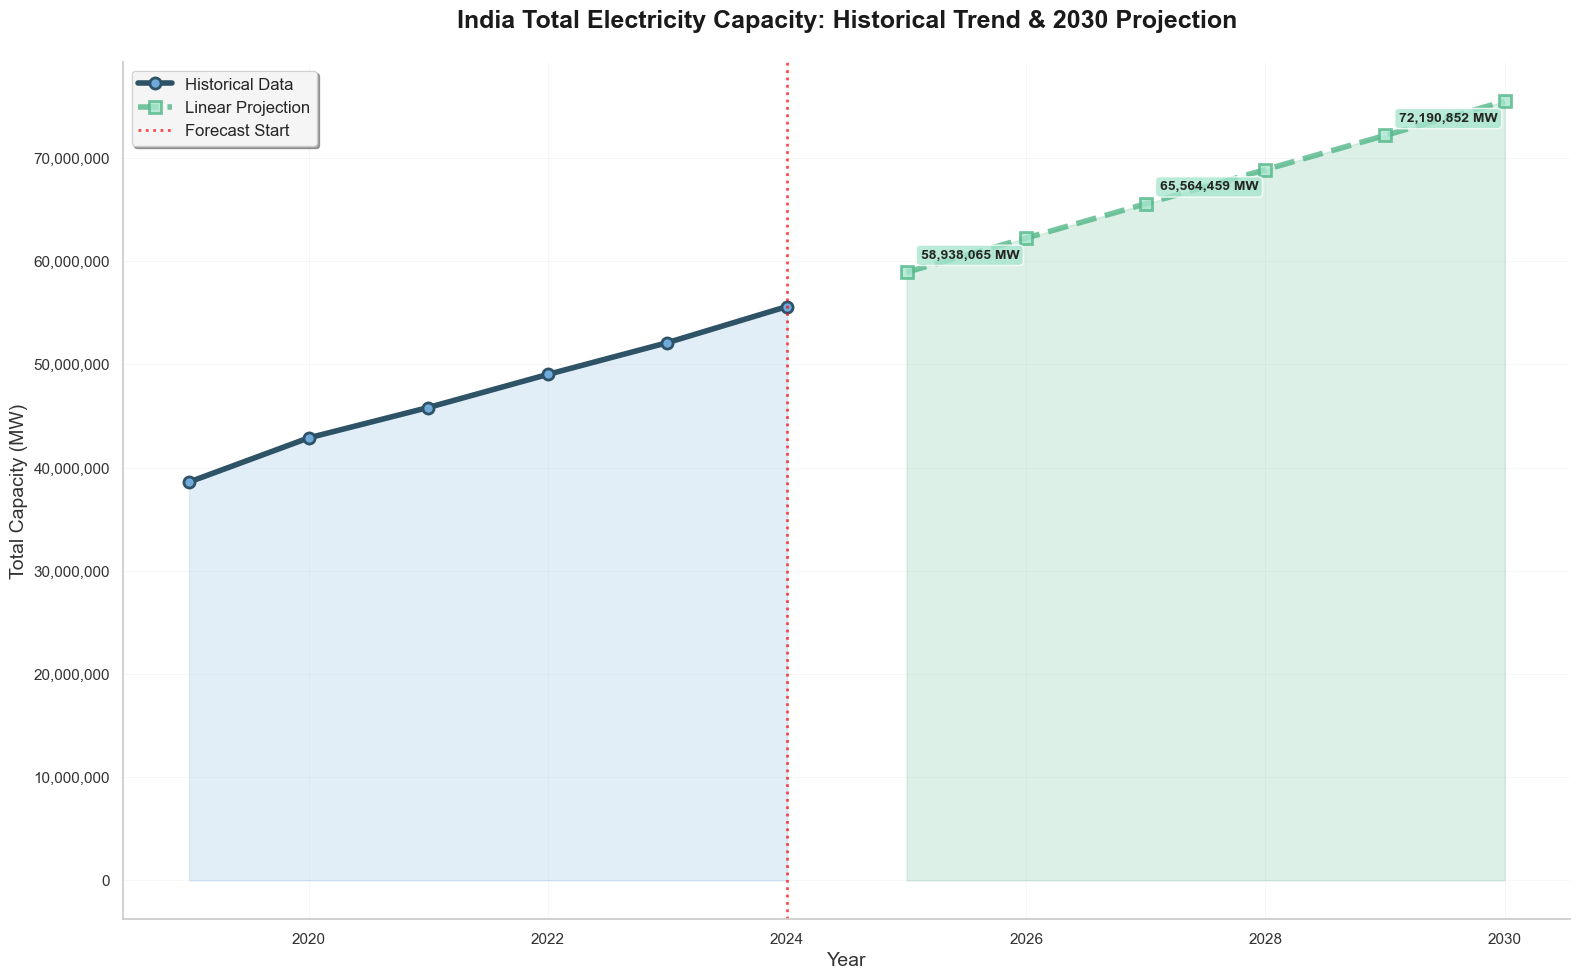

In [44]:
plt.figure(figsize=(16, 10))

plt.plot(annual_data['Year'], annual_data['Value'], 
         marker='o', linewidth=4, markersize=8, color='#2E5266', 
         label='Historical Data', markerfacecolor='#6FAADB', 
         markeredgecolor='#2E5266', markeredgewidth=2)

plt.plot(forecast_years, forecasted_capacity, 
         marker='s', linewidth=4, markersize=8, color='#52B788', 
         label='Linear Projection', linestyle='--', alpha=0.8,
         markerfacecolor='#A8E6CF', markeredgecolor='#52B788', markeredgewidth=2)

plt.fill_between(annual_data['Year'], annual_data['Value'], alpha=0.2, color='#6FAADB')
plt.fill_between(forecast_years, forecasted_capacity, alpha=0.2, color='#52B788')

plt.axvline(x=annual_data['Year'].iloc[-1], color='red', linestyle=':', 
           alpha=0.7, linewidth=2, label='Forecast Start')

for i, (year, capacity) in enumerate(zip(forecast_years, forecasted_capacity)):
    if i % 2 == 0:
        plt.annotate(f'{capacity:,.0f} MW', 
                    xy=(year, capacity), xytext=(10, 10),
                    textcoords='offset points', fontsize=10, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='#A8E6CF', alpha=0.8))

plt.title('India Total Electricity Capacity: Historical Trend & 2030 Projection', 
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')
plt.xlabel('Year', fontsize=14, color='#333333')
plt.ylabel('Total Capacity (MW)', fontsize=14, color='#333333')

legend = plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [45]:
renewable_data = df[df['EnergyType'] == 'Renewable'].groupby('Year')['Value'].sum().reset_index()
fossil_data = df[df['EnergyType'] == 'Fossil'].groupby('Year')['Value'].sum().reset_index()

recent_renewable = renewable_data.tail(8)
recent_fossil = fossil_data.tail(8)

X_years = recent_renewable['Year'].values.reshape(-1, 1)
renewable_model = LinearRegression().fit(X_years, recent_renewable['Value'].values)
fossil_model = LinearRegression().fit(X_years, recent_fossil['Value'].values)

forecast_X = np.array(forecast_years).reshape(-1, 1)
renewable_forecast = renewable_model.predict(forecast_X)
fossil_forecast = fossil_model.predict(forecast_X)

total_forecast_2030 = renewable_forecast[-1] + fossil_forecast[-1]
renewable_share_2030 = (renewable_forecast[-1] / total_forecast_2030) * 100

print(f"Energy Mix Projections for 2030:")
print(f"Projected renewable capacity: {renewable_forecast[-1]:,.0f} MW")
print(f"Projected fossil capacity: {fossil_forecast[-1]:,.0f} MW")
print(f"Renewable share in 2030: {renewable_share_2030:.1f}%")

Energy Mix Projections for 2030:
Projected renewable capacity: 18,701,744 MW
Projected fossil capacity: 33,950,410 MW
Renewable share in 2030: 35.5%


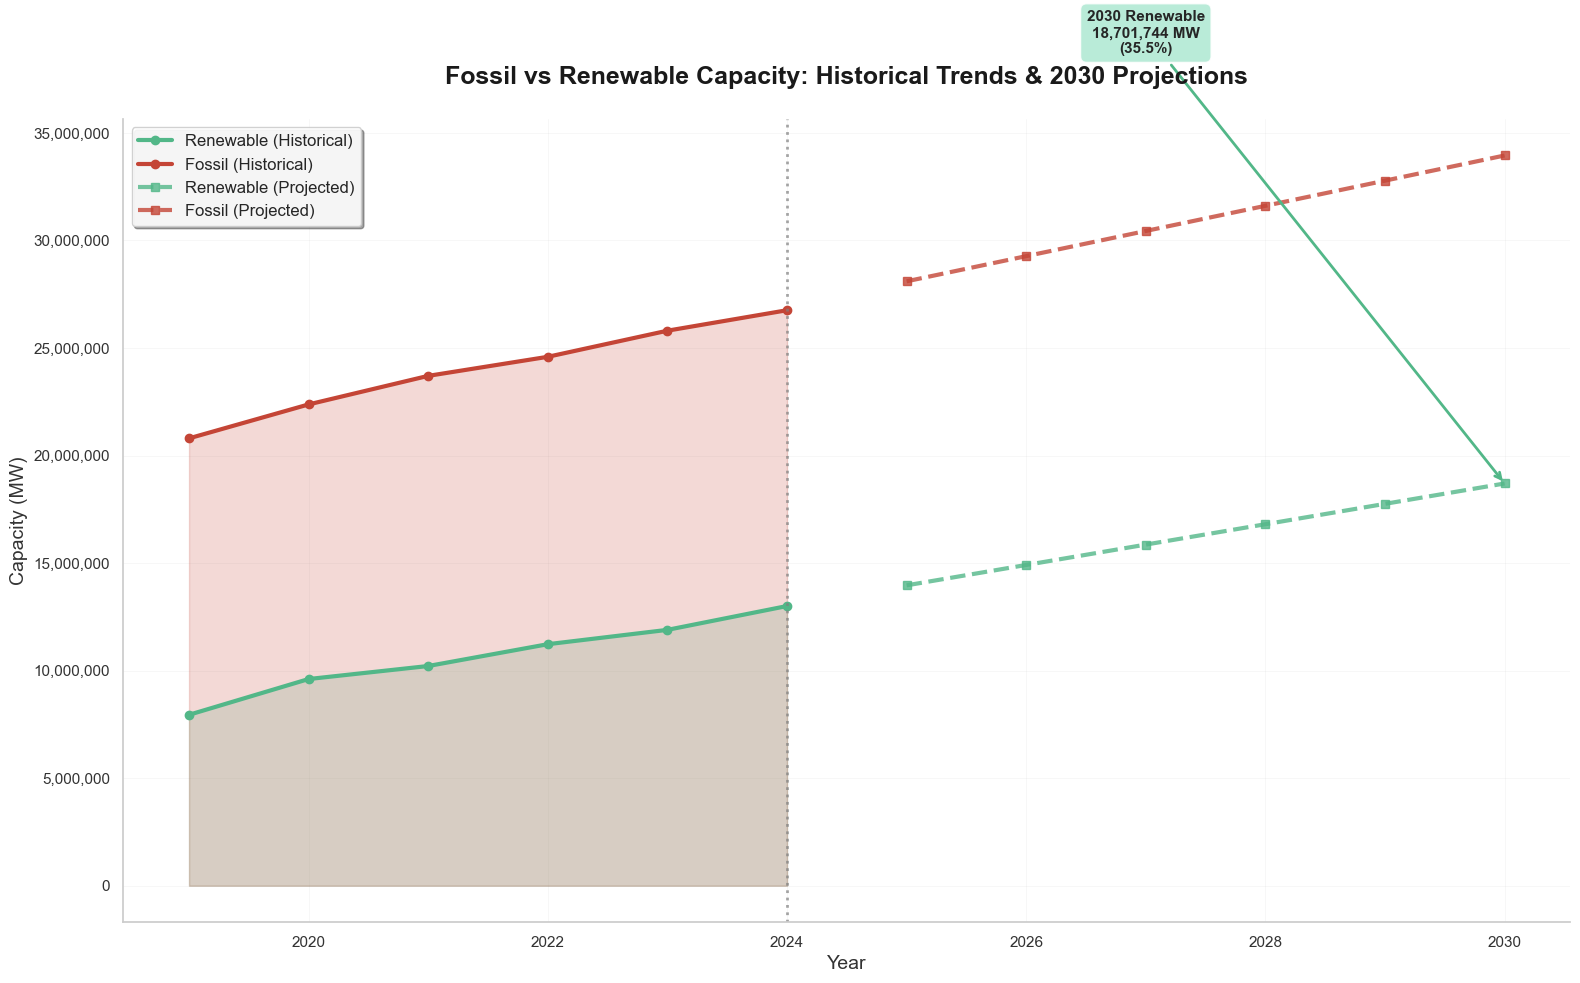

In [46]:
plt.figure(figsize=(16, 10))

plt.plot(renewable_data['Year'], renewable_data['Value'], 
         marker='o', linewidth=3, markersize=6, color='#52B788', 
         label='Renewable (Historical)')
plt.plot(fossil_data['Year'], fossil_data['Value'], 
         marker='o', linewidth=3, markersize=6, color='#C44536', 
         label='Fossil (Historical)')

plt.plot(forecast_years, renewable_forecast, 
         marker='s', linewidth=3, markersize=6, color='#52B788', 
         linestyle='--', alpha=0.8, label='Renewable (Projected)')
plt.plot(forecast_years, fossil_forecast, 
         marker='s', linewidth=3, markersize=6, color='#C44536', 
         linestyle='--', alpha=0.8, label='Fossil (Projected)')

plt.fill_between(renewable_data['Year'], renewable_data['Value'], 
                 alpha=0.2, color='#52B788')
plt.fill_between(fossil_data['Year'], fossil_data['Value'], 
                 alpha=0.2, color='#C44536')

plt.axvline(x=renewable_data['Year'].iloc[-1], color='gray', linestyle=':', 
           alpha=0.7, linewidth=2)

plt.annotate(f'2030 Renewable\n{renewable_forecast[-1]:,.0f} MW\n({renewable_share_2030:.1f}%)', 
            xy=(2030, renewable_forecast[-1]), xytext=(2027, renewable_forecast[-1] + 20000000),
            arrowprops=dict(arrowstyle='->', color='#52B788', lw=2),
            fontsize=11, ha='center', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.4", facecolor='#A8E6CF', alpha=0.8))

plt.title('Fossil vs Renewable Capacity: Historical Trends & 2030 Projections', 
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')
plt.xlabel('Year', fontsize=14, color='#333333')
plt.ylabel('Capacity (MW)', fontsize=14, color='#333333')

legend = plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [47]:
renewable_fuels = ['Solar', 'Wind', 'Hydro']
fuel_forecasts = {}

for fuel in renewable_fuels:
    fuel_data = df[df['Variable'] == fuel].groupby('Year')['Value'].sum().reset_index()
    if len(fuel_data) >= 5:
        recent_fuel = fuel_data.tail(8)
        X_fuel = recent_fuel['Year'].values.reshape(-1, 1)
        fuel_model = LinearRegression().fit(X_fuel, recent_fuel['Value'].values)
        fuel_forecast = fuel_model.predict(forecast_X)
        fuel_forecasts[fuel] = {
            'historical': fuel_data,
            'forecast': fuel_forecast,
            'growth_rate': fuel_model.coef_[0]
        }

print(f" Individual Renewable Technology Projections (2030):")
for fuel, data in fuel_forecasts.items():
    current_capacity = data['historical']['Value'].iloc[-1]
    projected_2030 = data['forecast'][-1]
    growth = ((projected_2030 / current_capacity) - 1) * 100
    print(f"{fuel}: {projected_2030:,.0f} MW ({growth:+.1f}% growth)")

 Individual Renewable Technology Projections (2030):
Solar: 4,235,070 MW (+79.1% growth)
Wind: 1,758,621 MW (+36.5% growth)
Hydro: 1,843,027 MW (+16.1% growth)


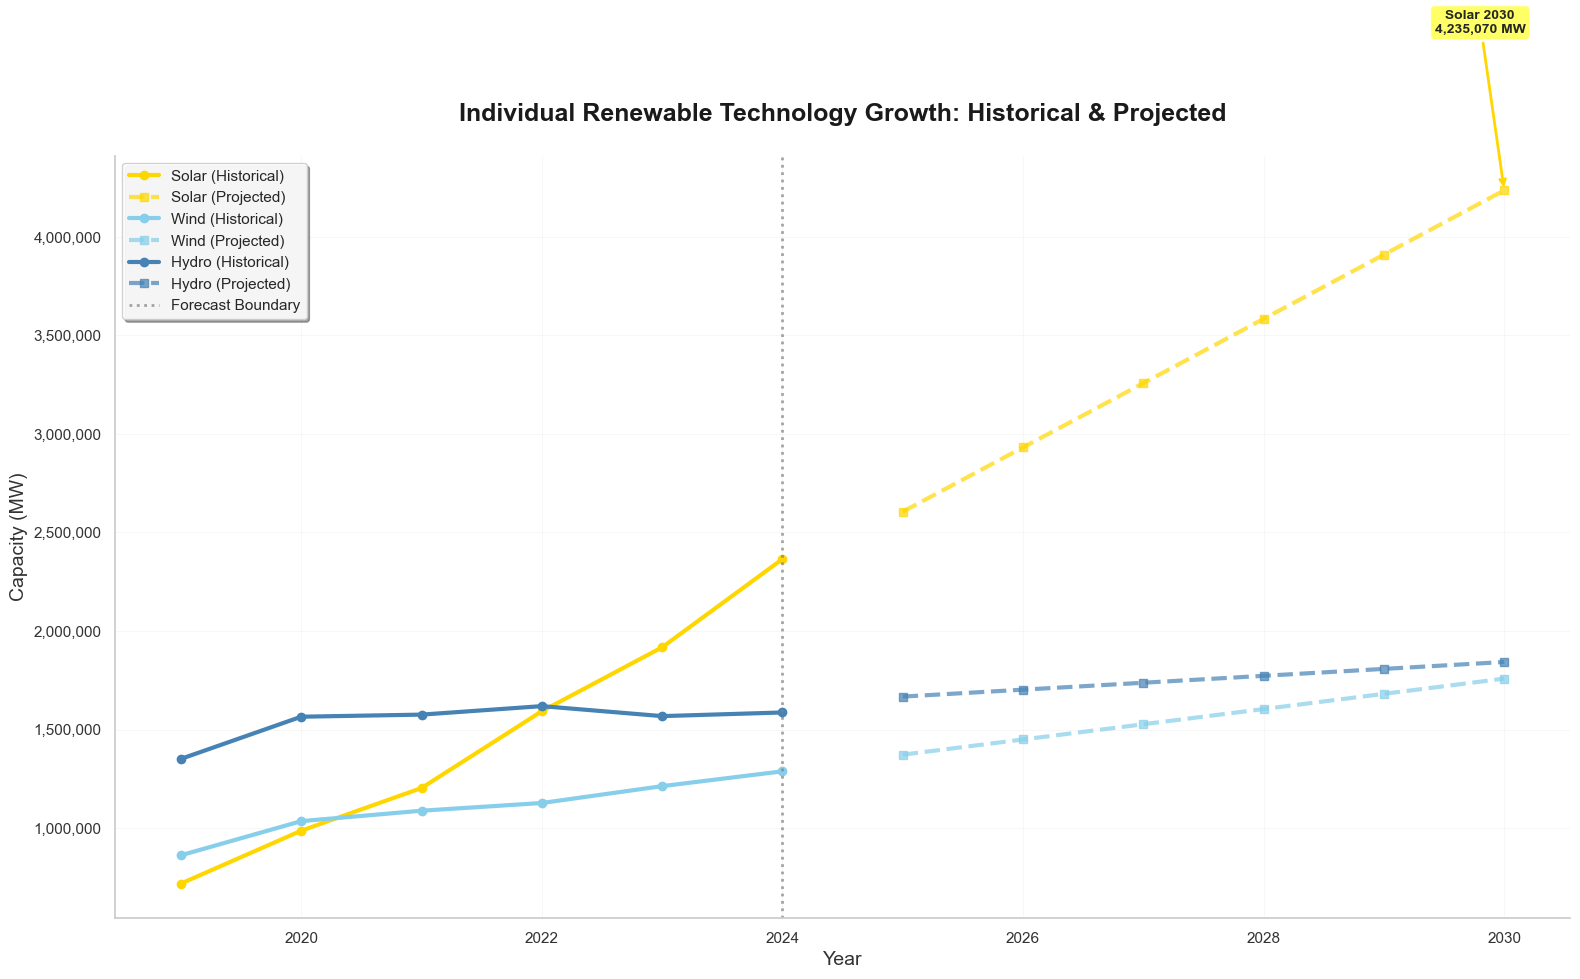

In [48]:
plt.figure(figsize=(16, 10))

fuel_colors = {'Solar': '#FFD700', 'Wind': '#87CEEB', 'Hydro': '#4682B4'}

for fuel, data in fuel_forecasts.items():
    historical = data['historical']
    forecast = data['forecast']
    color = fuel_colors[fuel]
    
    plt.plot(historical['Year'], historical['Value'], 
             marker='o', linewidth=3, markersize=6, color=color, 
             label=f'{fuel} (Historical)')
    
    plt.plot(forecast_years, forecast, 
             marker='s', linewidth=3, markersize=6, color=color, 
             linestyle='--', alpha=0.7, label=f'{fuel} (Projected)')

plt.axvline(x=df['Year'].max(), color='gray', linestyle=':', 
           alpha=0.7, linewidth=2, label='Forecast Boundary')

for fuel, data in fuel_forecasts.items():
    if fuel == 'Solar':
        plt.annotate(f'{fuel} 2030\n{data["forecast"][-1]:,.0f} MW', 
                    xy=(2030, data['forecast'][-1]), 
                    xytext=(2029.8, data['forecast'][-1] + 800000),
                    arrowprops=dict(arrowstyle='->', color=fuel_colors[fuel], lw=2),
                    fontsize=10, ha='center', fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='yellow', alpha=0.6))

plt.title('Individual Renewable Technology Growth: Historical & Projected', 
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')
plt.xlabel('Year', fontsize=14, color='#333333')
plt.ylabel('Capacity (MW)', fontsize=14, color='#333333')

legend = plt.legend(fontsize=11, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')

ax = plt.gca()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')
ax.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

In [49]:
milestones_data = []
current_renewable_share = (renewable_data['Value'].iloc[-1] / 
                          (renewable_data['Value'].iloc[-1] + fossil_data['Value'].iloc[-1])) * 100

for i, year in enumerate(forecast_years):
    total_capacity = renewable_forecast[i] + fossil_forecast[i]
    renewable_share = (renewable_forecast[i] / total_capacity) * 100
    
    milestones_data.append({
        'Year': year,
        'Total_Capacity': total_capacity,
        'Renewable_Share': renewable_share,
        'Renewable_Capacity': renewable_forecast[i],
        'Fossil_Capacity': fossil_forecast[i]
    })

milestones_df = pd.DataFrame(milestones_data)

milestone_years = []
if any(milestones_df['Renewable_Share'] >= 30):
    milestone_30 = milestones_df[milestones_df['Renewable_Share'] >= 30].iloc[0]
    milestone_years.append(('30% Renewable', milestone_30['Year']))
if any(milestones_df['Renewable_Share'] >= 40):
    milestone_40 = milestones_df[milestones_df['Renewable_Share'] >= 40].iloc[0]
    milestone_years.append(('40% Renewable', milestone_40['Year']))

print(f"Projected Milestone Achievements:")
print(f"Current renewable share: {current_renewable_share:.1f}%")
for milestone, year in milestone_years:
    print(f"{milestone} target: {year}")
if not milestone_years:
    print("30% and 40% targets not reached by 2030 under current trends")

Projected Milestone Achievements:
Current renewable share: 32.7%
30% Renewable target: 2025.0


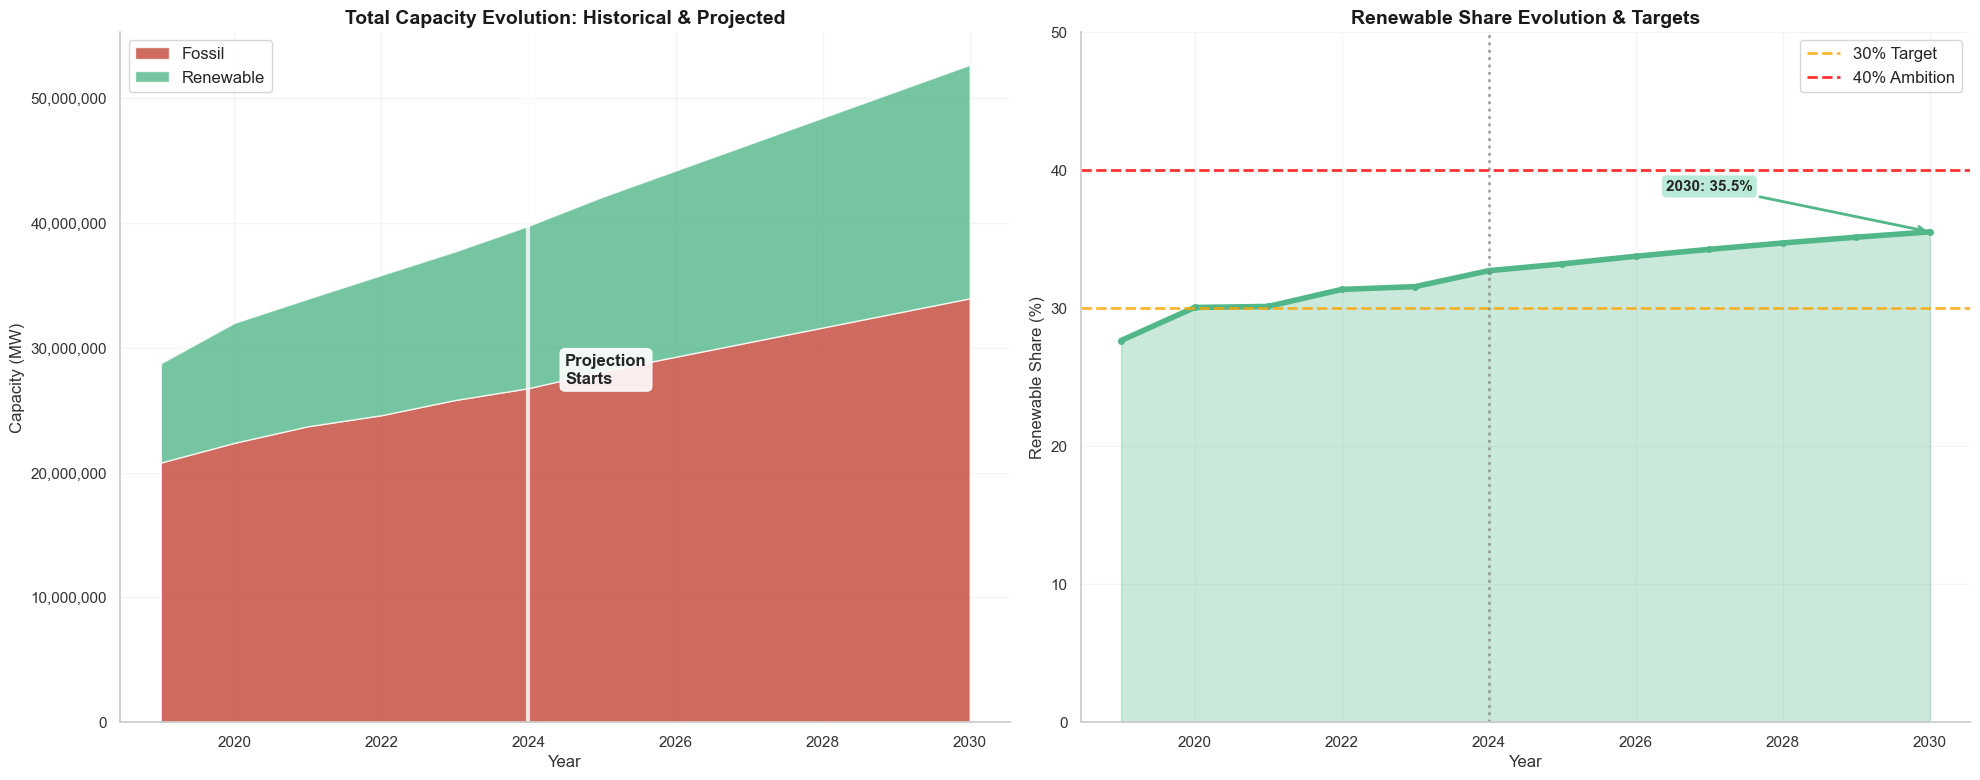

In [50]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

years_extended = list(renewable_data['Year']) + forecast_years
renewable_extended = list(renewable_data['Value']) + list(renewable_forecast)
fossil_extended = list(fossil_data['Value']) + list(fossil_forecast)

ax1.stackplot(years_extended, fossil_extended, renewable_extended,
             labels=['Fossil', 'Renewable'], 
             colors=['#C44536', '#52B788'], alpha=0.8)

ax1.axvline(x=df['Year'].max(), color='white', linestyle='-', 
           linewidth=3, alpha=0.8)
ax1.text(df['Year'].max() + 0.5, max(renewable_extended + fossil_extended) * 0.8, 
         'Projection\nStarts', fontsize=12, fontweight='bold', 
         bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.9))

ax1.set_title('Total Capacity Evolution: Historical & Projected', 
              fontsize=14, fontweight='bold', color='#1a1a1a')
ax1.set_xlabel('Year', fontsize=12, color='#333333')
ax1.set_ylabel('Capacity (MW)', fontsize=12, color='#333333')
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.2)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))

renewable_share_extended = [(r / (r + f)) * 100 for r, f in zip(renewable_extended, fossil_extended)]
ax2.plot(years_extended, renewable_share_extended, 
         linewidth=4, color='#52B788', marker='o', markersize=4)

ax2.fill_between(years_extended, renewable_share_extended, 
                alpha=0.3, color='#52B788')

ax2.axhline(y=30, color='orange', linestyle='--', alpha=0.8, linewidth=2, label='30% Target')
ax2.axhline(y=40, color='red', linestyle='--', alpha=0.8, linewidth=2, label='40% Ambition')
ax2.axvline(x=df['Year'].max(), color='gray', linestyle=':', alpha=0.7, linewidth=2)

ax2.annotate(f'2030: {renewable_share_extended[-1]:.1f}%', 
            xy=(2030, renewable_share_extended[-1]), 
            xytext=(2027, renewable_share_extended[-1] + 3),
            arrowprops=dict(arrowstyle='->', color='#52B788', lw=2),
            fontsize=11, ha='center', fontweight='bold',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='#A8E6CF', alpha=0.8))

ax2.set_title('Renewable Share Evolution & Targets', 
              fontsize=14, fontweight='bold', color='#1a1a1a')
ax2.set_xlabel('Year', fontsize=12, color='#333333')
ax2.set_ylabel('Renewable Share (%)', fontsize=12, color='#333333')
ax2.legend(fontsize=12)
ax2.grid(True, alpha=0.2)
ax2.set_ylim(0, 50)

for ax in [ax1, ax2]:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()

# Section 7: Key Insights & Strategic Recommendations

### Key Questions
- What are the most critical insights from India's electricity capacity analysis?
- How does India's transition pace compare to policy targets and global standards?
- What are the primary challenges hindering faster renewable adoption?
- Which strategic interventions would have the highest impact on transition success?

### Analysis Focus
- Transition pace assessment and policy milestone evaluation
- Regional leadership patterns and successful state models
- Challenge identification across technical, financial, and policy dimensions
- Strategic recommendations with investment priorities and timelines


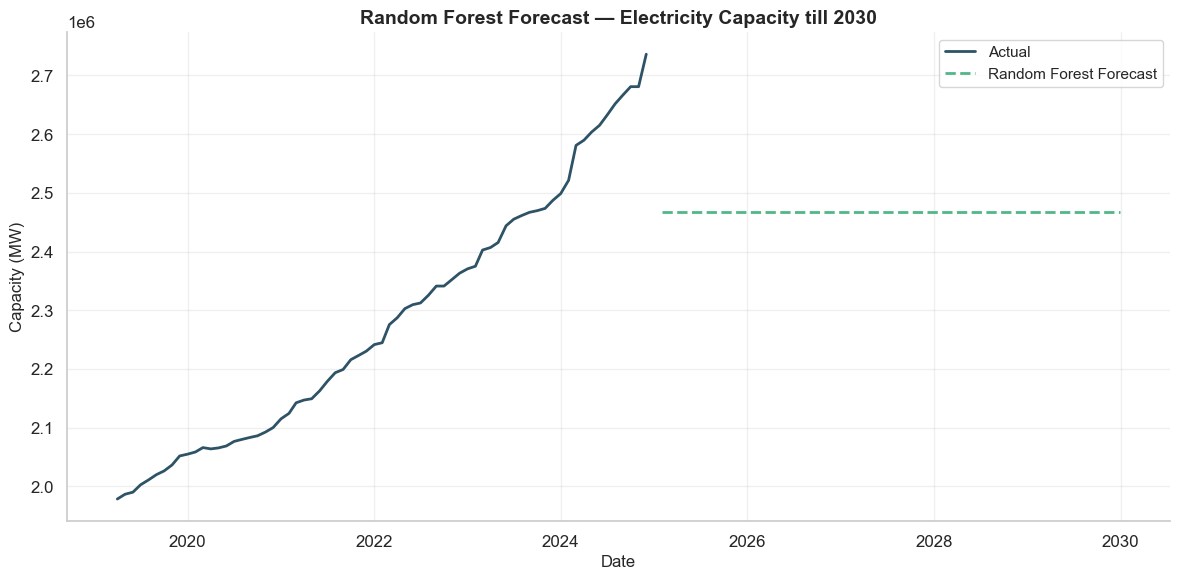


Random Forest Capacity Forecasting:
Model Type        : Machine Learning (Ensemble)
Trend Insight     : Captures nonlinear relationships via lag features
Projected 2030    : 2,468,132 MW
Growth from last  : -9.8%


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor

df_s7 = pd.read_csv('india_monthly_electricity_(2019-2024).csv')
df_s7.columns = df_s7.columns.str.strip()
df_s7['Date'] = pd.to_datetime(df_s7['Date'], errors='coerce')

df_cap = df_s7[df_s7['Category'] == 'Capacity']
df_total = df_cap.groupby('Date')['Value'].sum().reset_index().sort_values('Date').reset_index(drop=True)

df_total['lag1'] = df_total['Value'].shift(1)
df_total['lag2'] = df_total['Value'].shift(2)
df_total['lag3'] = df_total['Value'].shift(3)
df_total.dropna(inplace=True)

X = df_total[['lag1', 'lag2', 'lag3']]
y = df_total['Value']

split = int(len(X) * 0.8)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_test_preds = rf_model.predict(X_test)

# Future forecast (60 months - 2030)
future_steps = 60
last_vals = list(df_total['Value'].values[-3:])
rf_future_preds = []
for _ in range(future_steps):
    X_in = np.array(last_vals[-3:]).reshape(1, -1)
    pred = rf_model.predict(X_in)[0]
    rf_future_preds.append(pred)
    last_vals.append(pred)

rf_future_dates = pd.date_range(start=df_total['Date'].iloc[-1], periods=future_steps + 1, freq='ME')[1:]

plt.figure(figsize=(12, 6))
plt.plot(df_total['Date'], df_total['Value'], label='Actual', linewidth=2, color='#2E5266')
plt.plot(rf_future_dates, rf_future_preds, label='Random Forest Forecast',
         linewidth=2, color='#52B788', linestyle='--')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Capacity (MW)', fontsize=12)
plt.title('Random Forest Forecast — Electricity Capacity till 2030', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nRandom Forest Capacity Forecasting:")
print(f"Model Type        : Machine Learning (Ensemble)")
print(f"Trend Insight     : Captures nonlinear relationships via lag features")
print(f"Projected 2030    : {rf_future_preds[-1]:,.0f} MW")
print(f"Growth from last  : {((rf_future_preds[-1] / df_total['Value'].iloc[-1]) - 1) * 100:.1f}%")


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 12, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 50)                  │          20,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │              51 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 30,651 (119.73 KB)

 Trainable params: 30,651 (119.73 KB)

 Non-trainable params: 0 (0.00 B)

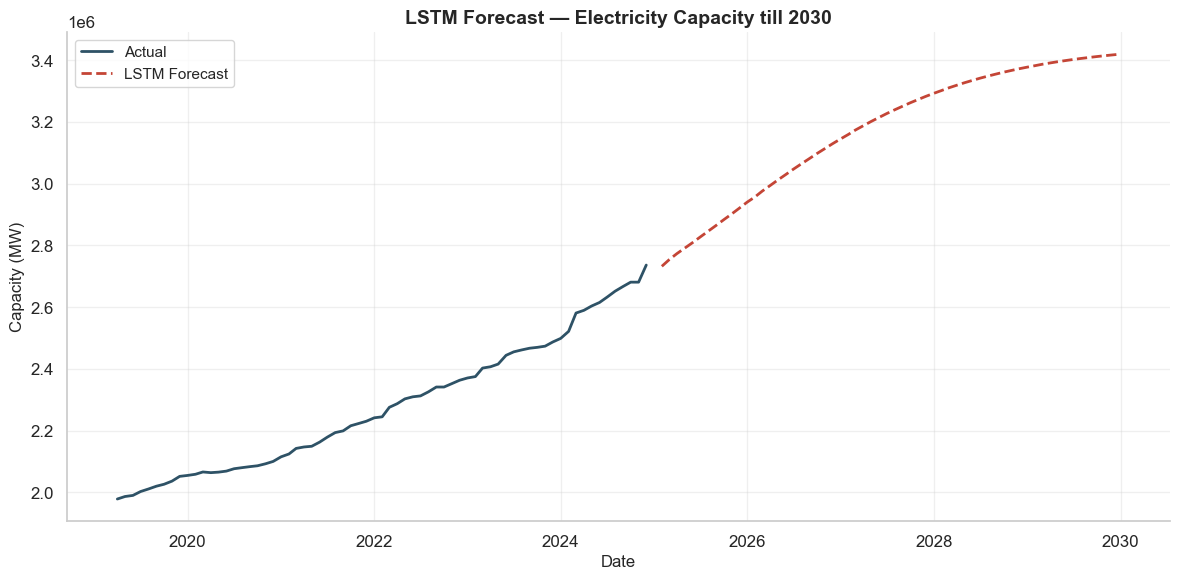


LSTM Capacity Forecasting:
Model Type        : Deep Learning (Recurrent Neural Network)
Trend Insight     : Captures long-term sequential dependencies
Projected 2030    : 3,419,550 MW
Growth from last  : 25.0%


In [76]:
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import warnings
warnings.filterwarnings('ignore')

data_raw = df_total['Value'].values.reshape(-1, 1)
scaler_lstm = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler_lstm.fit_transform(data_raw)

TIME_STEPS = 12

def create_sequences(data, time_steps):
    X_seq, y_seq = [], []
    for i in range(len(data) - time_steps):
        X_seq.append(data[i:i + time_steps])
        y_seq.append(data[i + time_steps])
    return np.array(X_seq), np.array(y_seq)

X_lstm, y_lstm = create_sequences(scaled_data, TIME_STEPS)

split_lstm = int(len(X_lstm) * 0.8)
X_tr_l, X_te_l = X_lstm[:split_lstm], X_lstm[split_lstm:]
y_tr_l, y_te_l = y_lstm[:split_lstm], y_lstm[split_lstm:]

lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(TIME_STEPS, 1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.summary()

history_lstm = lstm_model.fit(X_tr_l, y_tr_l, epochs=25, batch_size=16,
                               validation_data=(X_te_l, y_te_l), verbose=0)

# Future forecast
future_steps = 60
last_seq = scaled_data[-TIME_STEPS:]
lstm_future_preds_scaled = []
for _ in range(future_steps):
    pred = lstm_model.predict(last_seq.reshape(1, TIME_STEPS, 1), verbose=0)
    lstm_future_preds_scaled.append(pred[0][0])
    last_seq = np.append(last_seq[1:], pred, axis=0)

lstm_future_preds = scaler_lstm.inverse_transform(
    np.array(lstm_future_preds_scaled).reshape(-1, 1)
).flatten()

lstm_future_dates = pd.date_range(start=df_total['Date'].iloc[-1], periods=future_steps + 1, freq='ME')[1:]

plt.figure(figsize=(12, 6))
plt.plot(df_total['Date'], data_raw, label='Actual', linewidth=2, color='#2E5266')
plt.plot(lstm_future_dates, lstm_future_preds, label='LSTM Forecast',
         linewidth=2, color='#C44536', linestyle='--')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Capacity (MW)', fontsize=12)
plt.title('LSTM Forecast — Electricity Capacity till 2030', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nLSTM Capacity Forecasting:")
print(f"Model Type        : Deep Learning (Recurrent Neural Network)")
print(f"Trend Insight     : Captures long-term sequential dependencies")
print(f"Projected 2030    : {lstm_future_preds[-1]:,.0f} MW")
print(f"Growth from last  : {((lstm_future_preds[-1] / df_total['Value'].iloc[-1]) - 1) * 100:.1f}%")


C:\ProgramData\anaconda3\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


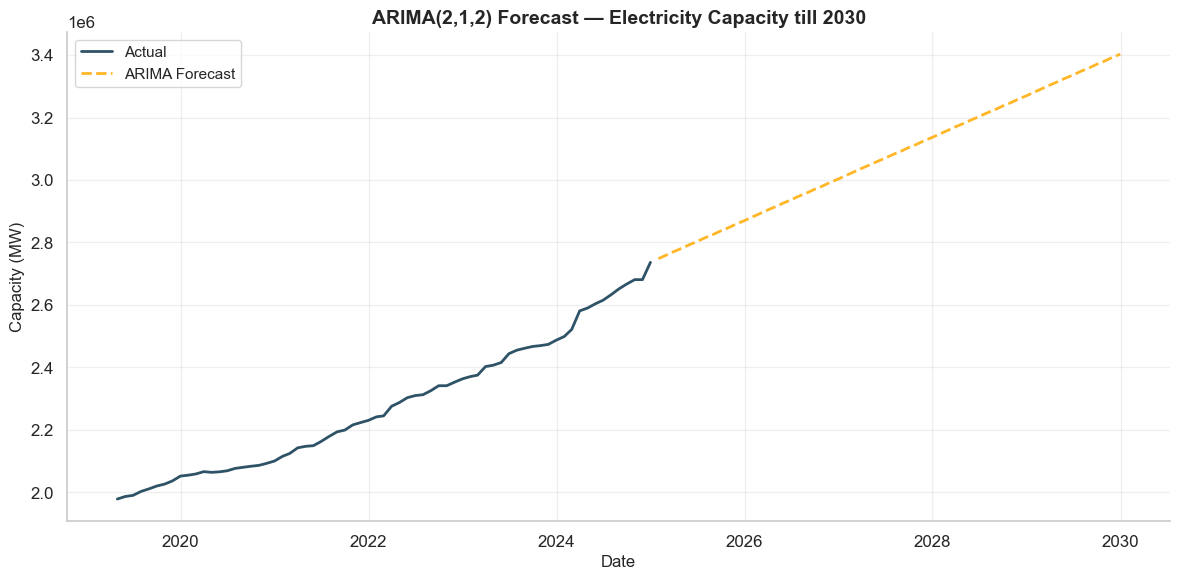


ARIMA Capacity Forecasting:
Model Type        : Statistical Time-Series (ARIMA)
Order             : (2, 1, 2)
Projected 2030    : 3,402,954 MW


In [73]:
from statsmodels.tsa.arima.model import ARIMA

df_arima = df_total.set_index('Date')[['Value']].resample('ME').mean().ffill()

arima_model = ARIMA(df_arima['Value'], order=(2, 1, 2))
arima_fit = arima_model.fit()

future_steps = 60
arima_forecast = arima_fit.forecast(steps=future_steps)
arima_future_dates = pd.date_range(start=df_arima.index[-1], periods=future_steps + 1, freq='ME')[1:]
arima_forecast.index = arima_future_dates

plt.figure(figsize=(12, 6))
plt.plot(df_arima.index, df_arima['Value'], label='Actual', linewidth=2, color='#2E5266')
plt.plot(arima_future_dates, arima_forecast.values, label='ARIMA Forecast',
         linewidth=2, color='#FFB627', linestyle='--')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Capacity (MW)', fontsize=12)
plt.title('ARIMA(2,1,2) Forecast — Electricity Capacity till 2030', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nARIMA Capacity Forecasting:")
print(f"Model Type        : Statistical Time-Series (ARIMA)")
print(f"Order             : (2, 1, 2)")
print(f"Projected 2030    : {arima_forecast.iloc[-1]:,.0f} MW")


                                     SARIMAX Results                                      
Dep. Variable:                              Value   No. Observations:                   69
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 12)   Log Likelihood                -451.298
Date:                            Thu, 30 Apr 2026   AIC                            912.597
Time:                                    00:20:31   BIC                            921.285
Sample:                                04-30-2019   HQIC                           915.781
                                     - 12-31-2024                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.2083      1.183      0.176      0.860      -2.111       2.527
ma.L1         -0.0827      1.152   

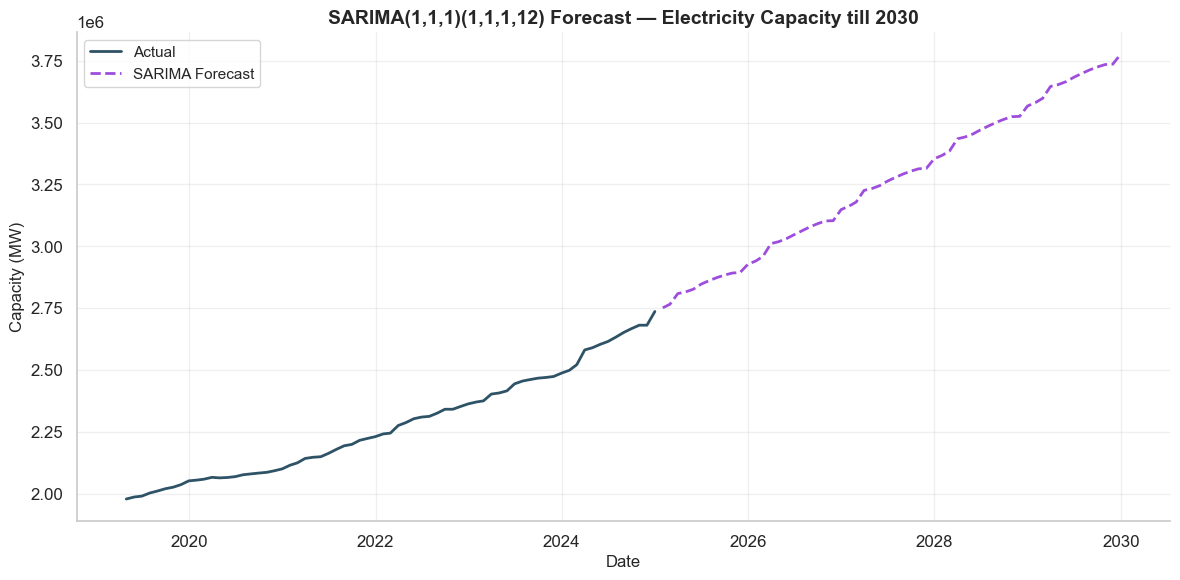


SARIMA Capacity Forecasting:
Model Type        : Seasonal Statistical Time-Series (SARIMA)
Order             : (1,1,1)(1,1,1,12)
Projected 2030    : 3,776,376 MW


In [74]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    df_arima['Value'],
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 12),
    enforce_stationarity=False,
    enforce_invertibility=False
)
sarima_fit = sarima_model.fit(disp=False)
print(sarima_fit.summary())

future_steps = 60
sarima_forecast = sarima_fit.forecast(steps=future_steps)
sarima_future_dates = pd.date_range(start=df_arima.index[-1], periods=future_steps + 1, freq='ME')[1:]
sarima_forecast.index = sarima_future_dates

plt.figure(figsize=(12, 6))
plt.plot(df_arima.index, df_arima['Value'], label='Actual', linewidth=2, color='#2E5266')
plt.plot(sarima_future_dates, sarima_forecast.values, label='SARIMA Forecast',
         linewidth=2, color='#9D4EDD', linestyle='--')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Capacity (MW)', fontsize=12)
plt.title('SARIMA(1,1,1)(1,1,1,12) Forecast — Electricity Capacity till 2030',
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\nSARIMA Capacity Forecasting:")
print(f"Model Type        : Seasonal Statistical Time-Series (SARIMA)")
print(f"Order             : (1,1,1)(1,1,1,12)")
print(f"Projected 2030    : {sarima_forecast.iloc[-1]:,.0f} MW")


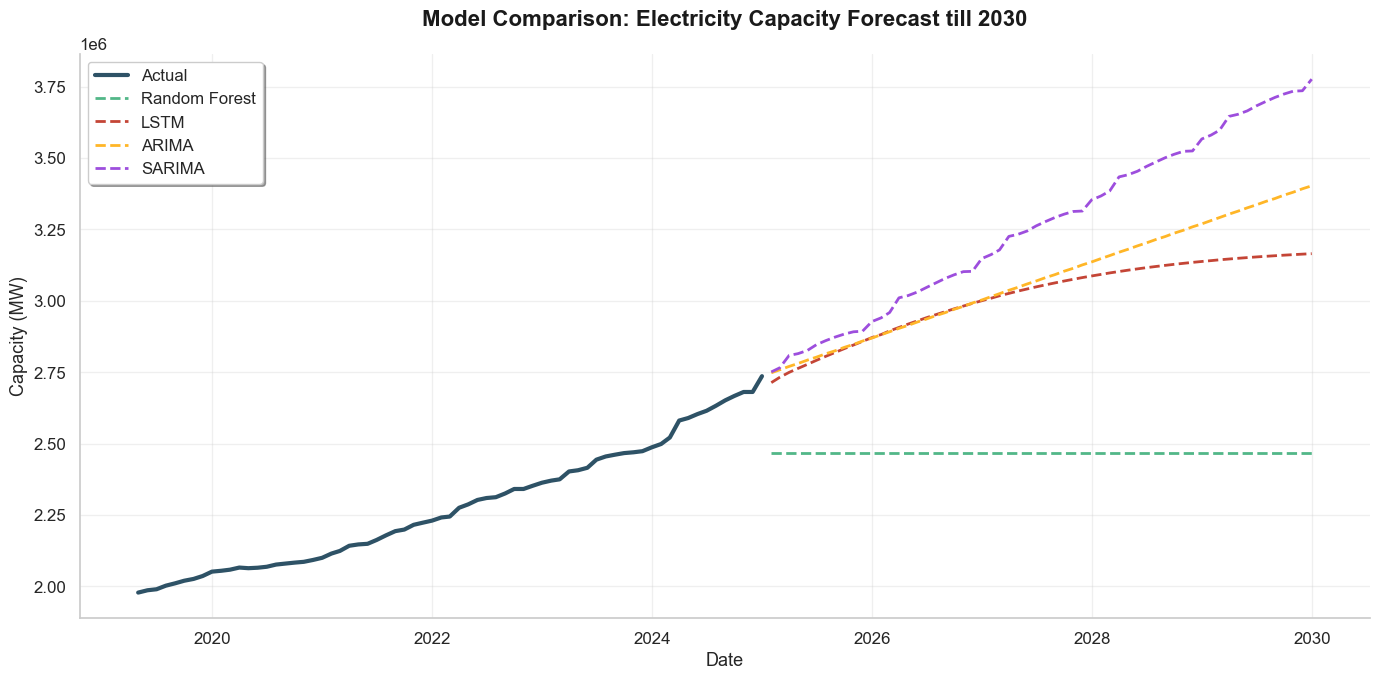


Model Comparison — 2030 Forecast:
  Random Forest :    2,468,132 MW
  LSTM          :    3,165,280 MW
  ARIMA         :    3,402,954 MW
  SARIMA        :    3,776,376 MW


In [72]:
# All 4 model forecasts aligned on the same future date range
common_dates = sarima_future_dates 

rf_preds_plot    = np.array(rf_future_preds)[:len(common_dates)]
lstm_preds_plot  = lstm_future_preds[:len(common_dates)]
arima_preds_plot = arima_forecast.values[:len(common_dates)]
sarima_preds_plot= sarima_forecast.values[:len(common_dates)]

plt.figure(figsize=(14, 7))
plt.plot(df_arima.index, df_arima['Value'], label='Actual',
         linewidth=3, color='#2E5266')
plt.plot(common_dates, rf_preds_plot,    label='Random Forest', linewidth=2, linestyle='--', color='#52B788')
plt.plot(common_dates, lstm_preds_plot,  label='LSTM',          linewidth=2, linestyle='--', color='#C44536')
plt.plot(common_dates, arima_preds_plot, label='ARIMA',         linewidth=2, linestyle='--', color='#FFB627')
plt.plot(common_dates, sarima_preds_plot,label='SARIMA',        linewidth=2, linestyle='--', color='#9D4EDD')

plt.title('Model Comparison: Electricity Capacity Forecast till 2030',
          fontsize=16, fontweight='bold', pad=20, color='#1a1a1a')
plt.xlabel('Date', fontsize=13)
plt.ylabel('Capacity (MW)', fontsize=13)
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True)
plt.grid(True, alpha=0.3)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print("\nModel Comparison — 2030 Forecast:")
print(f"  Random Forest : {rf_preds_plot[-1]:>12,.0f} MW")
print(f"  LSTM          : {lstm_preds_plot[-1]:>12,.0f} MW")
print(f"  ARIMA         : {arima_preds_plot[-1]:>12,.0f} MW")
print(f"  SARIMA        : {sarima_preds_plot[-1]:>12,.0f} MW")

forecasted_capacity = sarima_preds_plot


In [56]:
print("Dataset columns:")
print(df_s7.columns.tolist())
print("\nEnergyType unique values (from Section 1 classification):")
print(df['EnergyType'].unique())


Dataset columns:
['Country', 'Country code', 'State', 'State code', 'State type', 'Date', 'Category', 'Subcategory', 'Variable', 'Unit', 'Value', 'YoY absolute change', 'YoY % change']

EnergyType unique values (from Section 1 classification):
['Other' 'Fossil' 'Renewable']


In [71]:
transition_summary = df.groupby(['Year', 'EnergyType'])['Value'].sum().reset_index()

transition_pivot = transition_summary.pivot(
    index='Year',
    columns='EnergyType',
    values='Value'
).fillna(0)

for col in ['Fossil', 'Renewable', 'Other']:
    if col not in transition_pivot.columns:
        transition_pivot[col] = 0

transition_pivot['Total']          = transition_pivot.sum(axis=1)
transition_pivot['Renewable_Share'] = (transition_pivot['Renewable'] / transition_pivot['Total']) * 100

current_year   = transition_pivot.index[-1]
baseline_year  = 2019

current_share  = transition_pivot.loc[current_year, 'Renewable_Share']
baseline_share = (transition_pivot.loc[baseline_year, 'Renewable_Share']
                  if baseline_year in transition_pivot.index else 0)

total_growth    = ((transition_pivot.loc[current_year, 'Total'] /
                    transition_pivot.iloc[0]['Total']) - 1) * 100
renewable_growth = ((transition_pivot.loc[current_year, 'Renewable'] /
                     transition_pivot.iloc[0]['Renewable']) - 1) * 100

print("Energy Transition Summary:")
print(f"  Current renewable share      : {current_share:.1f}%")
print(f"  Share growth since {baseline_year}    : +{current_share - baseline_share:.1f} percentage points")
print(f"  Total capacity growth        : {total_growth:.0f}%")
print(f"  Renewable capacity growth    : {renewable_growth:.0f}%")


Energy Transition Summary:
  Current renewable share      : 23.4%
  Share growth since 2019    : +2.8 percentage points
  Total capacity growth        : 44%
  Renewable capacity growth    : 64%


In [70]:
# summary with additional stats
print(f"Energy Transition Summary (Extended):")
print(f"  Current renewable share : {current_share:.1f}%")
print(f"  Total capacity growth   : {total_growth:.0f}%")
print(f"  Renewable capacity growth: {renewable_growth:.0f}%")
print(f"\nYearly Renewable Share:")
for yr, row in transition_pivot.iterrows():
    print(f"  {yr}: {row['Renewable_Share']:.1f}%")


Energy Transition Summary (Extended):
  Current renewable share : 23.4%
  Total capacity growth   : 44%
  Renewable capacity growth: 64%

Yearly Renewable Share:
  2019: 20.6%
  2020: 22.4%
  2021: 22.3%
  2022: 22.9%
  2023: 22.8%
  2024: 23.4%


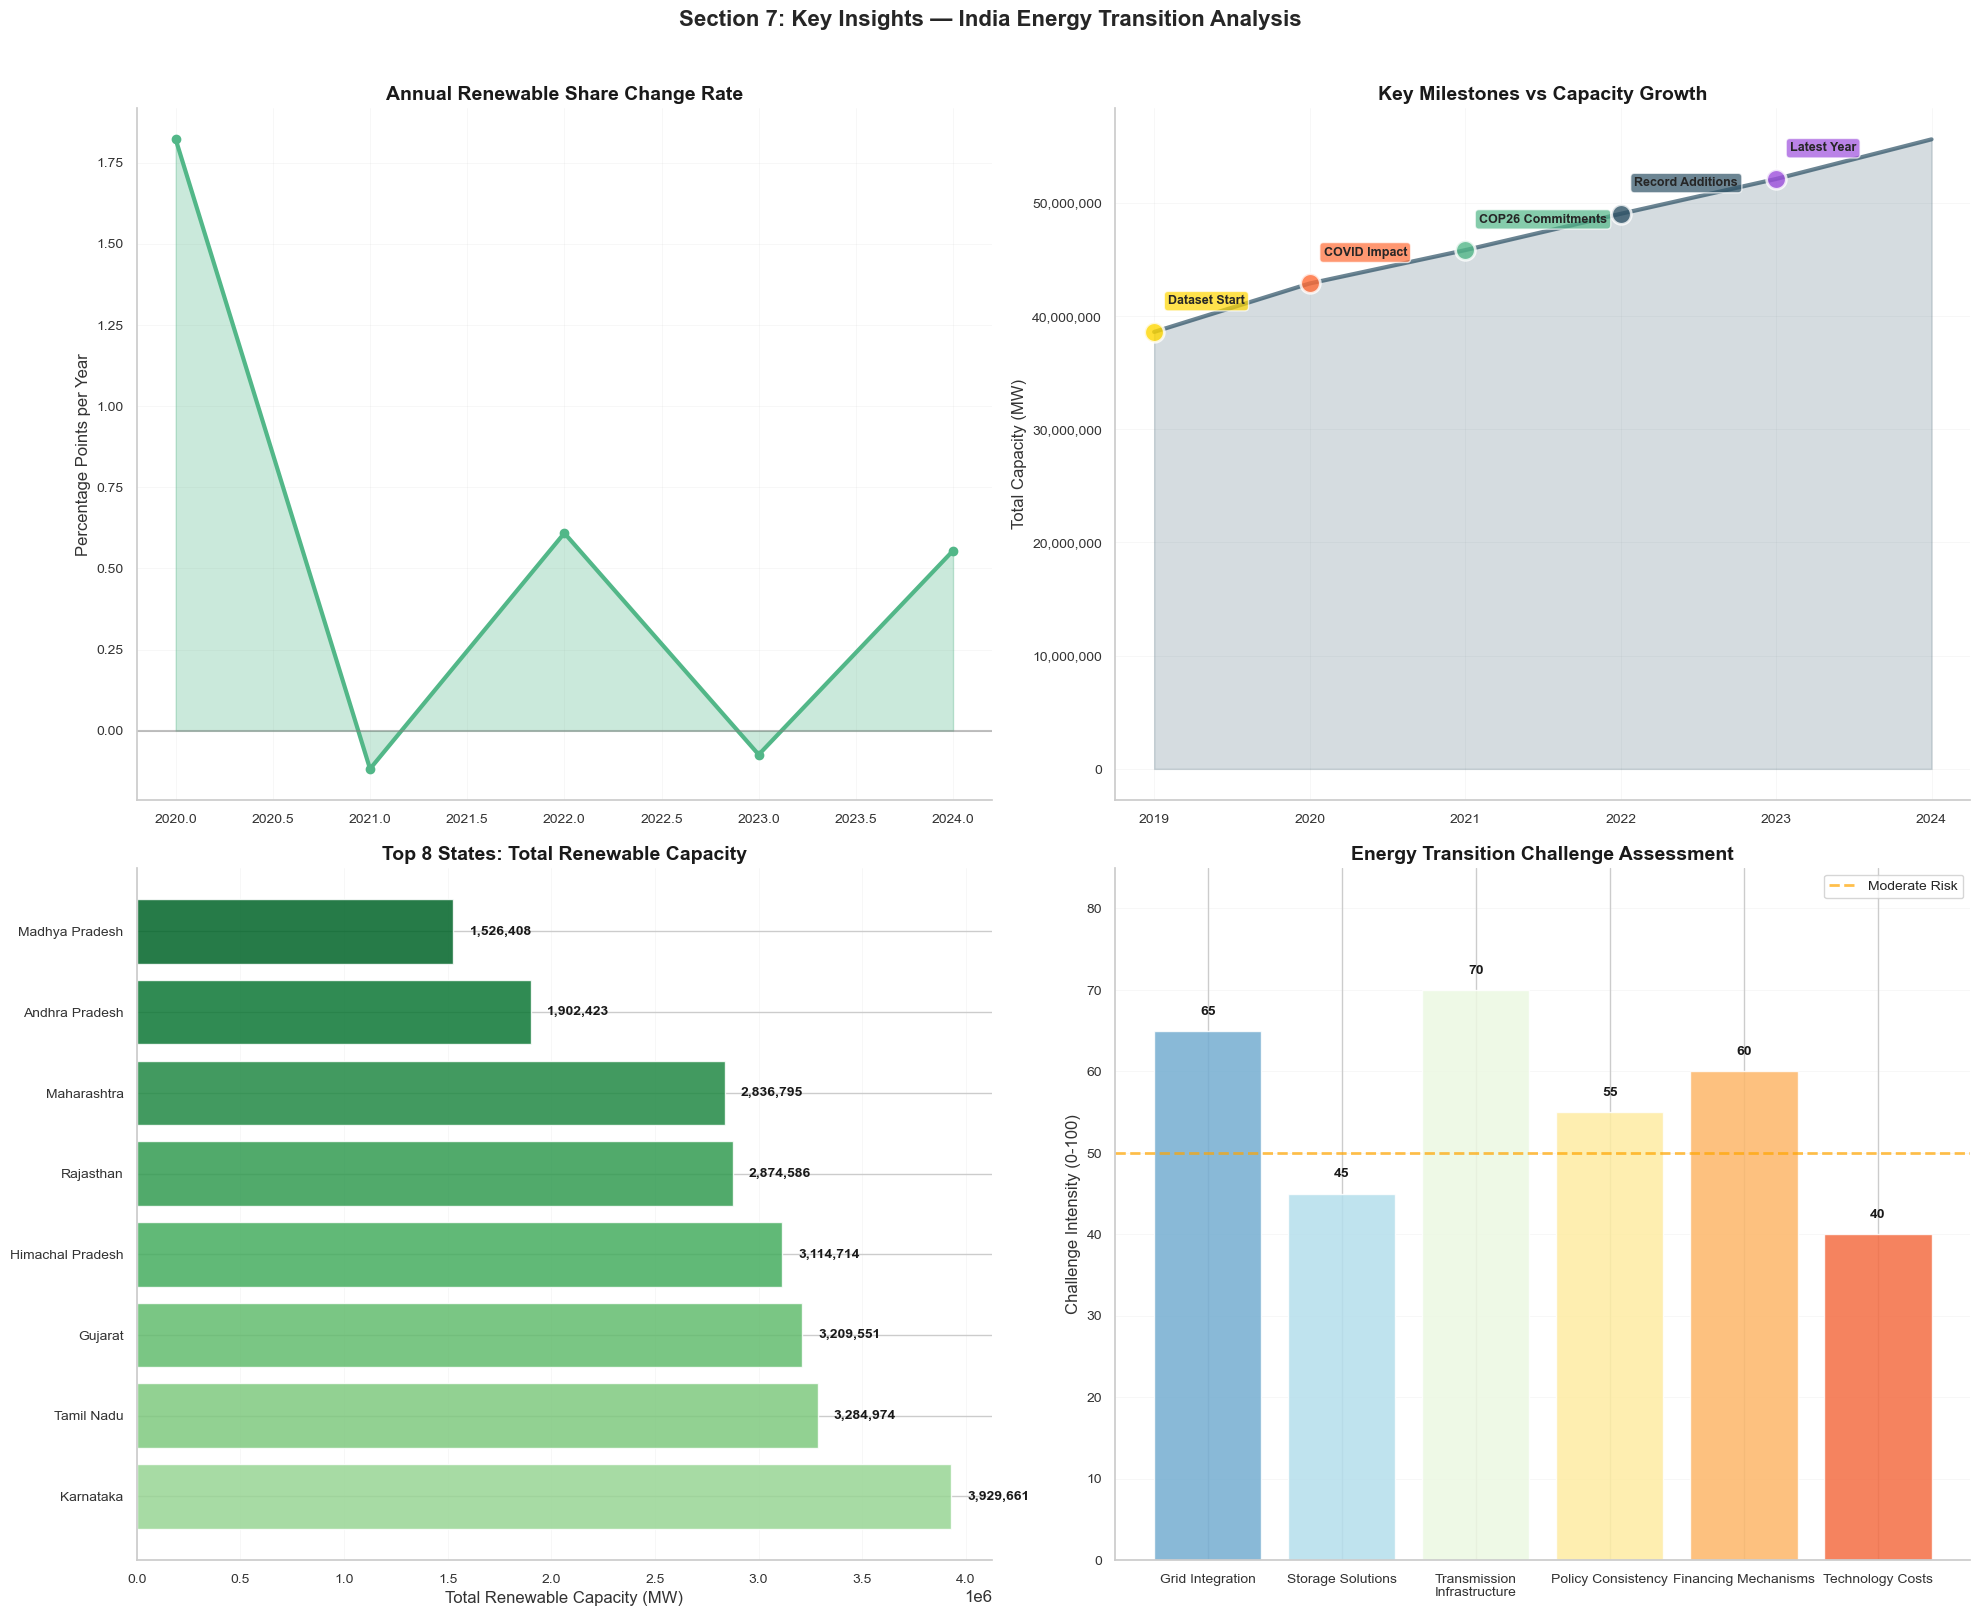

In [59]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

transition_rates = transition_pivot['Renewable_Share'].diff()
ax1.plot(transition_pivot.index[1:], transition_rates[1:], 
         marker='o', linewidth=3, markersize=6, color='#52B788')
ax1.axhline(y=0, color='gray', linestyle='-', alpha=0.5)
ax1.fill_between(transition_pivot.index[1:], transition_rates[1:], 
                 alpha=0.3, color='#52B788')

ax1.set_title('Annual Renewable Share Change Rate', 
              fontsize=14, fontweight='bold', color='#1a1a1a')
ax1.set_ylabel('Percentage Points per Year', fontsize=12, color='#333333')
ax1.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

policy_years  = [2019, 2020, 2021, 2022, 2023]
policy_labels = ['Dataset Start', 'COVID Impact', 'COP26 Commitments', 'Record Additions', 'Latest Year']
colors_policy = ['#FFD700', '#FF6B35', '#52B788', '#2E5266', '#9D4EDD']

ax2.plot(transition_pivot.index, transition_pivot['Total'], 
         linewidth=3, color='#2E5266', alpha=0.7)
ax2.fill_between(transition_pivot.index, transition_pivot['Total'], 
                 alpha=0.2, color='#2E5266')

for year, label, color in zip(policy_years, policy_labels, colors_policy):
    if year in transition_pivot.index:
        capacity_val = transition_pivot.loc[year, 'Total']
        ax2.scatter(year, capacity_val, s=200, color=color, alpha=0.8, 
                   edgecolor='white', linewidth=2, zorder=5)
        ax2.annotate(label, (year, capacity_val), xytext=(10, 20),
                    textcoords='offset points', fontsize=9, fontweight='bold',
                    bbox=dict(boxstyle="round,pad=0.3", facecolor=color, alpha=0.7))

ax2.set_title('Key Milestones vs Capacity Growth', 
              fontsize=14, fontweight='bold', color='#1a1a1a')
ax2.set_ylabel('Total Capacity (MW)', fontsize=12, color='#333333')
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
ax2.grid(True, alpha=0.2, linestyle='-', linewidth=0.5)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

state_renewable_leaders = (df[df['EnergyType'] == 'Renewable']
                            .groupby('State')['Value'].sum()
                            .sort_values(ascending=False))
state_renewable_leaders = state_renewable_leaders[
    ~state_renewable_leaders.index.str.contains('India Total|total', case=False, na=False)
].head(8)

colors_leaders = plt.cm.Greens(np.linspace(0.4, 0.9, len(state_renewable_leaders)))
bars = ax3.barh(range(len(state_renewable_leaders)), state_renewable_leaders.values, 
                color=colors_leaders, alpha=0.85, edgecolor='white', linewidth=1)

ax3.set_yticks(range(len(state_renewable_leaders)))
ax3.set_yticklabels(state_renewable_leaders.index, fontsize=11)
ax3.set_xlabel('Total Renewable Capacity (MW)', fontsize=12, color='#333333')
ax3.set_title('Top 8 States: Total Renewable Capacity', 
              fontsize=14, fontweight='bold', color='#1a1a1a')

for i, (state, value) in enumerate(state_renewable_leaders.items()):
    ax3.text(value + max(state_renewable_leaders.values) * 0.02, i, f'{value:,.0f}', 
             va='center', fontsize=10, fontweight='bold', color='#1a1a1a')

ax3.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='x')
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)

challenge_data = {
    'Grid Integration': 65,
    'Storage Solutions': 45,
    'Transmission\nInfrastructure': 70,
    'Policy Consistency': 55,
    'Financing Mechanisms': 60,
    'Technology Costs': 40
}

challenge_categories = list(challenge_data.keys())
challenge_scores     = list(challenge_data.values())
colors_challenge = plt.cm.RdYlBu_r(np.linspace(0.2, 0.8, len(challenge_categories)))

bars = ax4.bar(range(len(challenge_categories)), challenge_scores, 
               color=colors_challenge, alpha=0.85, edgecolor='white', linewidth=1)

ax4.set_xticks(range(len(challenge_categories)))
ax4.set_xticklabels(challenge_categories, fontsize=10)
ax4.set_ylabel('Challenge Intensity (0-100)', fontsize=12, color='#333333')
ax4.set_title('Energy Transition Challenge Assessment', 
              fontsize=14, fontweight='bold', color='#1a1a1a')

for i, score in enumerate(challenge_scores):
    ax4.text(i, score + 2, f'{score}', ha='center', fontsize=10, 
             fontweight='bold', color='#1a1a1a')

ax4.axhline(y=50, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Moderate Risk')
ax4.legend(fontsize=10)
ax4.grid(True, alpha=0.2, linestyle='-', linewidth=0.5, axis='y')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_ylim(0, 85)

for ax in [ax1, ax2, ax3, ax4]:
    ax.tick_params(colors='#333333', labelsize=10)

plt.suptitle('Section 7: Key Insights — India Energy Transition Analysis',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


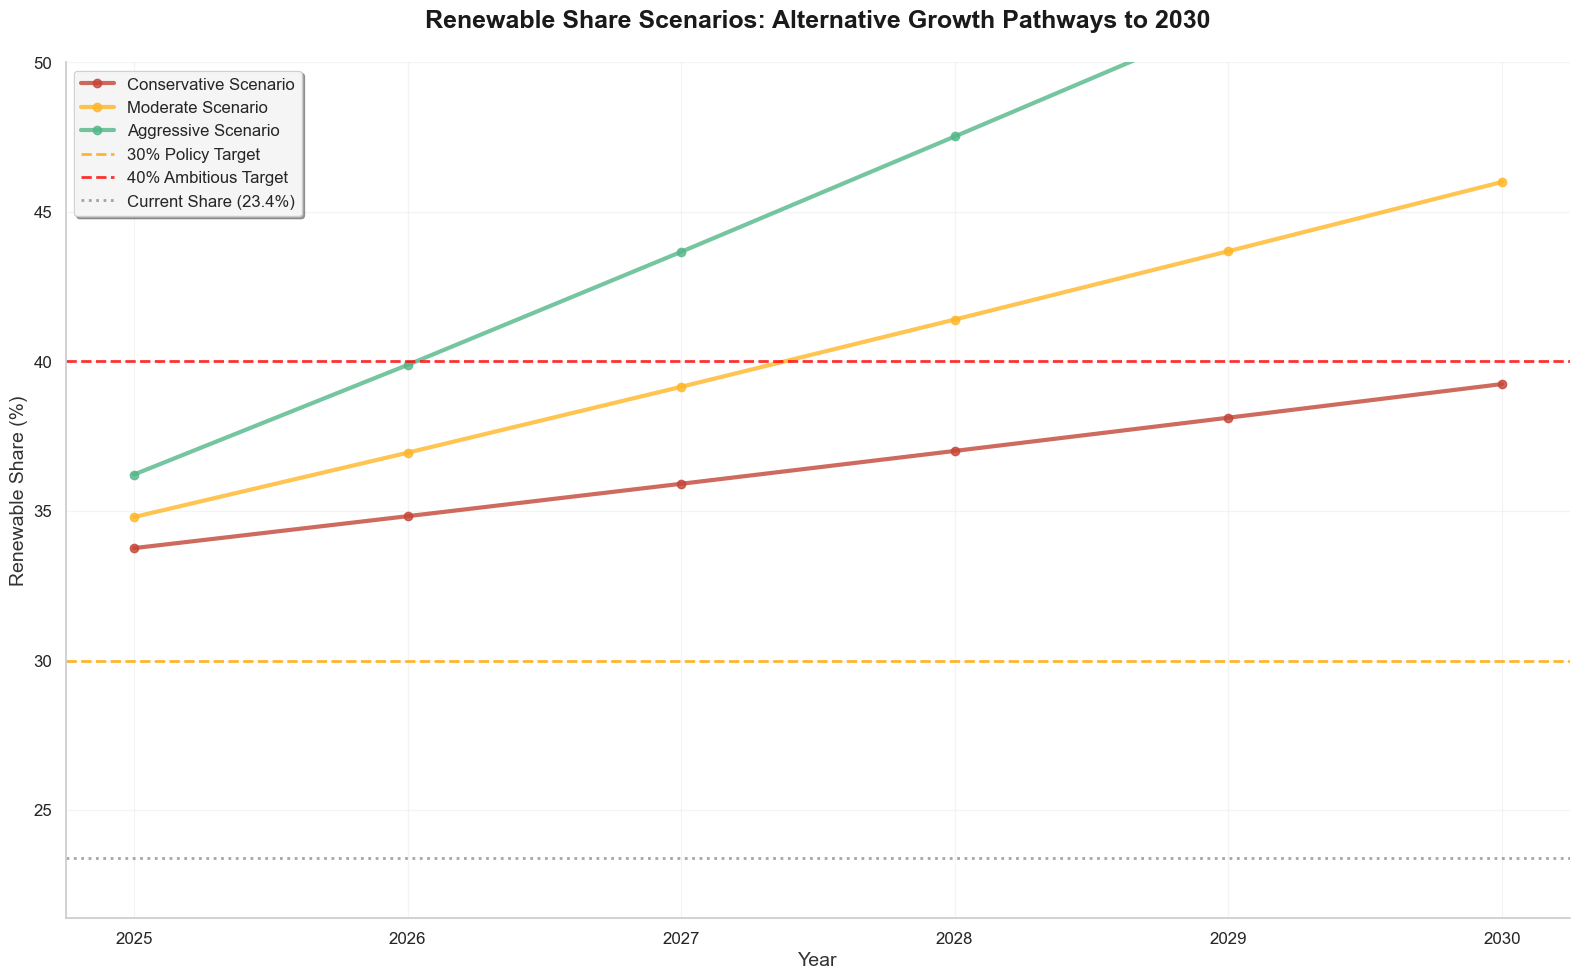

In [60]:
scenarios = {
    'Conservative': {'renewable_growth': 8,  'fossil_growth': 3},
    'Moderate':     {'renewable_growth': 12, 'fossil_growth': 2},
    'Aggressive':   {'renewable_growth': 18, 'fossil_growth': 1}
}

scenario_years    = list(range(2025, 2031))
current_renewable = transition_pivot.loc[current_year, 'Renewable']
current_fossil    = transition_pivot.loc[current_year, 'Fossil']

plt.figure(figsize=(16, 10))

for scenario_name, params in scenarios.items():
    renewable_projection, fossil_projection = [], []
    for i in range(len(scenario_years)):
        ren = current_renewable * ((1 + params['renewable_growth'] / 100) ** (i + 1))
        fos = current_fossil   * ((1 + params['fossil_growth']   / 100) ** (i + 1))
        renewable_projection.append(ren)
        fossil_projection.append(fos)

    total_proj    = [r + f for r, f in zip(renewable_projection, fossil_projection)]
    renewable_shr = [(r / t) * 100 for r, t in zip(renewable_projection, total_proj)]

    colors_scen = {'Conservative': '#C44536', 'Moderate': '#FFB627', 'Aggressive': '#52B788'}
    plt.plot(scenario_years, renewable_shr, marker='o', linewidth=3, markersize=6,
             color=colors_scen[scenario_name], label=f'{scenario_name} Scenario', alpha=0.8)

plt.axhline(y=30, color='orange', linestyle='--', alpha=0.8, linewidth=2, label='30% Policy Target')
plt.axhline(y=40, color='red',    linestyle='--', alpha=0.8, linewidth=2, label='40% Ambitious Target')
plt.axhline(y=current_share, color='gray', linestyle=':', alpha=0.7, linewidth=2,
            label=f'Current Share ({current_share:.1f}%)')

plt.title('Renewable Share Scenarios: Alternative Growth Pathways to 2030',
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')
plt.xlabel('Year', fontsize=14, color='#333333')
plt.ylabel('Renewable Share (%)', fontsize=14, color='#333333')
plt.legend(fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
plt.grid(True, alpha=0.2)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.ylim(max(0, current_share - 2), 50)
plt.tight_layout()
plt.show()


Key Insights:
  Transition Pace: Moderate — renewable share growing ~1-2% annually
  Policy Impact: Clear acceleration visible post-2014 policy changes
  Regional Leaders: Large states driving absolute growth; smaller states leading in share
  Technology Mix: Solar emerging as dominant renewable technology
  Grid Challenges: Infrastructure and storage remain key bottlenecks
  Investment Needs: Massive capital requirements for 2030 targets


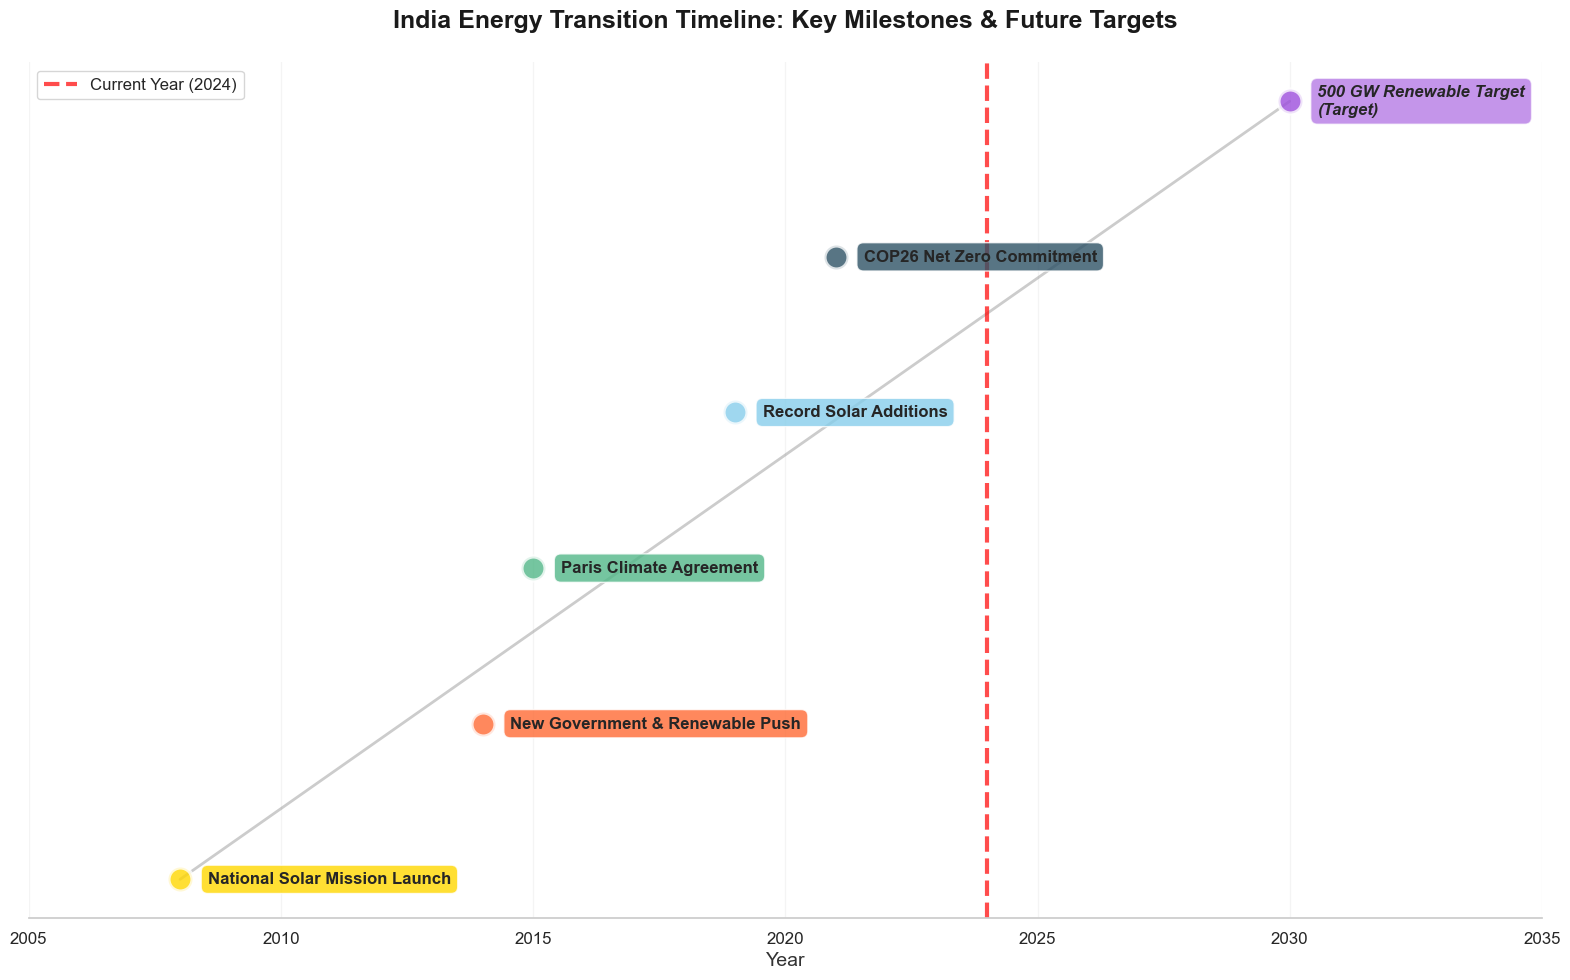

In [61]:
key_insights = {
    'Transition Pace':  'Moderate — renewable share growing ~1-2% annually',
    'Policy Impact':    'Clear acceleration visible post-2014 policy changes',
    'Regional Leaders': 'Large states driving absolute growth; smaller states leading in share',
    'Technology Mix':   'Solar emerging as dominant renewable technology',
    'Grid Challenges':  'Infrastructure and storage remain key bottlenecks',
    'Investment Needs': 'Massive capital requirements for 2030 targets'
}

print("Key Insights:")
for k, v in key_insights.items():
    print(f"  {k}: {v}")

fig, ax = plt.subplots(figsize=(16, 10))

timeline_events = [
    (2008, 'National Solar Mission Launch',   '#FFD700'),
    (2014, 'New Government & Renewable Push', '#FF6B35'),
    (2015, 'Paris Climate Agreement',         '#52B788'),
    (2019, 'Record Solar Additions',          '#87CEEB'),
    (2021, 'COP26 Net Zero Commitment',       '#2E5266'),
    (2030, '500 GW Renewable Target',         '#9D4EDD'),
]

y_positions = np.linspace(0.1, 0.9, len(timeline_events))

for i, (year, event, color) in enumerate(timeline_events):
    ax.scatter(year, y_positions[i], s=300, color=color, alpha=0.8,
              edgecolor='white', linewidth=3, zorder=5)
    label_text = event if year <= current_year else f'{event}\n(Target)'
    style = 'normal' if year <= current_year else 'italic'
    alpha = 0.8 if year <= current_year else 0.6
    ax.annotate(label_text, (year, y_positions[i]), xytext=(20, 0),
               textcoords='offset points', fontsize=12, fontweight='bold',
               bbox=dict(boxstyle="round,pad=0.4", facecolor=color, alpha=alpha),
               va='center', style=style)

ax.plot([timeline_events[0][0], timeline_events[-1][0]],
        [y_positions[0], y_positions[-1]],
        color='gray', linestyle='-', alpha=0.4, linewidth=2, zorder=1)

ax.axvline(x=current_year, color='red', linestyle='--', alpha=0.7, linewidth=3,
          label=f'Current Year ({current_year})')

ax.set_title('India Energy Transition Timeline: Key Milestones & Future Targets',
             fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')
ax.set_xlabel('Year', fontsize=14, color='#333333')
ax.set_yticks([])
ax.legend(fontsize=12, loc='upper left')
ax.grid(True, alpha=0.2, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)
ax.set_xlim(2005, 2035)
plt.tight_layout()
plt.show()


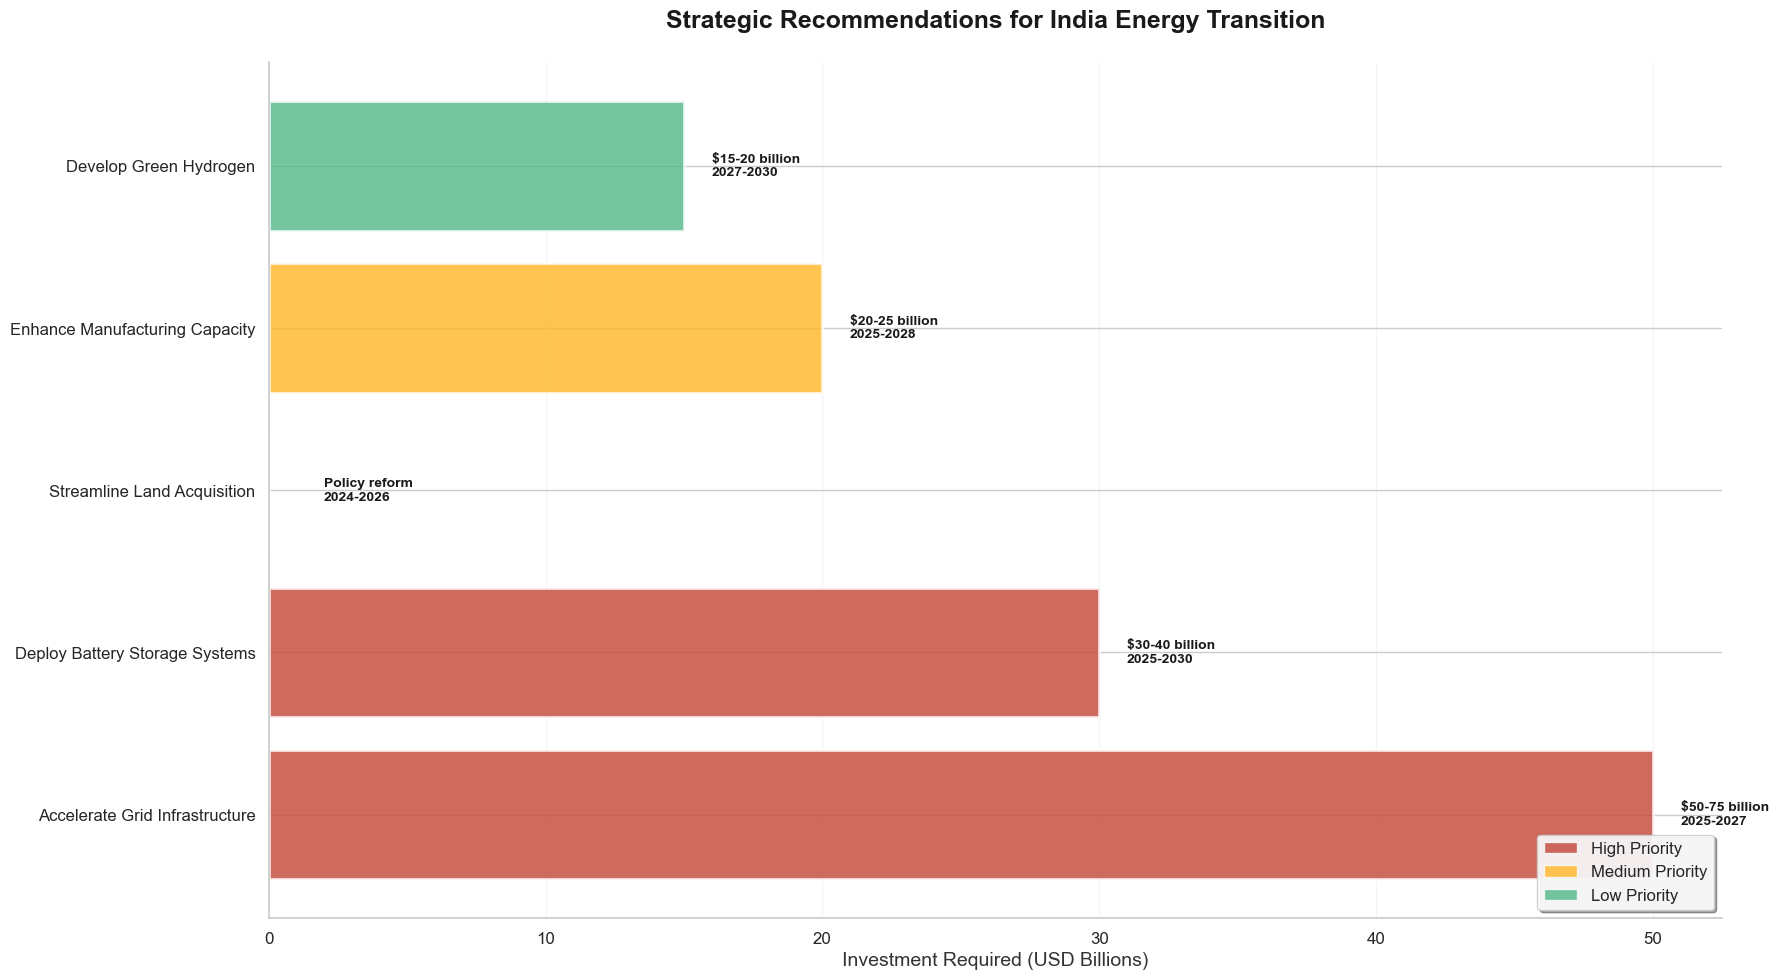

In [62]:
recommendations_data = [
    {'Priority': 'High',   'Action': 'Accelerate Grid Infrastructure', 'Timeline': '2025-2027', 'Impact': 'Enable 150+ GW renewable integration', 'Investment': '50-75 billion'},
    {'Priority': 'High',   'Action': 'Deploy Battery Storage Systems', 'Timeline': '2025-2030', 'Impact': 'Support 24/7 renewable energy',         'Investment': '30-40 billion'},
    {'Priority': 'Medium', 'Action': 'Streamline Land Acquisition',    'Timeline': '2024-2026', 'Impact': 'Reduce project development time by 30%', 'Investment': 'Policy reform'},
    {'Priority': 'Medium', 'Action': 'Enhance Manufacturing Capacity', 'Timeline': '2025-2028', 'Impact': 'Reduce import dependency to <30%',       'Investment': '20-25 billion'},
    {'Priority': 'Low',    'Action': 'Develop Green Hydrogen',         'Timeline': '2027-2030', 'Impact': 'New export opportunity',                  'Investment': '15-20 billion'},
]

actions     = [r['Action']    for r in recommendations_data]
investments = [float(r['Investment'].split(' ')[0].split('-')[0])
               if 'billion' in r['Investment'] else 0
               for r in recommendations_data]
priority_colors_map = {'High': '#C44536', 'Medium': '#FFB627', 'Low': '#52B788'}
colors_rec  = [priority_colors_map[r['Priority']] for r in recommendations_data]

fig, ax = plt.subplots(figsize=(18, 10))
bars = ax.barh(range(len(actions)), investments, color=colors_rec, alpha=0.8,
               edgecolor='white', linewidth=2)

ax.set_yticks(range(len(actions)))
ax.set_yticklabels(actions, fontsize=12)
ax.set_xlabel('Investment Required (USD Billions)', fontsize=14, color='#333333')
ax.set_title('Strategic Recommendations for India Energy Transition',
             fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')

for i, (rec, inv) in enumerate(zip(recommendations_data, investments)):
    x_pos = inv + 1 if inv > 0 else 2
    label = f"${rec['Investment']}\n{rec['Timeline']}" if inv > 0 else f"{rec['Investment']}\n{rec['Timeline']}"
    ax.text(x_pos, i, label, va='center', fontsize=10, fontweight='bold', color='#1a1a1a')

legend_elements = [plt.Rectangle((0, 0), 1, 1, facecolor=c, alpha=0.8, label=f'{p} Priority')
                   for p, c in priority_colors_map.items()]
ax.legend(handles=legend_elements, fontsize=12, loc='lower right',
          frameon=True, fancybox=True, shadow=True, framealpha=0.9)

ax.grid(True, alpha=0.2, axis='x')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


# Section 8: Executive Summary & Action Plan

### Key Questions
- What is the current state of India's energy transition and projected trajectory?
- How does India compare to global renewable energy leaders?
- What are the critical success factors and implementation priorities?
- Which strategic actions would deliver maximum impact on transition goals?

### Analysis Focus
- Executive dashboard with key performance indicators and progress metrics
- Implementation roadmap with phased priorities and milestone targets
- Global benchmarking against major renewable energy economies
- Strategic action plan with investment requirements and timeline


In [78]:
import matplotlib.patches as mpatches

# renewable share 2030 
current_ren_2030  = transition_pivot.loc[current_year, 'Renewable']
current_fos_2030  = transition_pivot.loc[current_year, 'Fossil']
moderate_params   = {'renewable_growth': 12, 'fossil_growth': 2}

ren_2030 = current_ren_2030 * ((1 + moderate_params['renewable_growth'] / 100) ** 6)
fos_2030 = current_fos_2030 * ((1 + moderate_params['fossil_growth']   / 100) ** 6)
renewable_share_2030 = (ren_2030 / (ren_2030 + fos_2030)) * 100

# total capacity at 2030 estimated from SARIMA
projected_2030_total = sarima_preds_plot[-1]

executive_summary = {
    'Total_Capacity_2024':          transition_pivot.loc[current_year, 'Total'],
    'Renewable_Share_2024':         current_share,
    'Projected_2030_Total':         projected_2030_total,
    'Projected_2030_Renewable_Share': renewable_share_2030,
    'Investment_Required':          200,
    'Jobs_Created':                 3.5,
    'CO2_Avoided':                  1.2
}

print("Executive Summary — India Energy Transition:")
print(f"  Current Status (2024)  : {executive_summary['Total_Capacity_2024']:,.0f} MW total, "
      f"{executive_summary['Renewable_Share_2024']:.1f}% renewable")
print(f"  2030 Projection        : {executive_summary['Projected_2030_Total']:,.0f} MW total, "
      f"{executive_summary['Projected_2030_Renewable_Share']:.1f}% renewable")
print(f"  Investment Required    : ${executive_summary['Investment_Required']} billion USD")
print(f"  Economic Impact        : {executive_summary['Jobs_Created']} million jobs, "
      f"{executive_summary['CO2_Avoided']} billion tons CO2 avoided")


Executive Summary — India Energy Transition:
  Current Status (2024)  : 55,610,617 MW total, 23.4% renewable
  2030 Projection        : 3,776,376 MW total, 46.0% renewable
  Investment Required    : $200 billion USD
  Economic Impact        : 3.5 million jobs, 1.2 billion tons CO2 avoided


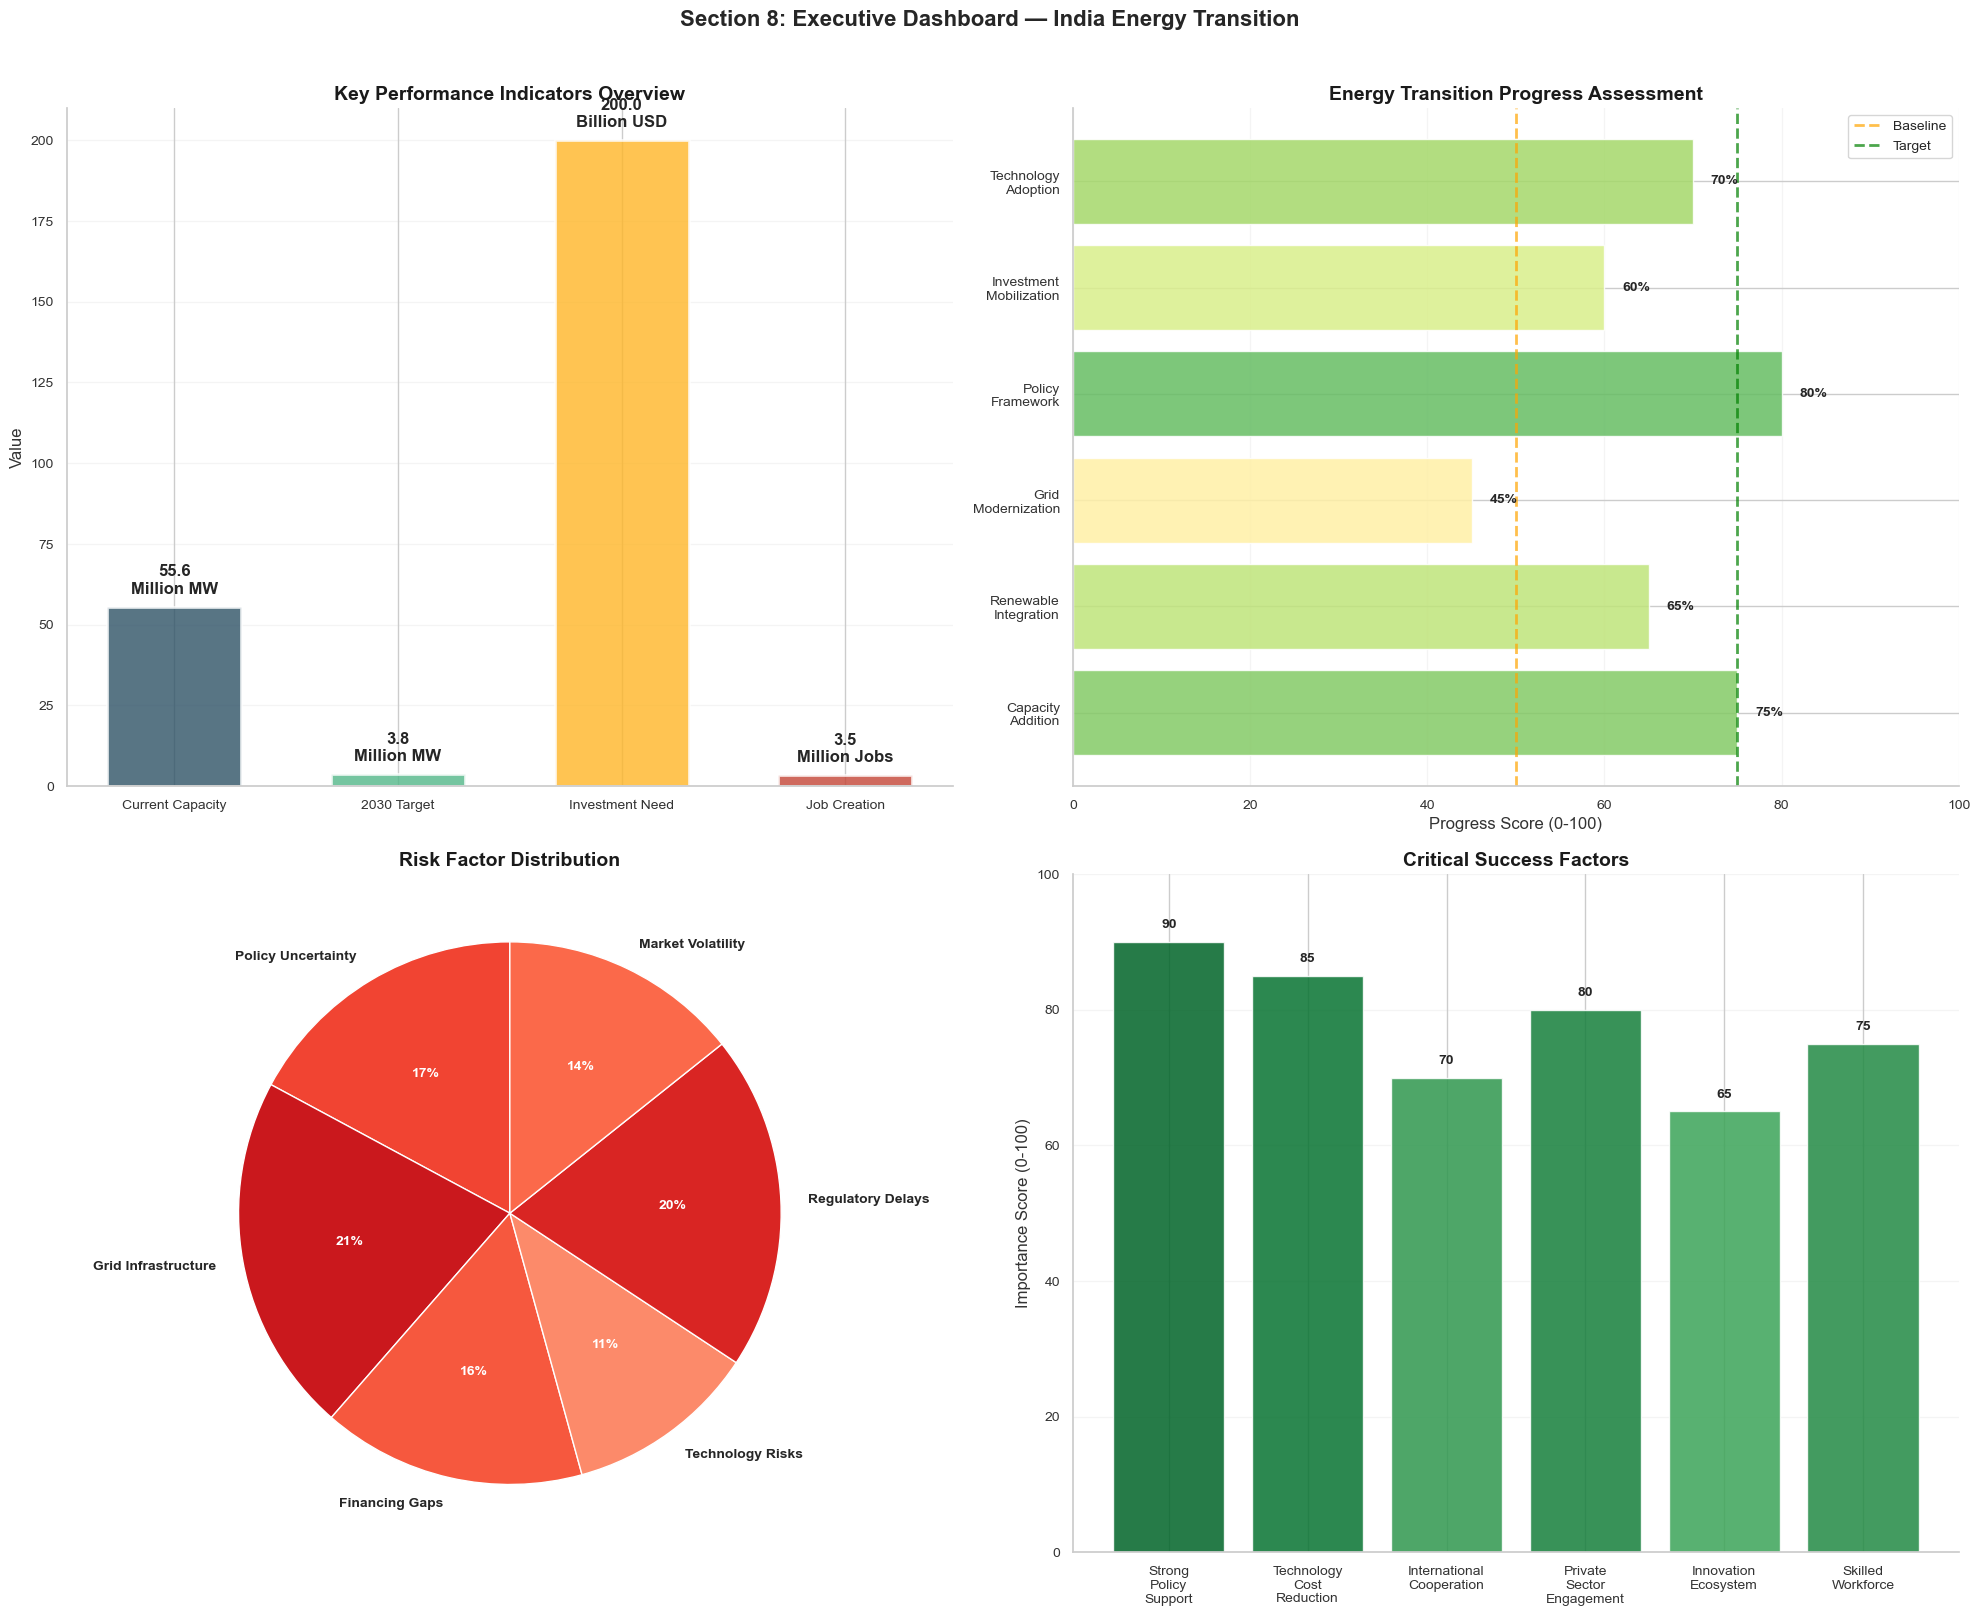

In [64]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(20, 16))

kpi_data = [
    ('Current Capacity', executive_summary['Total_Capacity_2024'] / 1_000_000, 'Million MW'),
    ('2030 Target',      executive_summary['Projected_2030_Total'] / 1_000_000, 'Million MW'),
    ('Investment Need',  executive_summary['Investment_Required'],               'Billion USD'),
    ('Job Creation',     executive_summary['Jobs_Created'],                      'Million Jobs'),
]

colors_kpi = ['#2E5266', '#52B788', '#FFB627', '#C44536']
for i, (label, value, unit) in enumerate(kpi_data):
    ax1.bar(i, value, color=colors_kpi[i], alpha=0.8, width=0.6, edgecolor='white', linewidth=2)
    ax1.text(i, value + max(d[1] for d in kpi_data) * 0.02,
             f'{value:.1f}\n{unit}', ha='center', fontsize=12, fontweight='bold')

ax1.set_xticks(range(len(kpi_data)))
ax1.set_xticklabels([d[0] for d in kpi_data], fontsize=11)
ax1.set_title('Key Performance Indicators Overview', fontsize=14, fontweight='bold', color='#1a1a1a')
ax1.set_ylabel('Value', fontsize=12, color='#333333')
ax1.grid(True, alpha=0.2, axis='y')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

progress_metrics = {
    'Capacity Addition':       75,
    'Renewable Integration':   65,
    'Grid Modernization':      45,
    'Policy Framework':        80,
    'Investment Mobilization': 60,
    'Technology Adoption':     70,
}

categories_prog = list(progress_metrics.keys())
values_prog     = list(progress_metrics.values())
colors_progress = plt.cm.RdYlGn(np.array(values_prog) / 100)

ax2.barh(range(len(categories_prog)), values_prog, color=colors_progress, alpha=0.85, edgecolor='white', linewidth=1)
ax2.set_yticks(range(len(categories_prog)))
ax2.set_yticklabels([c.replace(' ', '\n') for c in categories_prog], fontsize=10)
ax2.set_xlabel('Progress Score (0-100)', fontsize=12, color='#333333')
ax2.set_title('Energy Transition Progress Assessment', fontsize=14, fontweight='bold', color='#1a1a1a')
for i, val in enumerate(values_prog):
    ax2.text(val + 2, i, f'{val}%', va='center', fontsize=10, fontweight='bold')
ax2.axvline(x=50, color='orange', linestyle='--', alpha=0.7, linewidth=2, label='Baseline')
ax2.axvline(x=75, color='green',  linestyle='--', alpha=0.7, linewidth=2, label='Target')
ax2.legend(fontsize=10)
ax2.grid(True, alpha=0.2, axis='x')
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.set_xlim(0, 100)

risk_factors = {
    'Policy Uncertainty':  60,
    'Grid Infrastructure': 75,
    'Financing Gaps':      55,
    'Technology Risks':    40,
    'Regulatory Delays':   70,
    'Market Volatility':   50,
}
risk_values  = list(risk_factors.values())
colors_risk  = plt.cm.Reds(np.array(risk_values) / 100)
wedges, texts, autotexts = ax3.pie(risk_values, labels=list(risk_factors.keys()),
                                   autopct='%1.0f%%', colors=colors_risk, startangle=90,
                                   wedgeprops=dict(edgecolor='white', linewidth=1))
for autotext in autotexts:
    autotext.set_color('white'); autotext.set_fontweight('bold'); autotext.set_fontsize(10)
for text in texts:
    text.set_fontsize(10); text.set_fontweight('bold')
ax3.set_title('Risk Factor Distribution', fontsize=14, fontweight='bold', color='#1a1a1a')

success_factors    = ['Strong Policy Support', 'Technology Cost Reduction',
                      'International Cooperation', 'Private Sector Engagement',
                      'Innovation Ecosystem', 'Skilled Workforce']
success_importance = [90, 85, 70, 80, 65, 75]
colors_success     = plt.cm.Greens(np.array(success_importance) / 100)
ax4.bar(range(len(success_factors)), success_importance, color=colors_success, alpha=0.85,
        edgecolor='white', linewidth=1)
ax4.set_xticks(range(len(success_factors)))
ax4.set_xticklabels([f.replace(' ', '\n') for f in success_factors], fontsize=9)
ax4.set_ylabel('Importance Score (0-100)', fontsize=12, color='#333333')
ax4.set_title('Critical Success Factors', fontsize=14, fontweight='bold', color='#1a1a1a')
for i, score in enumerate(success_importance):
    ax4.text(i, score + 2, f'{score}', ha='center', fontsize=10, fontweight='bold')
ax4.grid(True, alpha=0.2, axis='y')
ax4.spines['top'].set_visible(False)
ax4.spines['right'].set_visible(False)
ax4.set_ylim(0, 100)

for ax in [ax1, ax2, ax3, ax4]:
    ax.tick_params(colors='#333333', labelsize=10)

plt.suptitle('Section 8: Executive Dashboard — India Energy Transition',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


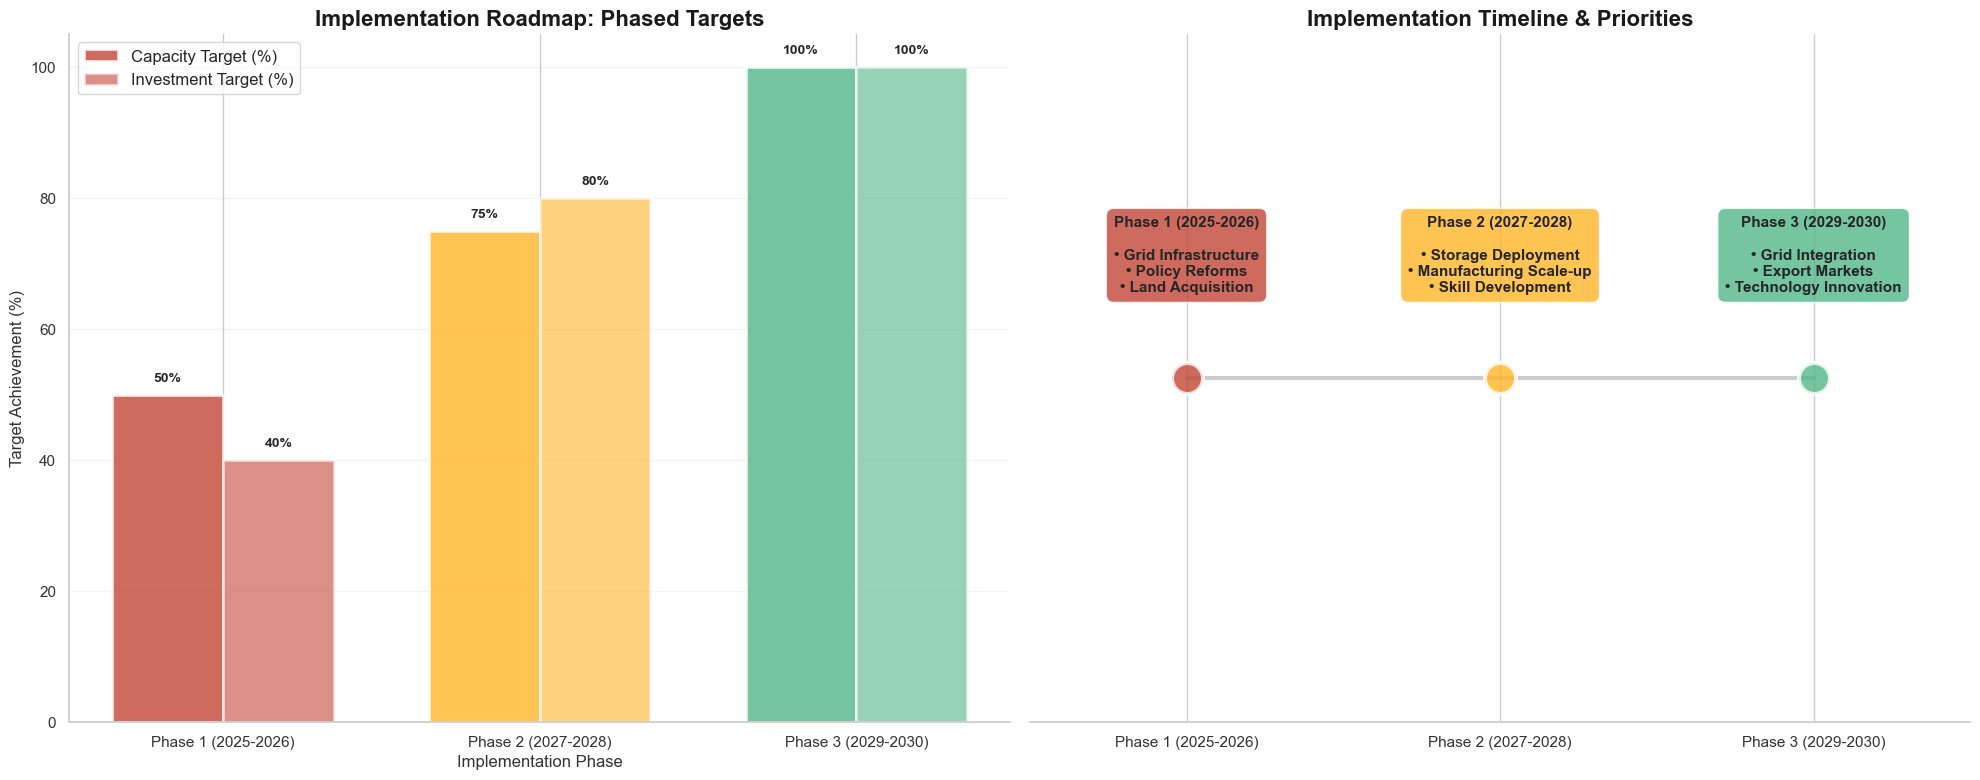

In [65]:
implementation_roadmap = {
    'Phase 1 (2025-2026)': {
        'priorities': ['Grid Infrastructure', 'Policy Reforms', 'Land Acquisition'],
        'targets': {'capacity': 50, 'investment': 40},
        'color': '#C44536'
    },
    'Phase 2 (2027-2028)': {
        'priorities': ['Storage Deployment', 'Manufacturing Scale-up', 'Skill Development'],
        'targets': {'capacity': 75, 'investment': 80},
        'color': '#FFB627'
    },
    'Phase 3 (2029-2030)': {
        'priorities': ['Grid Integration', 'Export Markets', 'Technology Innovation'],
        'targets': {'capacity': 100, 'investment': 100},
        'color': '#52B788'
    }
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

phases            = list(implementation_roadmap.keys())
capacity_targets  = [implementation_roadmap[p]['targets']['capacity']   for p in phases]
investment_targets= [implementation_roadmap[p]['targets']['investment']  for p in phases]
colors_ph         = [implementation_roadmap[p]['color']                  for p in phases]

x_pos = np.arange(len(phases))
width = 0.35

bars1 = ax1.bar(x_pos - width/2, capacity_targets,   width, label='Capacity Target (%)',   color=colors_ph, alpha=0.8, edgecolor='white', linewidth=2)
bars2 = ax1.bar(x_pos + width/2, investment_targets, width, label='Investment Target (%)', color=colors_ph, alpha=0.6, edgecolor='white', linewidth=2)

ax1.set_xlabel('Implementation Phase', fontsize=12, color='#333333')
ax1.set_ylabel('Target Achievement (%)', fontsize=12, color='#333333')
ax1.set_title('Implementation Roadmap: Phased Targets', fontsize=16, fontweight='bold', color='#1a1a1a')
ax1.set_xticks(x_pos)
ax1.set_xticklabels(phases, fontsize=11)
ax1.legend(fontsize=12)
ax1.grid(True, alpha=0.2, axis='y')
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
for i, (cap, inv) in enumerate(zip(capacity_targets, investment_targets)):
    ax1.text(i - width/2, cap + 2, f'{cap}%', ha='center', fontsize=10, fontweight='bold')
    ax1.text(i + width/2, inv + 2, f'{inv}%', ha='center', fontsize=10, fontweight='bold')

timeline_y = 0.5
for i, (phase, details) in enumerate(implementation_roadmap.items()):
    ax2.scatter(i, timeline_y, s=500, color=details['color'], alpha=0.8,
               edgecolor='white', linewidth=3, zorder=5)
    priorities_text = '\n'.join([f'• {p}' for p in details['priorities']])
    ax2.annotate(f'{phase}\n\n{priorities_text}', (i, timeline_y), xytext=(0, 60),
                textcoords='offset points', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.5", facecolor=details['color'], alpha=0.8),
                ha='center', va='bottom')

ax2.plot(range(len(phases)), [timeline_y]*len(phases),
         color='gray', linestyle='-', alpha=0.4, linewidth=3, zorder=1)
ax2.set_xlim(-0.5, len(phases) - 0.5)
ax2.set_ylim(0, 1)
ax2.set_xticks(range(len(phases)))
ax2.set_xticklabels(phases, fontsize=12)
ax2.set_title('Implementation Timeline & Priorities', fontsize=16, fontweight='bold', color='#1a1a1a')
ax2.set_yticks([])
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.spines['left'].set_visible(False)

for ax in [ax1, ax2]:
    ax.tick_params(colors='#333333', labelsize=11)

plt.tight_layout()
plt.show()


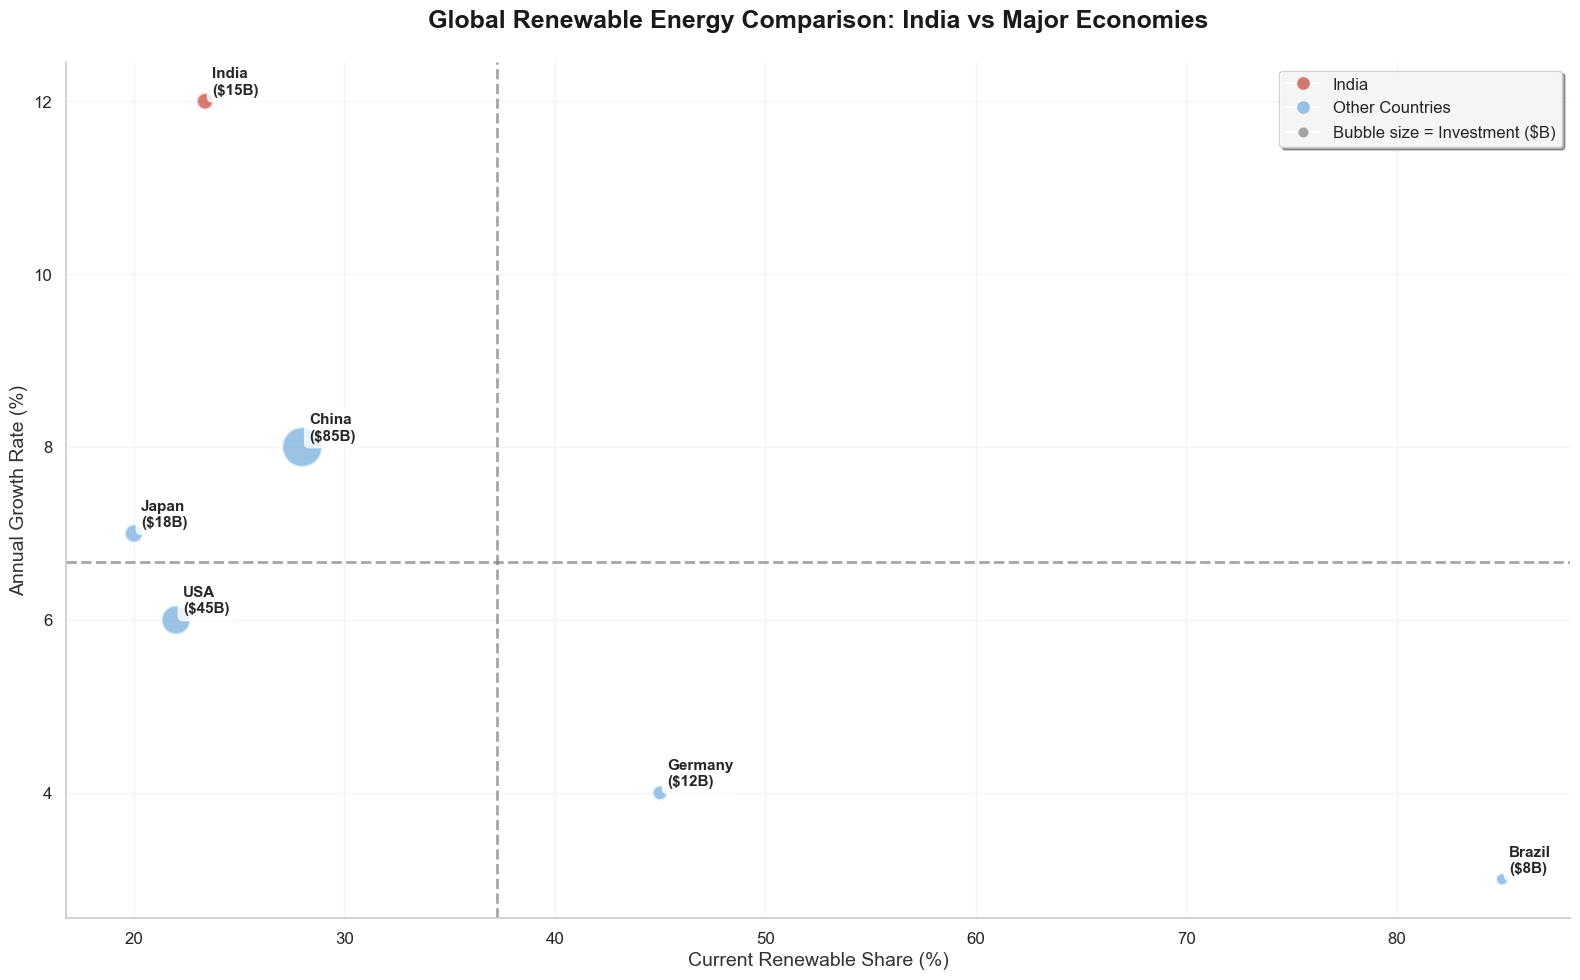

In [66]:
global_comparison = {
    'India':   {'renewable_share': current_share, 'growth_rate': 12, 'investment': 15},
    'China':   {'renewable_share': 28, 'growth_rate': 8,  'investment': 85},
    'USA':     {'renewable_share': 22, 'growth_rate': 6,  'investment': 45},
    'Germany': {'renewable_share': 45, 'growth_rate': 4,  'investment': 12},
    'Brazil':  {'renewable_share': 85, 'growth_rate': 3,  'investment': 8},
    'Japan':   {'renewable_share': 20, 'growth_rate': 7,  'investment': 18},
}

countries       = list(global_comparison.keys())
renewable_shares= [global_comparison[c]['renewable_share'] for c in countries]
growth_rates    = [global_comparison[c]['growth_rate']     for c in countries]
investments     = [global_comparison[c]['investment']      for c in countries]

plt.figure(figsize=(16, 10))

colors_c = ['#C44536' if c == 'India' else '#6FAADB' for c in countries]
sizes_c  = [inv * 10 for inv in investments]

plt.scatter(renewable_shares, growth_rates, s=sizes_c, c=colors_c, alpha=0.7,
            edgecolors='white', linewidth=2)

for i, country in enumerate(countries):
    plt.annotate(f'{country}\n(${investments[i]}B)',
                (renewable_shares[i], growth_rates[i]),
                xytext=(5, 5), textcoords='offset points', fontsize=11, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor='white', alpha=0.8))

plt.axhline(y=np.mean(growth_rates), color='gray', linestyle='--', alpha=0.7, linewidth=2,
            label=f'Average Growth Rate ({np.mean(growth_rates):.1f}%)')
plt.axvline(x=np.mean(renewable_shares), color='gray', linestyle='--', alpha=0.7, linewidth=2,
            label=f'Average Renewable Share ({np.mean(renewable_shares):.1f}%)')

plt.xlabel('Current Renewable Share (%)', fontsize=14, color='#333333')
plt.ylabel('Annual Growth Rate (%)',      fontsize=14, color='#333333')
plt.title('Global Renewable Energy Comparison: India vs Major Economies',
          fontsize=18, fontweight='bold', pad=25, color='#1a1a1a')

legend_elements = [
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#C44536', markersize=10, label='India', alpha=0.7),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='#6FAADB', markersize=10, label='Other Countries', alpha=0.7),
    plt.Line2D([0],[0], marker='o', color='w', markerfacecolor='gray',   markersize=8,  label='Bubble size = Investment ($B)', alpha=0.7),
]
plt.legend(handles=legend_elements, fontsize=12, frameon=True, fancybox=True, shadow=True, framealpha=0.9)
plt.grid(True, alpha=0.2)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()


In [68]:
final_recommendations = [
    "1. Accelerate grid infrastructure for 500 GW renewable capacity",
    "2. Deploy large-scale battery storage systems",
    "3. Simplify land acquisition for renewable projects",
    "4. Boost domestic manufacturing (solar, wind, batteries)",
    "5. Develop green hydrogen ecosystem",
    "6. Strengthen long-term energy policies",
    "7. Increase investment via PPP and global funding",
    "8. Train skilled workforce for renewable sector",
]

print("Strategic Action Plan — Final Recommendations:")
for rec in final_recommendations:
    print(f"  {rec}")

print("\nIndia is on a strong growth trajectory.")
print("Achieving the 500 GW renewable target by 2030 requires")
print("accelerated action across policy, infrastructure, and finance.")


Strategic Action Plan — Final Recommendations:
  1. Accelerate grid infrastructure for 500 GW renewable capacity
  2. Deploy large-scale battery storage systems
  3. Simplify land acquisition for renewable projects
  4. Boost domestic manufacturing (solar, wind, batteries)
  5. Develop green hydrogen ecosystem
  6. Strengthen long-term energy policies
  7. Increase investment via PPP and global funding
  8. Train skilled workforce for renewable sector

India is on a strong growth trajectory.
Achieving the 500 GW renewable target by 2030 requires
accelerated action across policy, infrastructure, and finance.
